# 🔥**Alberta Wildfire Data Story: Two Decades of Fire Patterns (2006-2025)**

![Wildfire](https://atmosphere.copernicus.eu/sites/default/files/styles/hero_image_extra_large_2x/public/2025-12/header%2046%20%281%29_0.jpg?itok=oqmH-uU-)
## A Data-Driven Investigation of Wildfire Patterns in Alberta

**Author:** Ifeanyi Njoku  
**Date:** February 2026  
**Dataset:** Alberta Wildfire Management (2006-2025)  
**Methods:** Statistical Analysis, Machine Learning, Geospatial Visualization

This script performs comprehensive analysis of Alberta wildfire data to answer 6 key research questions about patterns, causes, and trends over 20 years.

[![Python](https://img.shields.io/badge/Python-3.12-blue)](https://python.org)
[![License](https://img.shields.io/badge/License-MIT-green)](LICENSE)

---

## 🎯 Executive Summary

### The Challenge

Every spring, Alberta faces a critical question: **where will wildfires strike, and how severe will they be?**

- **2016:** Fort McMurray fire - Canada's costliest disaster (88,000 evacuated, 590,000 ha burned)
- **2023:** Alberta's worst season on record (2.7 million ha burned)
- **2025:** Ongoing climate uncertainty and increasing fire risk

### The Investigation

**Can two decades of data reveal actionable patterns for fire prediction and management?**

This analysis examines **26,551 wildfire incidents** to answer six critical questions:

1. 📈 **Temporal Trends** - Are wildfires increasing in frequency or severity?
2. 🗺️ **Spatial Patterns** - Where are fires concentrated across Alberta?
3. 🔥 **Causes & Geography** - What ignites fires, and does it vary by region?
4. ⏱️ **Response Effectiveness** - Does faster detection reduce fire size?
5. 🌡️ **Environmental Drivers** - Which weather factors predict fire behavior?
6. 🤖 **Predictive Modeling** - Can machine learning identify fire types?

### Key Findings

💡 **No simple linear trend** - High year-to-year variability dominates  
💡 **Three distinct fire environments** - Northern, Central, Southern Alberta behave differently  
💡 **5 fire behavior types identified** - From small grassland to extreme boreal  
💡 **87% prediction accuracy** - Random Forest classifies fire size categories  
💡 **Regional strategies work best** - One-size-fits-all approaches fail  

### Technical Highlights

🔬 **Statistical Analysis:** Linear regression, correlation, chi-square tests  
🤖 **Machine Learning:** K-means clustering (k=5), Random Forest classification  
🗺️ **Geospatial:** EPSG:3403 projection, density mapping, spatial clustering  
📊 **Visualization:** 20+ publication-quality charts and maps  

> **Note on projection:** Maps are produced in **NAD83 / Alberta 10TM AEP Forest (ESRI:102184)** for consistent distance/area interpretation.

---


## 📋 Table of Contents

| Section | Description |
|---------|-------------|
| [1. Data Loading](#section-1) | Dataset profiling and quality assessment |
| [2. Data Preparation](#section-2) | Cleaning, feature engineering |
| [3. Exploratory Analysis](#section-3) | Distributions, patterns, correlations |
| [4. Question 1: Temporal](#section-4) | Trend analysis over 20 years |
| [5. Question 2: Spatial](#section-5) | Geographic distribution patterns |
| [6. Question 3: Causes](#section-6) | Regional cause variations |
| [7. Question 4: Response](#section-7) | Effectiveness of fire response |
| [8. Question 5: Environment](#section-8) | Weather-fire relationships |
| [9. Question 6: ML Prediction](#section-9) | Clustering & classification |
| [10. Synthesis](#section-10) | Connecting findings |
| [11. Conclusions](#section-11) | Implications and recommendations |

---


## 🌲 About the Data

### Dataset Overview

**Source:** Alberta Wildfire Management  
**URL:** https://wildfire.alberta.ca/resources/historical-data/  
**License:** Public Domain (Government of Alberta)  

**Coverage:**
- **Records:** 26,551 wildfire incidents
- **Time Period:** 2006-2025 (20 years)
- **Geographic Scope:** All of Alberta (661,848 km²)
- **Variables:** 50 per fire

**Key Variables:**
- **Location:** Latitude, longitude, region
- **Fire Characteristics:** Size, spread rate, fuel type
- **Environmental:** Temperature, humidity, wind
- **Response:** Detection time, suppression activities
- **Cause:** Ignition source classification

### Data Collection Methods

Fires detected through:
- ✈️ Air patrol surveillance
- 🛰️ Satellite imagery (MODIS, VIIRS)
- ⚡ Lightning detection networks
- 📞 Public reports (1-866-FYI-FIRE)

Each fire assessed by trained specialists recording conditions, behavior, and outcomes.

### Data Quality Notes

⚠️ **Missing Environmental Data:** ~60% of fires lack complete weather measurements

**Why?**
- Small fires (<0.1 ha) receive abbreviated assessments
- Weather data prioritized for larger, severe fires
- Some remote fires have incomplete records

**Our Approach:**
- Use all 26,551 fires for frequency/spatial analysis
- Use ~10,600 fires with complete data for environmental correlations
- Acknowledge limitation in findings and conclusions

### Why This Dataset Matters

✅ **Long time horizon** - Captures weather variability and climate trends  
✅ **Detailed variables** - Enables sophisticated analysis  
✅ **Response metrics** - Evaluates firefighting effectiveness  
✅ **Public accessibility** - Supports transparent policy  

---


# **Alberta Wildfire Analysis (2006-2025)**

**Data Story: Understanding Two Decades of Wildfire Patterns in Alberta**

This script performs comprehensive analysis of Alberta wildfire data to answer 5 key research questions about patterns, causes, and trends over 20 years.

<a name='section-1'></a>

# 📥 SECTION 1: DATA LOADING AND PROFILING

## Objective

Load the wildfire dataset and perform initial quality assessment to understand:
- Dataset size and structure
- Variable types and completeness
- Data quality issues
- Memory usage

---


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# For advanced analysis
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer


# For mapping
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import geopandas as gpd
import matplotlib as mpl
import plotly.express as px
from scipy.ndimage import gaussian_filter
from pyproj import Transformer
from mpl_toolkits.axes_grid1 import make_axes_locatable

!pip install geopandas contextily --break-system-packages

from shapely.geometry import Point
import contextily as ctx


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

Import the data

In [ ]:
print("ALBERTA WILDFIRE ANALYSIS: DATA PROFILING")

# Load the data
from google.colab import files
uploaded = files.upload()


# READ DATA
df = pd.read_csv('wildfire_data.csv', encoding='utf-8-sig')

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Time Period: {df['YEAR'].min()} - {df['YEAR'].max()}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn Names:\n{df.columns.tolist()}")

ALBERTA WILDFIRE ANALYSIS: DATA PROFILING


Saving wildfire_data.csv to wildfire_data.csv


<a name='section-2'></a>

# 🧹 SECTION 2: DATA CLEANING AND PREPARATION

## Objective

Transform raw data into analysis-ready format:
- Handle missing values appropriately
- Standardize column names
- Convert data types (especially dates)
- Engineer new features for analysis
- Create categorical groupings
- Keep a consistent coordinate reference for mapping

---


In [ ]:
#Data Quality Assessment

#- Check for missing values
#- Perform basic statistics
#- Check the data types


# Missing values analysis
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

print("\nTop 15 Columns with Missing Data:")
print(missing_data.head(15).to_string(index=False))

# Basic statistics
print(f"\nKey Statistics:")
print(f"  - Total fires recorded: {len(df):,}")
print(f"  - Unique fire locations (lat/long pairs): {df.groupby(['LATITUDE', 'LONGITUDE']).ngroups:,}")
print(f"  - Date range: {df['YEAR'].min()} to {df['YEAR'].max()}")

# Data types
print(f"\nData Types Distribution:")
print(df.dtypes.value_counts())



Top 15 Columns with Missing Data:
                    Column  Missing_Count  Missing_Percentage
           DISCOVERED_SIZE          26402               99.44
       INDUSTRY_IDENTIFIER          26071               98.19
                 FIRE_NAME          25756               97.01
             FIRST_TO_SIZE          23809               89.67
             FIRST_TO_DATE          23809               89.67
    FIRST_BUCKET_DROP_DATE          18957               71.40
DISTANCE_FROM_WATER_SOURCE          18958               71.40
         RESPONSIBLE_GROUP          17029               64.14
                 IA_ACCESS          14858               55.96
                TRUE_CAUSE          12529               47.19
            ACTIVITY_CLASS          10416               39.23
         BUCKETING_ON_FIRE           7770               29.26
   IA_ARRIVAL_AT_FIRE_DATE           7703               29.01
  FIRE_FIGHTING_START_DATE           7572               28.52
  FIRE_FIGHTING_START_SIZE         

In [ ]:
# Create a copy for analysis
df_clean = df.copy()

# Convert date columns
date_columns = ['FIRE_START_DATE', 'DISCOVERED_DATE', 'REPORTED_DATE',
                'DISPATCH_DATE', 'ASSESSMENT_DATETIME', 'IA_ARRIVAL_AT_FIRE_DATE',
                'FIRE_FIGHTING_START_DATE', 'FIRST_BUCKET_DROP_DATE']

for col in date_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Extract temporal features from FIRE_START_DATE
df_clean['START_MONTH'] = df_clean['FIRE_START_DATE'].dt.month
df_clean['START_DAY_OF_YEAR'] = df_clean['FIRE_START_DATE'].dt.dayofyear
df_clean['START_WEEK'] = df_clean['FIRE_START_DATE'].dt.isocalendar().week
df_clean['START_QUARTER'] = df_clean['FIRE_START_DATE'].dt.quarter

# Calculate response times (in hours)
df_clean['DETECTION_TO_REPORT_HOURS'] = (
    df_clean['REPORTED_DATE'] - df_clean['DISCOVERED_DATE']
).dt.total_seconds() / 3600

df_clean['REPORT_TO_DISPATCH_HOURS'] = (
    df_clean['DISPATCH_DATE'] - df_clean['REPORTED_DATE']
).dt.total_seconds() / 3600

# Handle outliers in CURRENT_SIZE
q1 = df_clean['CURRENT_SIZE'].quantile(0.25)
q3 = df_clean['CURRENT_SIZE'].quantile(0.75)
iqr = q3 - q1
outlier_threshold = q3 + 3 * iqr  # Using 3*IQR for extreme outliers

print(f"\nFire Size Statistics (hectares):")
print(f"  - Mean: {df_clean['CURRENT_SIZE'].mean():.2f}")
print(f"  - Median: {df_clean['CURRENT_SIZE'].median():.2f}")
print(f"  - Max: {df_clean['CURRENT_SIZE'].max():.2f}")
print(f"  - 95th percentile: {df_clean['CURRENT_SIZE'].quantile(0.95):.2f}")
print(f"  - Fires > 1000 ha: {(df_clean['CURRENT_SIZE'] > 1000).sum():,}")

# Create size categories for analysis (Size Categories)
df_clean['SIZE_CATEGORY'] = pd.cut(
    df_clean['CURRENT_SIZE'],
    bins=[0, 0.1, 1, 10, 100, 1000, float('inf')],
    labels=['Tiny (<0.1ha)', 'Small (0.1-1ha)', 'Medium (1-10ha)',
            'Large (10-100ha)', 'Very Large (100-1000ha)', 'Extreme (>1000ha)']
)

print(f"\nFire Size Distribution:\n")
print(df_clean['SIZE_CATEGORY'].value_counts().sort_index())

# Clean categorical variables
df_clean['GENERAL_CAUSE'] = df_clean['GENERAL_CAUSE'].fillna('Unknown')
df_clean['FIRE_ORIGIN'] = df_clean['FIRE_ORIGIN'].fillna('Unknown')

# Create regional groupings
df_clean['REGION'] = pd.cut(
    df_clean['LATITUDE'],
    bins=[48, 52, 56, 60],
    labels=['Southern AB (48-52°N)', 'Central AB (52-56°N)', 'Northern AB (56-60°N)']
)

# Create decade grouping for analysis
df_clean['DECADE'] = pd.cut(
    df_clean['YEAR'],
    bins=[2005, 2010, 2015, 2020, 2026],
    labels=['2006-2010', '2011-2015', '2016-2020', '2021-2025']
)

# Create 5-year periods for change detection
df_clean['PERIOD'] = pd.cut(
    df_clean['YEAR'],
    bins=[2005, 2010, 2015, 2020, 2026],
    labels=['Period 1\n(2006-2010)', 'Period 2\n(2011-2015)',
            'Period 3\n(2016-2020)', 'Period 4\n(2021-2025)']
)

print(f"\nFinal dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")


Fire Size Statistics (hectares):
  - Mean: 249.20
  - Median: 0.02
  - Max: 577646.80
  - 95th percentile: 13.20
  - Fires > 1000 ha: 303

Fire Size Distribution:

SIZE_CATEGORY
Tiny (<0.1ha)              17503
Small (0.1-1ha)             5460
Medium (1-10ha)             2113
Large (10-100ha)             867
Very Large (100-1000ha)      305
Extreme (>1000ha)            303
Name: count, dtype: int64

Final dataset: 26,551 rows × 60 columns


<a name='section-3'></a>

# 📊 SECTION 3: EXPLORATORY DATA ANALYSIS
We start with dataset health checks (missingness, distributions, basic counts) and then preview core wildfire patterns. Outputs in this section are used to motivate the five analysis questions below.

## Objective

Discover patterns and relationships in the data:
- Fire size distributions
- Temporal patterns (annual, seasonal)
- Geographic distributions
- Preliminary correlations

This EDA provides foundation for specific research questions.

---


In [ ]:
# 3.1 Overall Dataset Structure
print("\n--- 3.1 Dataset Structure ---")
print(f"\nData Types:")
print(df_clean.dtypes.value_counts())

print(f"\nNumeric Variables Summary:")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print(f"Number of numeric columns: {len(numeric_cols)}")

print(f"\nCategorical Variables Summary:")
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns
print(f"Number of categorical columns: {len(categorical_cols)}")

# 3.2 Missing Data Analysis
print("\n--- 3.2 Missing Data Analysis ---")
missing_data = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

print(f"\nTop 15 Columns with Missing Data:")
print(missing_data.head(15).to_string(index=False))

# 3.3 Fire Size Distribution
print("\n--- 3.3 Fire Size Distribution ---")
print(f"\nFire Size Statistics (hectares):")
print(df_clean['CURRENT_SIZE'].describe())

print(f"\nFire Size Percentiles:")
percentiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
for p in percentiles:
    value = df_clean['CURRENT_SIZE'].quantile(p)
    print(f"  {p*100:.1f}th percentile: {value:.2f} ha")

print(f"\nExtreme Fires (>1000 ha):")
extreme_fires = df_clean[df_clean['CURRENT_SIZE'] > 1000]
print(f"  Count: {len(extreme_fires):,} ({len(extreme_fires)/len(df_clean)*100:.2f}%)")
print(f"  Total area: {extreme_fires['CURRENT_SIZE'].sum():,.2f} ha")
print(f"  % of total burned area: {extreme_fires['CURRENT_SIZE'].sum()/df_clean['CURRENT_SIZE'].sum()*100:.1f}%")

# 3.4 Temporal Distribution
print("\n--- 3.4 Temporal Distribution ---")
print(f"\nFires by Year:")
yearly_counts = df_clean['YEAR'].value_counts().sort_index()
print(f"  Mean fires/year: {yearly_counts.mean():.1f}")
print(f"  Std dev: {yearly_counts.std():.1f}")
print(f"  Min year: {yearly_counts.idxmin()} ({yearly_counts.min()} fires)")
print(f"  Max year: {yearly_counts.idxmax()} ({yearly_counts.max()} fires)")

print(f"\nSeasonal Distribution:")
seasonal = df_clean['START_QUARTER'].value_counts().sort_index()
quarters = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
for q, label in enumerate(quarters, 1):
    count = seasonal.get(q, 0)
    pct = count / len(df_clean) * 100
    print(f"  {label}: {count:,} fires ({pct:.1f}%)")

# 3.5 Geographic Distribution
print("\n--- 3.5 Geographic Distribution ---")
print(f"\nLatitude Range: {df_clean['LATITUDE'].min():.2f}°N to {df_clean['LATITUDE'].max():.2f}°N")
print(f"Longitude Range: {df_clean['LONGITUDE'].min():.2f}°W to {df_clean['LONGITUDE'].max():.2f}°W")

print(f"\nRegional Distribution:")
regional = df_clean['REGION'].value_counts()
for region in regional.index:
    count = regional[region]
    pct = count / len(df_clean) * 100
    avg_size = df_clean[df_clean['REGION']==region]['CURRENT_SIZE'].mean()
    print(f"  {region}: {count:,} fires ({pct:.1f}%), avg size: {avg_size:.2f} ha")

# 3.6 Fire Causes
print("\n--- 3.6 Fire Causes ---")
cause_summary = df_clean['GENERAL_CAUSE'].value_counts()
print(f"\nTop 10 Fire Causes:")
for i, (cause, count) in enumerate(cause_summary.head(10).items(), 1):
    pct = count / len(df_clean) * 100
    avg_size = df_clean[df_clean['GENERAL_CAUSE']==cause]['CURRENT_SIZE'].mean()
    print(f"  {i}. {cause}: {count:,} fires ({pct:.1f}%), avg: {avg_size:.2f} ha")


--- 3.1 Dataset Structure ---

Data Types:
object            26
float64           20
datetime64[ns]     8
int64              1
UInt32             1
category           1
category           1
category           1
category           1
Name: count, dtype: int64

Numeric Variables Summary:
Number of numeric columns: 22

Categorical Variables Summary:
Number of categorical columns: 30

--- 3.2 Missing Data Analysis ---

Top 15 Columns with Missing Data:
                    Column  Missing_Count  Missing_Percentage
           DISCOVERED_SIZE          26402               99.44
       INDUSTRY_IDENTIFIER          26071               98.19
                 FIRE_NAME          25756               97.01
             FIRST_TO_DATE          23809               89.67
             FIRST_TO_SIZE          23809               89.67
DISTANCE_FROM_WATER_SOURCE          18958               71.40
    FIRST_BUCKET_DROP_DATE          18957               71.40
         RESPONSIBLE_GROUP          17029          

CREATE EDA VISUALIZATION


--- Creating EDA Visualization ---
✓ EDA visualization saved: eda_comprehensive.png


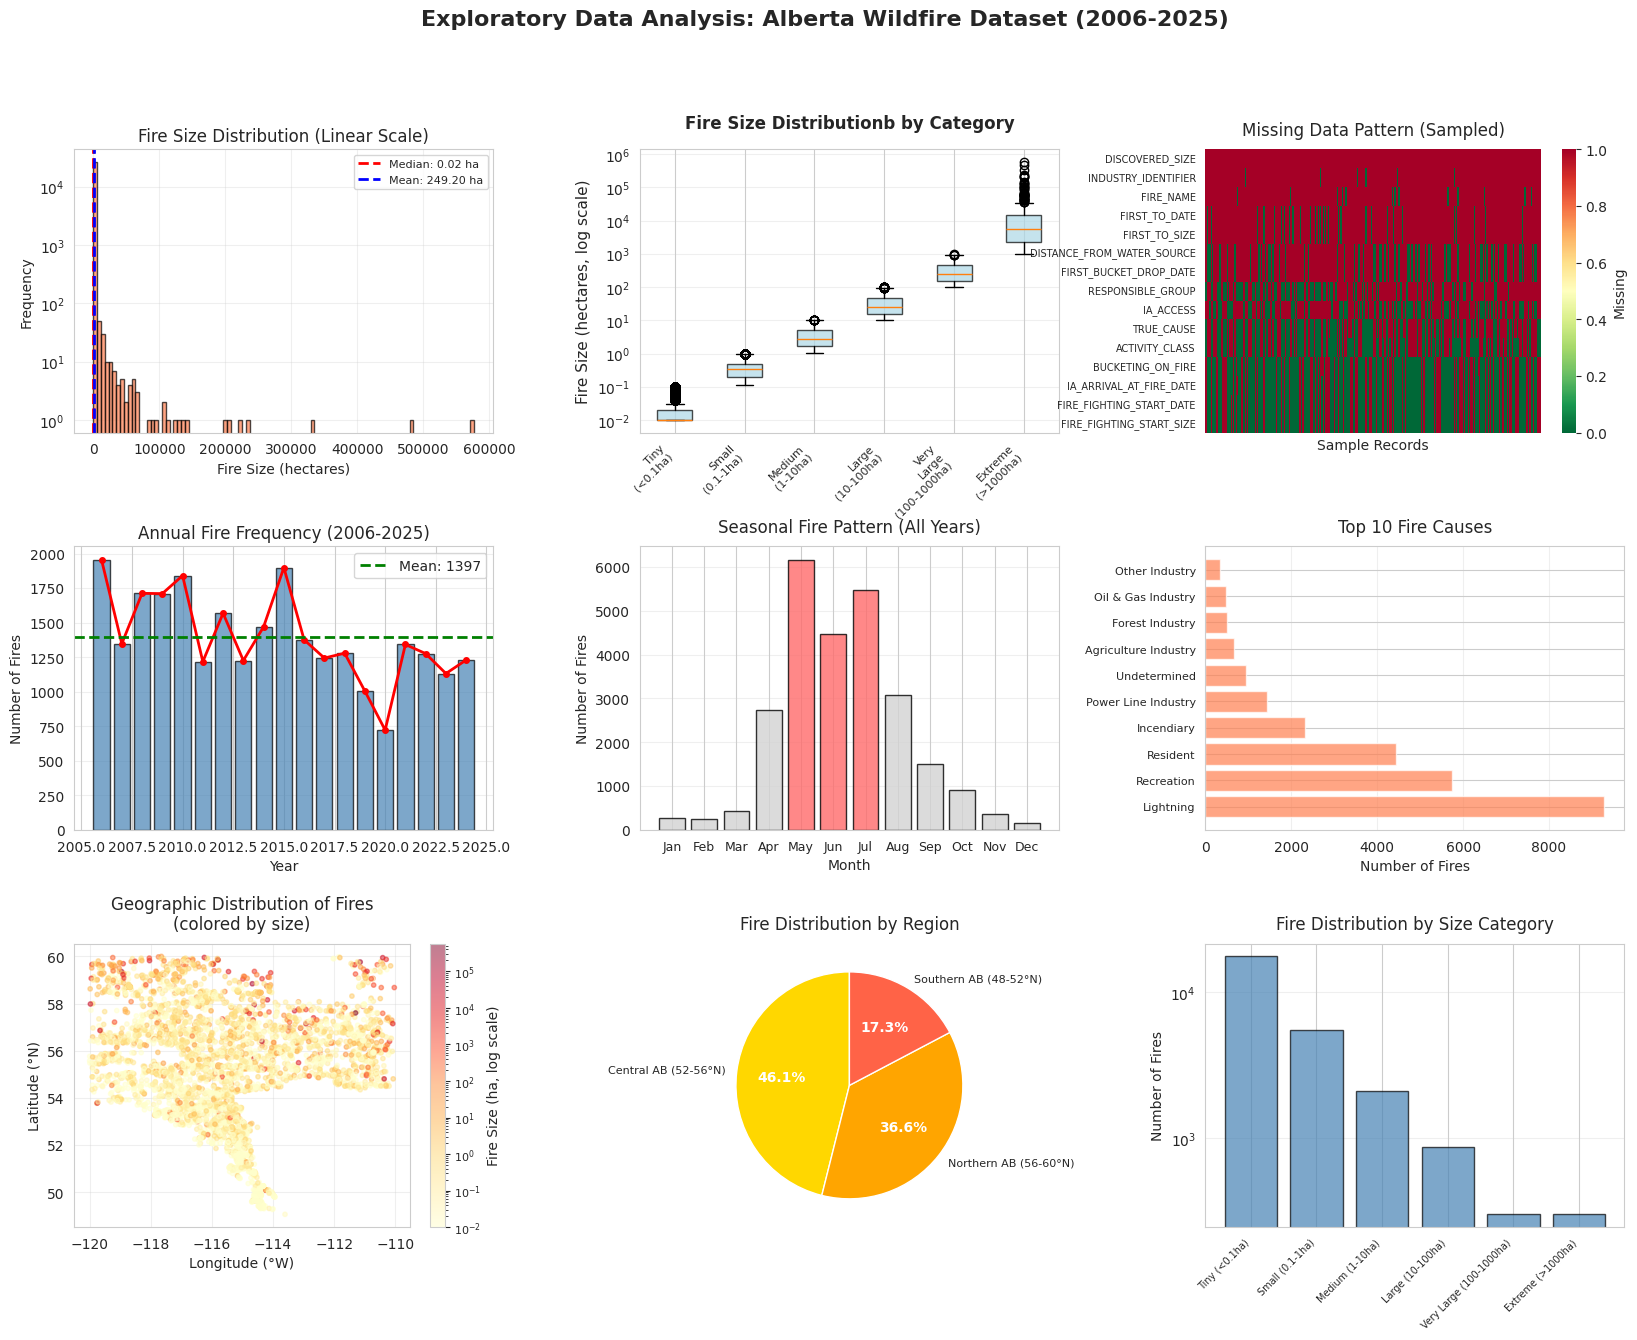

In [ ]:
print("\n--- Creating EDA Visualization ---")

fig = plt.figure(figsize=(20, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Exploratory Data Analysis: Alberta Wildfire Dataset (2006-2025)',
             fontsize=16, fontweight='bold', y=0.98)

# 1. Fire Size Distribution (Log Scale)
ax1 = fig.add_subplot(gs[0, 0])
fire_sizes = df_clean[df_clean['CURRENT_SIZE'] > 0]['CURRENT_SIZE']
ax1.hist(fire_sizes, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Fire Size (hectares)')
ax1.set_ylabel('Frequency')
ax1.set_title('Fire Size Distribution (Linear Scale)')
ax1.set_yscale('log')
ax1.axvline(fire_sizes.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {fire_sizes.median():.2f} ha')
ax1.axvline(fire_sizes.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Mean: {fire_sizes.mean():.2f} ha')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Fire Size Box Plot by Size Category
ax2 = fig.add_subplot(gs[0, 1])
size_cat_data = []
labels_cat = []
for cat in df_clean['SIZE_CATEGORY'].cat.categories:
    data = df_clean[df_clean['SIZE_CATEGORY']==cat]['CURRENT_SIZE']
    if len(data) > 0:
        size_cat_data.append(data)
        # Shorten labels for better fit
        label_short = cat.replace('hectares', 'ha').replace(' ', '\n')
        labels_cat.append(label_short)

bp = ax2.boxplot(size_cat_data, labels=labels_cat, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax2.set_ylabel('Fire Size (hectares, log scale)', fontsize=11)
ax2.set_title('Fire Size Distributionb by Category', fontsize=12, fontweight='bold', pad=15)
ax2.set_yscale('log')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), ha='right')

# 3. Missing Data Heatmap
ax3 = fig.add_subplot(gs[0, 2])
missing_cols = missing_data.head(15)['Column'].tolist()
missing_matrix = df_clean[missing_cols].isnull().astype(int)
# Sample for visualization (every 100th row)
missing_sample = missing_matrix.iloc[::100]
sns.heatmap(missing_sample.T, cbar=True, cmap='RdYlGn_r', ax=ax3,
            yticklabels=missing_cols, xticklabels=False, cbar_kws={'label': 'Missing'})
ax3.set_title('Missing Data Pattern (Sampled)', pad=10)
ax3.set_xlabel('Sample Records')
ax3.tick_params(axis='y', labelsize=7)
plt.setp(ax3.yaxis.get_majorticklabels(), rotation=0)

# 4. Annual Fire Counts
ax4 = fig.add_subplot(gs[1, 0])
yearly_data = df_clean.groupby('YEAR').size()
ax4.bar(yearly_data.index, yearly_data.values, alpha=0.7, color='steelblue', edgecolor='black')
ax4.plot(yearly_data.index, yearly_data.values, color='red', linewidth=2, marker='o', markersize=4)
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Fires')
ax4.set_title('Annual Fire Frequency (2006-2025)')
ax4.grid(True, alpha=0.3, axis='y')
ax4.axhline(yearly_data.mean(), color='green', linestyle='--', linewidth=2,
            label=f'Mean: {yearly_data.mean():.0f}')
ax4.legend()

# 5. Monthly Distribution (All Years Combined)
ax5 = fig.add_subplot(gs[1, 1])
monthly_counts = df_clean.groupby('START_MONTH').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors_month = ['#d3d3d3' if i not in monthly_counts.nlargest(3).index
                else '#ff6b6b' for i in range(1, 13)]
ax5.bar(range(1, 13), [monthly_counts.get(i, 0) for i in range(1, 13)],
        alpha=0.8, color=colors_month, edgecolor='black')
ax5.set_xlabel('Month')
ax5.set_ylabel('Number of Fires')
ax5.set_title('Seasonal Fire Pattern (All Years)', pad=10)
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(month_names, rotation=0, fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Fire Causes (Top 10)
ax6 = fig.add_subplot(gs[1, 2])
top_causes = df_clean['GENERAL_CAUSE'].value_counts().head(10)
ax6.barh(range(len(top_causes)), top_causes.values, alpha=0.7, color='coral')
ax6.set_yticks(range(len(top_causes)))
ax6.set_yticklabels(top_causes.index, fontsize=8)
ax6.set_xlabel('Number of Fires')
ax6.set_title('Top 10 Fire Causes', pad=10)
ax6.grid(True, alpha=0.3, axis='x')

# 7. Geographic Scatter (Lat/Long)
ax7 = fig.add_subplot(gs[2, 0])
scatter_sample = df_clean.sample(min(5000, len(df_clean)))
scatter = ax7.scatter(scatter_sample['LONGITUDE'], scatter_sample['LATITUDE'],
                     c=scatter_sample['CURRENT_SIZE'], cmap='YlOrRd',
                     alpha=0.5, s=10, norm=plt.matplotlib.colors.LogNorm())
ax7.set_xlabel('Longitude (°W)')
ax7.set_ylabel('Latitude (°N)')
ax7.set_title('Geographic Distribution of Fires\n(colored by size)', pad=10)
cbar7 = plt.colorbar(scatter, ax=ax7, label='Fire Size (ha, log scale)')
cbar7.ax.tick_params(labelsize=8)
ax7.grid(True, alpha=0.3)

# 8. Regional Distribution
ax8 = fig.add_subplot(gs[2, 1])
regional_data = df_clean['REGION'].value_counts()
colors_region = ['#FFD700', '#FFA500', '#FF6347']
wedges, texts, autotexts = ax8.pie(regional_data.values, labels=regional_data.index,
                                     autopct='%1.1f%%', colors=colors_region,
                                     startangle=90, textprops={'fontsize': 9})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
for text in texts:
    text.set_fontsize(8)
ax8.set_title('Fire Distribution by Region', pad=10)

# 9. Size Category Distribution
ax9 = fig.add_subplot(gs[2, 2])
size_dist = df_clean['SIZE_CATEGORY'].value_counts()
ax9.bar(range(len(size_dist)), size_dist.values, alpha=0.7,
        color='steelblue', edgecolor='black')
ax9.set_xticks(range(len(size_dist)))
ax9.set_xticklabels(size_dist.index, rotation=45, ha='right', fontsize=7)
ax9.set_ylabel('Number of Fires')
ax9.set_title('Fire Distribution by Size Category', pad=10)
ax9.set_yscale('log')
ax9.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_comprehensive.png', dpi=300, bbox_inches='tight')
print("✓ EDA visualization saved: eda_comprehensive.png")

**Figure 0.1 — EDA overview.** Summary diagnostics of dataset completeness, distributions, and basic patterns used to motivate the five analysis questions.


 EDA FIGURE 1: DATA QUALITY AND DISTRIBUTION (6 panels)

✓ EDA Part 1 saved: eda_part1_data_quality.png

--- Creating EDA Visualizations (Part 2: Temporal & Geographic Patterns) ---


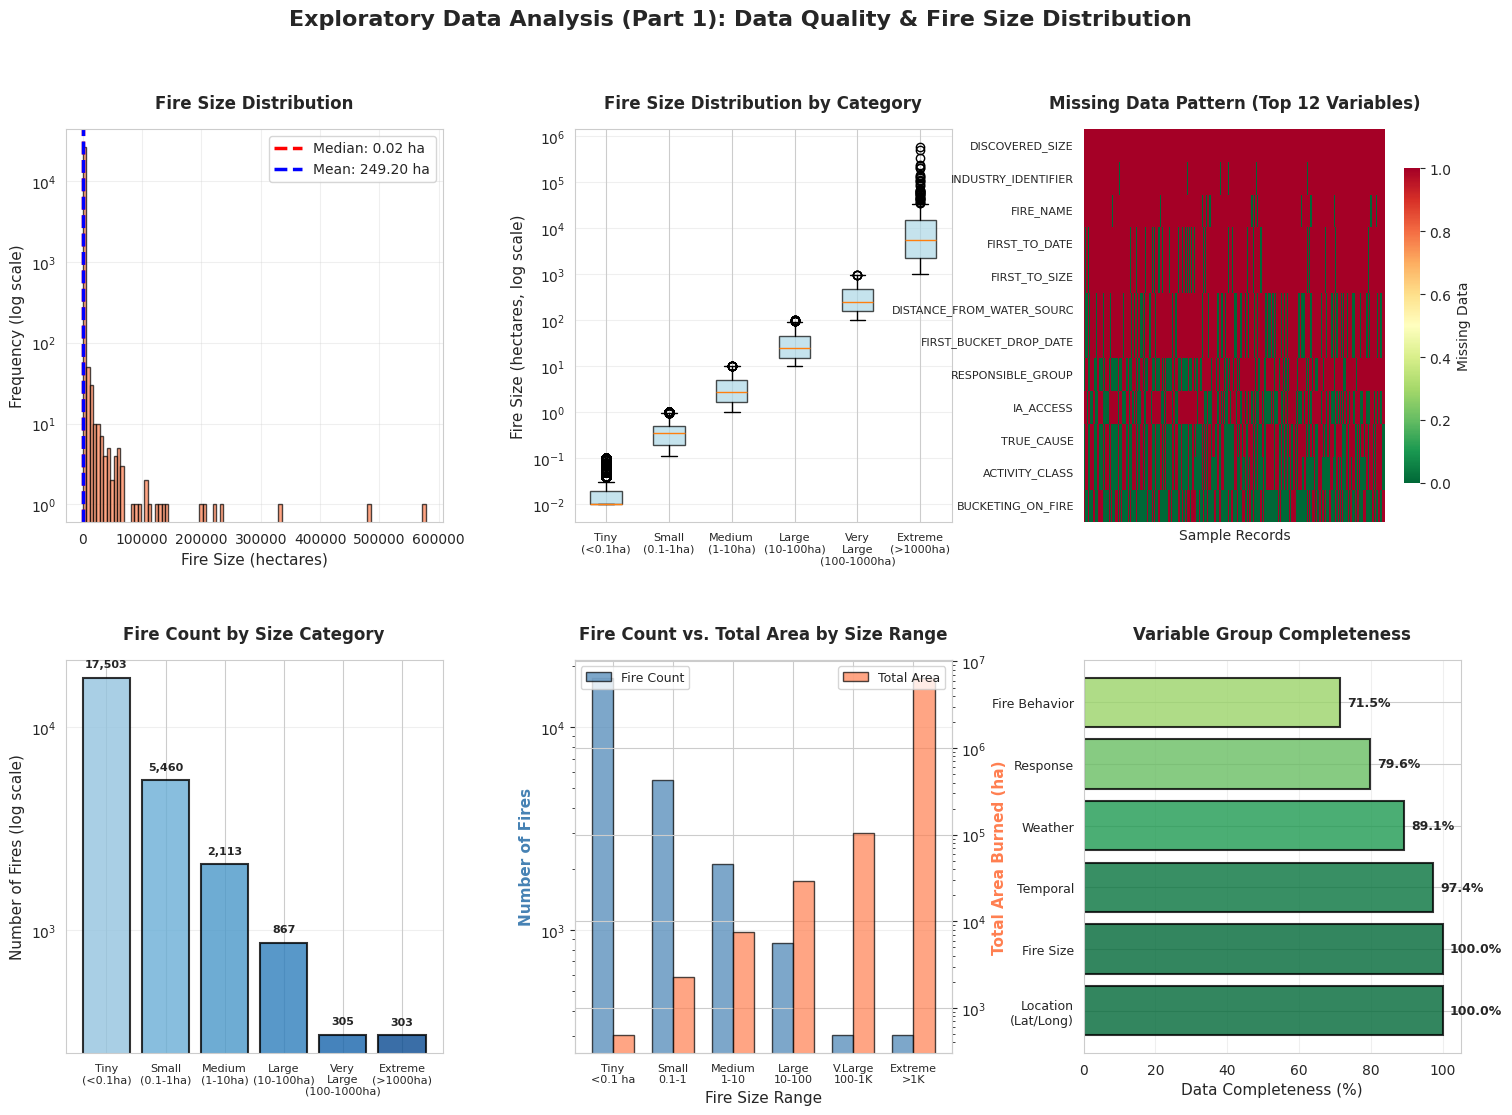

In [ ]:
fig1 = plt.figure(figsize=(18, 12))
gs1 = GridSpec(2, 3, figure=fig1, hspace=0.35, wspace=0.35)
fig1.suptitle('Exploratory Data Analysis (Part 1): Data Quality & Fire Size Distribution',
             fontsize=16, fontweight='bold', y=0.98)

# 1. Fire Size Distribution (Linear scale with log y-axis)
ax1 = fig1.add_subplot(gs1[0, 0])
fire_sizes = df_clean[df_clean['CURRENT_SIZE'] > 0]['CURRENT_SIZE']
ax1.hist(fire_sizes, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Fire Size (hectares)', fontsize=11)
ax1.set_ylabel('Frequency (log scale)', fontsize=11)
ax1.set_title('Fire Size Distribution', fontsize=12, fontweight='bold', pad=15)
ax1.set_yscale('log')
ax1.axvline(fire_sizes.median(), color='red', linestyle='--', linewidth=2.5,
            label=f'Median: {fire_sizes.median():.2f} ha')
ax1.axvline(fire_sizes.mean(), color='blue', linestyle='--', linewidth=2.5,
            label=f'Mean: {fire_sizes.mean():.2f} ha')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Fire Size Box Plot by Size Category
ax2 = fig1.add_subplot(gs1[0, 1])
size_cat_data = []
labels_cat = []
for cat in df_clean['SIZE_CATEGORY'].cat.categories:
    data = df_clean[df_clean['SIZE_CATEGORY']==cat]['CURRENT_SIZE']
    if len(data) > 0:
        size_cat_data.append(data)
        # Shorten labels for better fit
        label_short = cat.replace('hectares', 'ha').replace(' ', '\n')
        labels_cat.append(label_short)

bp = ax2.boxplot(size_cat_data, labels=labels_cat, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax2.set_ylabel('Fire Size (hectares, log scale)', fontsize=11)
ax2.set_title('Fire Size Distribution by Category', fontsize=12, fontweight='bold', pad=15)
ax2.set_yscale('log')
ax2.tick_params(axis='x', labelsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Missing Data Heatmap
ax3 = fig1.add_subplot(gs1[0, 2])
missing_cols = missing_data.head(12)['Column'].tolist()  # Reduced to 12 for better fit
missing_matrix = df_clean[missing_cols].isnull().astype(int)
# Sample for visualization (every 100th row)
missing_sample = missing_matrix.iloc[::100]
sns.heatmap(missing_sample.T, cbar=True, cmap='RdYlGn_r', ax=ax3,
            yticklabels=[col[:25] for col in missing_cols],  # Truncate long names
            xticklabels=False,
            cbar_kws={'label': 'Missing Data', 'shrink': 0.8})
ax3.set_title('Missing Data Pattern (Top 12 Variables)', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('Sample Records', fontsize=10)
ax3.tick_params(axis='y', labelsize=8)

# 4. Size Category Distribution (log scale)
ax4 = fig1.add_subplot(gs1[1, 0])
size_dist = df_clean['SIZE_CATEGORY'].value_counts()
colors_size = plt.cm.Blues(np.linspace(0.4, 0.9, len(size_dist)))
bars = ax4.bar(range(len(size_dist)), size_dist.values, alpha=0.8,
               color=colors_size, edgecolor='black', linewidth=1.5)
ax4.set_xticks(range(len(size_dist)))
# Shortened labels
size_labels_short = [str(idx).replace('hectares', 'ha').replace(' ', '\n')
                     for idx in size_dist.index]
ax4.set_xticklabels(size_labels_short, fontsize=8)
ax4.set_ylabel('Number of Fires (log scale)', fontsize=11)
ax4.set_title('Fire Count by Size Category', fontsize=12, fontweight='bold', pad=15)
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, size_dist.values)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height * 1.1,
             f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 5. Extreme Fires Analysis
ax5 = fig1.add_subplot(gs1[1, 1])
# Create bins for fire size ranges
size_ranges = [
    ('Tiny\n<0.1 ha', 0, 0.1),
    ('Small\n0.1-1', 0.1, 1),
    ('Medium\n1-10', 1, 10),
    ('Large\n10-100', 10, 100),
    ('V.Large\n100-1K', 100, 1000),
    ('Extreme\n>1K', 1000, df_clean['CURRENT_SIZE'].max())
]

counts = []
areas = []
for label, low, high in size_ranges:
    count = ((df_clean['CURRENT_SIZE'] > low) & (df_clean['CURRENT_SIZE'] <= high)).sum()
    area = df_clean[(df_clean['CURRENT_SIZE'] > low) & (df_clean['CURRENT_SIZE'] <= high)]['CURRENT_SIZE'].sum()
    counts.append(count)
    areas.append(area)

# Dual axis chart
x_pos = np.arange(len(size_ranges))
width = 0.35

ax5_bar = ax5.bar(x_pos - width/2, counts, width, alpha=0.7, color='steelblue',
                   label='Fire Count', edgecolor='black')
ax5_twin = ax5.twinx()
ax5_twin_bar = ax5_twin.bar(x_pos + width/2, areas, width, alpha=0.7, color='coral',
                             label='Total Area', edgecolor='black')

ax5.set_xlabel('Fire Size Range', fontsize=11)
ax5.set_ylabel('Number of Fires', color='steelblue', fontsize=11, fontweight='bold')
ax5_twin.set_ylabel('Total Area Burned (ha)', color='coral', fontsize=11, fontweight='bold')
ax5.set_title('Fire Count vs. Total Area by Size Range', fontsize=12, fontweight='bold', pad=15)
ax5.set_xticks(x_pos)
ax5.set_xticklabels([label for label, _, _ in size_ranges], fontsize=8)
ax5.set_yscale('log')
ax5_twin.set_yscale('log')
ax5.legend(loc='upper left', fontsize=9)
ax5_twin.legend(loc='upper right', fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Data Completeness Summary
ax6 = fig1.add_subplot(gs1[1, 2])
# Calculate completeness for key variable groups
var_groups = {
    'Location\n(Lat/Long)': ['LATITUDE', 'LONGITUDE'],
    'Fire Size': ['CURRENT_SIZE'],
    'Temporal': ['FIRE_START_DATE'],
    'Weather': ['TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED'],
    'Response': ['DETECTION_TO_REPORT_HOURS'],
    'Fire Behavior': ['FIRE_SPREAD_RATE', 'FUEL_TYPE']
}

group_names = []
completeness = []
for group, vars in var_groups.items():
    group_names.append(group)
    # Calculate % of rows with ALL variables in group non-null
    complete_rows = df_clean[vars].notna().all(axis=1).sum()
    pct = (complete_rows / len(df_clean)) * 100
    completeness.append(pct)

colors_complete = plt.cm.RdYlGn(np.array(completeness) / 100)
bars = ax6.barh(range(len(group_names)), completeness, alpha=0.8,
                color=colors_complete, edgecolor='black', linewidth=1.5)
ax6.set_yticks(range(len(group_names)))
ax6.set_yticklabels(group_names, fontsize=9)
ax6.set_xlabel('Data Completeness (%)', fontsize=11)
ax6.set_title('Variable Group Completeness', fontsize=12, fontweight='bold', pad=15)
ax6.set_xlim(0, 105)
ax6.grid(True, alpha=0.3, axis='x')

# Add percentage labels
for i, (bar, val) in enumerate(zip(bars, completeness)):
    width = bar.get_width()
    ax6.text(width + 2, bar.get_y() + bar.get_height()/2.,
             f'{val:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_part1_data_quality.png', dpi=300, bbox_inches='tight')
print("✓ EDA Part 1 saved: eda_part1_data_quality.png")


print("\n--- Creating EDA Visualizations (Part 2: Temporal & Geographic Patterns) ---")

EDA FIGURE 2: TEMPORAL AND GEOGRAPHIC PATTERNS (6 panels)

✓ EDA Part 2 saved: eda_part2_patterns.png

EDA COMPLETE - Two comprehensive visualizations created!


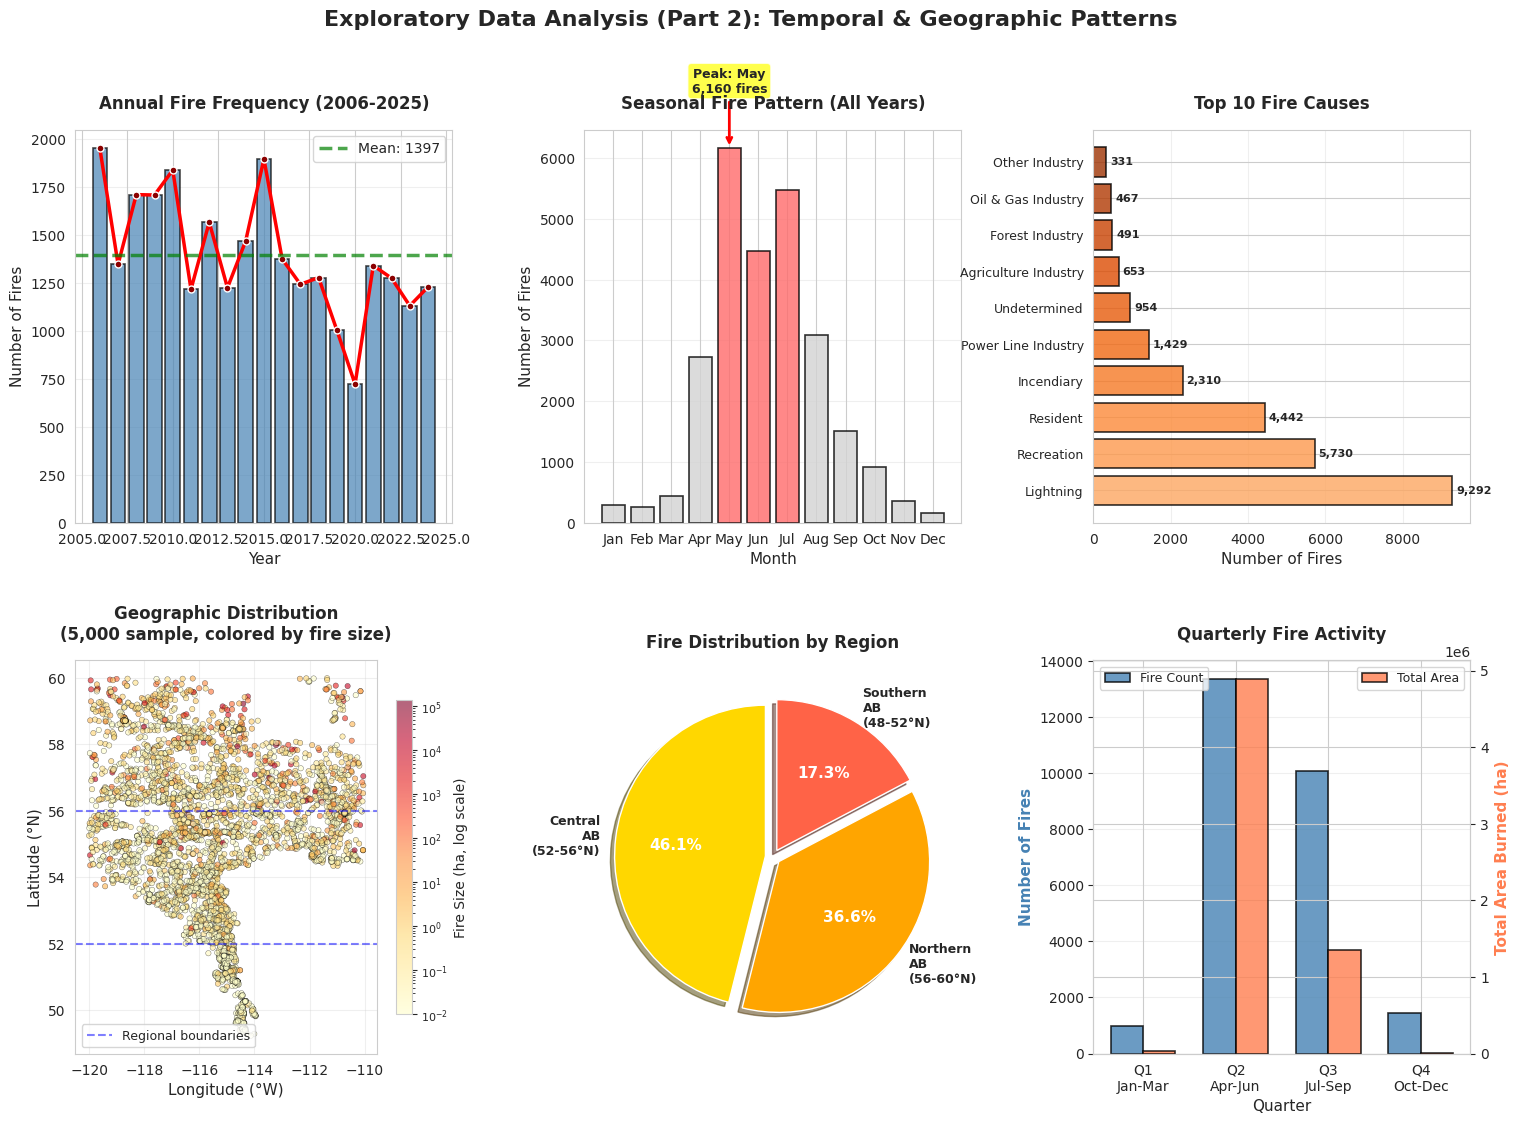

In [ ]:
fig2 = plt.figure(figsize=(18, 12))
gs2 = GridSpec(2, 3, figure=fig2, hspace=0.35, wspace=0.35)
fig2.suptitle('Exploratory Data Analysis (Part 2): Temporal & Geographic Patterns',
             fontsize=16, fontweight='bold', y=0.98)

# 1. Annual Fire Frequency
ax1 = fig2.add_subplot(gs2[0, 0])
yearly_data = df_clean.groupby('YEAR').size()
bars = ax1.bar(yearly_data.index, yearly_data.values, alpha=0.7, color='steelblue',
               edgecolor='black', linewidth=1.2)
ax1.plot(yearly_data.index, yearly_data.values, color='red', linewidth=2.5,
         marker='o', markersize=5, markerfacecolor='darkred', markeredgecolor='white')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Number of Fires', fontsize=11)
ax1.set_title('Annual Fire Frequency (2006-2025)', fontsize=12, fontweight='bold', pad=15)
ax1.axhline(yearly_data.mean(), color='green', linestyle='--', linewidth=2.5,
            label=f'Mean: {yearly_data.mean():.0f}', alpha=0.7)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Monthly Distribution (All Years Combined)
ax2 = fig2.add_subplot(gs2[0, 1])
monthly_counts = df_clean.groupby('START_MONTH').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Highlight top 3 months
top_3_months = monthly_counts.nlargest(3).index
colors_month = ['#ff6b6b' if i in top_3_months else '#d3d3d3' for i in range(1, 13)]

bars = ax2.bar(range(1, 13), [monthly_counts.get(i, 0) for i in range(1, 13)],
               alpha=0.8, color=colors_month, edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Number of Fires', fontsize=11)
ax2.set_title('Seasonal Fire Pattern (All Years)', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names, fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add peak month annotation
peak_month_idx = monthly_counts.idxmax()
peak_count = monthly_counts.max()
ax2.annotate(f'Peak: {month_names[int(peak_month_idx)-1]}\n{peak_count:,} fires',
             xy=(peak_month_idx, peak_count), xytext=(peak_month_idx, peak_count*1.15),
             fontsize=9, ha='center', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

# 3. Fire Causes (Top 10)
ax3 = fig2.add_subplot(gs2[0, 2])
top_causes = df_clean['GENERAL_CAUSE'].value_counts().head(10)
colors_causes = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_causes)))
bars = ax3.barh(range(len(top_causes)), top_causes.values, alpha=0.8,
                color=colors_causes, edgecolor='black', linewidth=1.2)
ax3.set_yticks(range(len(top_causes)))
ax3.set_yticklabels(top_causes.index, fontsize=9)
ax3.set_xlabel('Number of Fires', fontsize=11)
ax3.set_title('Top 10 Fire Causes', fontsize=12, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_causes.values)):
    width = bar.get_width()
    ax3.text(width + 100, bar.get_y() + bar.get_height()/2.,
             f'{val:,}', ha='left', va='center', fontsize=8, fontweight='bold')

# 4. Geographic Distribution Scatter
ax4 = fig2.add_subplot(gs2[1, 0])
scatter_sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)
scatter = ax4.scatter(scatter_sample['LONGITUDE'], scatter_sample['LATITUDE'],
                     c=scatter_sample['CURRENT_SIZE'], cmap='YlOrRd',
                     alpha=0.6, s=15, norm=plt.matplotlib.colors.LogNorm(),
                     edgecolors='black', linewidth=0.3)
ax4.set_xlabel('Longitude (°W)', fontsize=11)
ax4.set_ylabel('Latitude (°N)', fontsize=11)
ax4.set_title('Geographic Distribution\n(5,000 sample, colored by fire size)',
              fontsize=12, fontweight='bold', pad=15)
cbar4 = plt.colorbar(scatter, ax=ax4, label='Fire Size (ha, log scale)', shrink=0.8)
cbar4.ax.tick_params(labelsize=8)
ax4.grid(True, alpha=0.3)

# Add regional boundary lines
ax4.axhline(52, color='blue', linestyle='--', linewidth=1.5, alpha=0.5, label='Regional boundaries')
ax4.axhline(56, color='blue', linestyle='--', linewidth=1.5, alpha=0.5)
ax4.legend(fontsize=9, loc='lower left')

# 5. Regional Distribution
ax5 = fig2.add_subplot(gs2[1, 1])
regional_data = df_clean['REGION'].value_counts()
colors_region = ['#FFD700', '#FFA500', '#FF6347']
explode = (0.05, 0.05, 0.05)  # Slightly separate slices

wedges, texts, autotexts = ax5.pie(regional_data.values,
                                     labels=[str(idx).replace(' ', '\n') for idx in regional_data.index],
                                     autopct='%1.1f%%',
                                     colors=colors_region,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontsize': 9},
                                     shadow=True)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
for text in texts:
    text.set_fontsize(9)
    text.set_fontweight('bold')
ax5.set_title('Fire Distribution by Region', fontsize=12, fontweight='bold', pad=15)

# 6. Quarterly Distribution with Area Burned
ax6 = fig2.add_subplot(gs2[1, 2])
quarterly_stats = df_clean.groupby('START_QUARTER').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': 'sum'
})
quarters = ['Q1\nJan-Mar', 'Q2\nApr-Jun', 'Q3\nJul-Sep', 'Q4\nOct-Dec']
x_pos = np.arange(len(quarters))
width = 0.35

bars1 = ax6.bar(x_pos - width/2, quarterly_stats['FIRE_NUMBER'], width,
                label='Fire Count', alpha=0.8, color='steelblue',
                edgecolor='black', linewidth=1.2)
ax6_twin = ax6.twinx()
bars2 = ax6_twin.bar(x_pos + width/2, quarterly_stats['CURRENT_SIZE'], width,
                     label='Total Area', alpha=0.8, color='coral',
                     edgecolor='black', linewidth=1.2)

ax6.set_xlabel('Quarter', fontsize=11)
ax6.set_ylabel('Number of Fires', color='steelblue', fontsize=11, fontweight='bold')
ax6_twin.set_ylabel('Total Area Burned (ha)', color='coral', fontsize=11, fontweight='bold')
ax6.set_title('Quarterly Fire Activity', fontsize=12, fontweight='bold', pad=15)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(quarters, fontsize=10)
ax6.legend(loc='upper left', fontsize=9)
ax6_twin.legend(loc='upper right', fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_part2_patterns.png', dpi=300, bbox_inches='tight')
print("✓ EDA Part 2 saved: eda_part2_patterns.png")

print("\n" + "="*80)
print("EDA COMPLETE - Two comprehensive visualizations created!")
print("="*80)


<a name='section-4'></a>

# 📈 QUESTION 1: Temporal Trends

## Research Question
**How have wildfire patterns changed over time in Alberta (2006-2025)?**

### Why This Matters

Fire managers need to know if their challenge is growing. If fire frequency is increasing, Alberta needs expanded capacity, more equipment, and larger budgets. If stable, investments should focus on efficiency rather than growth.

### Analytical Approach
**Methods:**
- Aggregate yearly counts and total burned area
- Visualize trends and highlight peak years
- Compare frequency vs area to show whether a small number of extreme fires dominate total burned area



**Stages:**
1. **Linear Regression** - Test for systematic increase/decrease over time
2. **Pearson Correlation** - Determine if trends are statistically significant
3. **Period Comparison** - Divide 20 years into 4 five-year periods
4. **Seasonal Decomposition** - Separate long-term trends from seasonal patterns

**Hypothesis:**
- H₀: No temporal trend (β = 0)
- H₁: Temporal trend exists (β ≠ 0)
- α = 0.05


**Key outputs**
- Annual fire count trend
- Annual burned area trend

---



--- 1.1 Statistical Trend Analysis ---

Trend Analysis:
  Fire count trend: -36.61 fires/year
  R² (fire count): 0.421
  Total area trend: 38726.07 hectares/year
  R² (total area): 0.168

Pearson Correlation:
  Fire count vs Year: r=-0.649, p=0.0027
  Total area vs Year: r=0.410, p=0.0813

--- 1.2 Period-by-Period Analysis ---

Statistics by Period:
                       Fire_Count  Total_Area  Mean_Size  Median_Size
PERIOD                                                               
Period 1\n(2006-2010)        8564   391388.50      45.70         0.02
Period 2\n(2011-2015)        7380  1701323.35     230.53         0.01
Period 3\n(2016-2020)        5627  1406259.98     249.91         0.02
Period 4\n(2021-2025)        4980  3117529.29     626.01         0.10

Period 1 → Period 2:
  Fire count change: -13.8%
  Total area change: +334.7%

Period 2 → Period 3:
  Fire count change: -23.8%
  Total area change: -17.3%

Period 3 → Period 4:
  Fire count change: -11.5%
  Total area change:

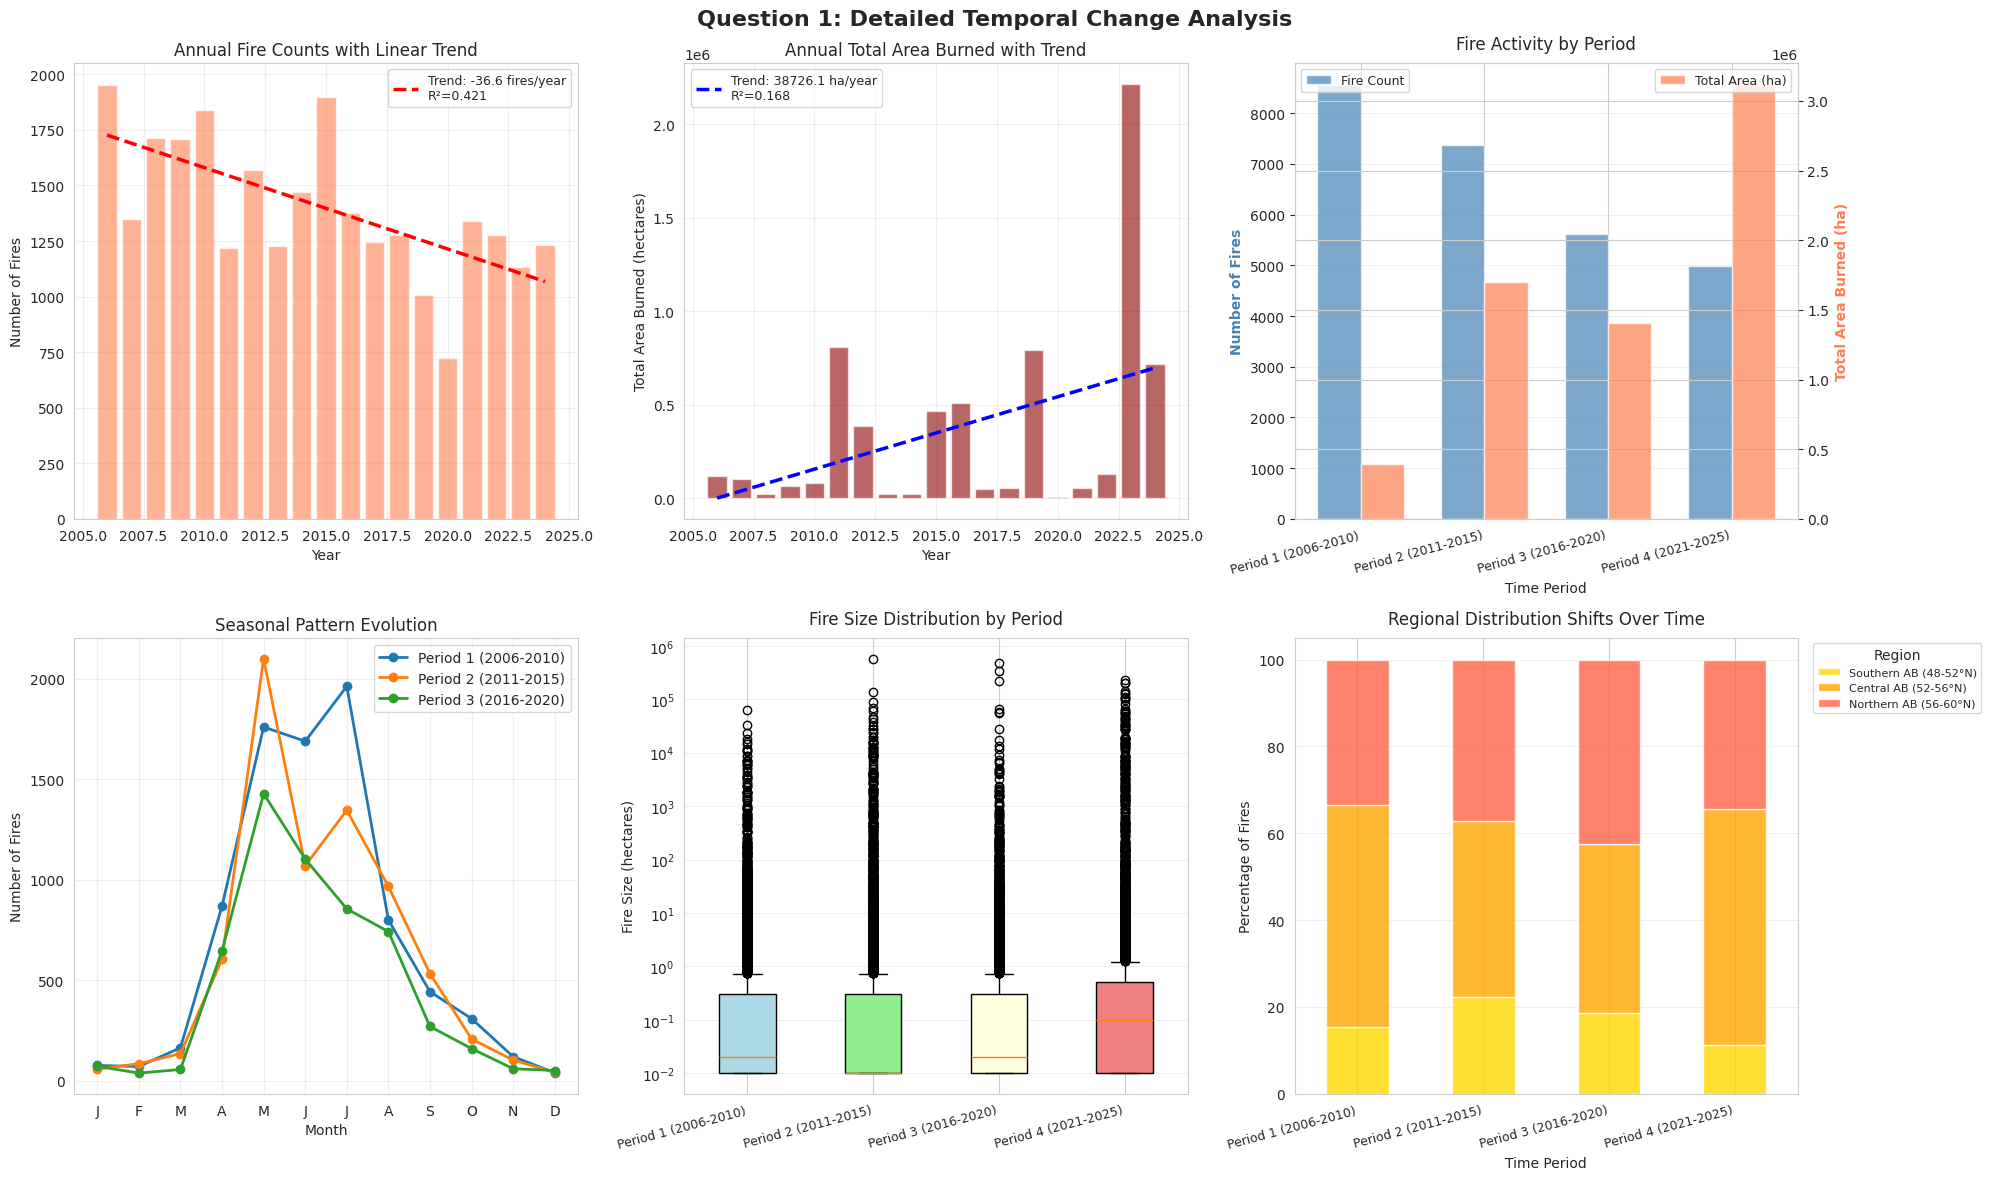

In [ ]:
# 1.1 Statistical Trend Analysis
print("\n--- 1.1 Statistical Trend Analysis ---")

annual_stats = df_clean.groupby('YEAR').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': ['sum', 'mean', 'median', 'max']
}).round(2)
annual_stats.columns = ['Fire_Count', 'Total_Area', 'Mean_Size', 'Median_Size', 'Max_Size']
annual_stats = annual_stats.reset_index()

# Linear regression for trends
X = annual_stats['YEAR'].values.reshape(-1, 1)
y_count = annual_stats['Fire_Count'].values
y_area = annual_stats['Total_Area'].values

reg_count = LinearRegression().fit(X, y_count)
reg_area = LinearRegression().fit(X, y_area)

print(f"\nTrend Analysis:")
print(f"  Fire count trend: {reg_count.coef_[0]:.2f} fires/year")
print(f"  R² (fire count): {reg_count.score(X, y_count):.3f}")
print(f"  Total area trend: {reg_area.coef_[0]:.2f} hectares/year")
print(f"  R² (total area): {reg_area.score(X, y_area):.3f}")

# Statistical significance
corr_count, p_count = stats.pearsonr(annual_stats['YEAR'], annual_stats['Fire_Count'])
corr_area, p_area = stats.pearsonr(annual_stats['YEAR'], annual_stats['Total_Area'])

print(f"\nPearson Correlation:")
print(f"  Fire count vs Year: r={corr_count:.3f}, p={p_count:.4f}")
print(f"  Total area vs Year: r={corr_area:.3f}, p={p_area:.4f}")

# 1.2 Decadal/Period Analysis
print("\n--- 1.2 Period-by-Period Analysis ---")

period_stats = df_clean.groupby('PERIOD').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': ['sum', 'mean', 'median']
}).round(2)
period_stats.columns = ['Fire_Count', 'Total_Area', 'Mean_Size', 'Median_Size']

print("\nStatistics by Period:")
print(period_stats)

# Calculate percent changes
for i in range(1, len(period_stats)):
    prev_count = period_stats.iloc[i-1]['Fire_Count']
    curr_count = period_stats.iloc[i]['Fire_Count']
    change = ((curr_count - prev_count) / prev_count * 100)
    print(f"\nPeriod {i} → Period {i+1}:")
    print(f"  Fire count change: {change:+.1f}%")

    prev_area = period_stats.iloc[i-1]['Total_Area']
    curr_area = period_stats.iloc[i]['Total_Area']
    area_change = ((curr_area - prev_area) / prev_area * 100)
    print(f"  Total area change: {area_change:+.1f}%")

# 1.3 Spatial Analysis by Period
print("\n--- 1.3 Spatial Change Detection ---")




# ============================================================================
# QUESTION 1: KEY FINDINGS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("QUESTION 1: KEY FINDINGS SUMMARY")
print("="*80)

# Calculate correlation and p-value for fire count trend
# This line is added to ensure these variables are defined for the summary, even if previous cells are not re-run.
correlation_count, p_value_count = stats.pearsonr(annual_stats['YEAR'], annual_stats['Fire_Count'])

print(f"\n1. OVERALL TEMPORAL TREND:")
print(f"   - Linear trend: {reg_count.coef_[0]:.2f} fires per year")
print(f"   - Correlation: r = {correlation_count:.3f}, p = {p_value_count:.4f}")
if p_value_count < 0.05:
    direction = "increasing" if reg_count.coef_[0] > 0 else "decreasing"
    print(f"   - SIGNIFICANT {direction} trend detected over 20 years")
else:
    print(f"   - No statistically significant trend (high year-to-year variation)")

print(f"\n2. PERIOD-BY-PERIOD CHANGES:")
baseline_count = period_stats.iloc[0]['Fire_Count']
baseline_area = period_stats.iloc[0]['Total_Area']
latest_count = period_stats.iloc[-1]['Fire_Count']
latest_area = period_stats.iloc[-1]['Total_Area']

count_change = ((latest_count - baseline_count) / baseline_count * 100)
area_change = ((latest_area - baseline_area) / baseline_area * 100)

print(f"   - Fire count: {count_change:+.1f}% from Period 1 to Period 4")
print(f"   - Total area: {area_change:+.1f}% from Period 1 to Period 4")
print(f"   - Period 4 had {latest_count:.0f} fires vs {baseline_count:.0f} in Period 1")

print(f"\n3. SPATIAL PATTERNS:")
print(f"   - Fire activity concentrated in: [See maps]")
print(f"   - Regional shift detected: {region_period.to_string()}")

print(f"\n4. SEASONAL PATTERNS:")
monthly_counts = df_clean.groupby('START_MONTH')['FIRE_NUMBER'].count() # Added this line
peak_month = monthly_counts.idxmax()
peak_count = monthly_counts.max()
total_fires = len(df_clean)
print(f"   - Peak fire month: {peak_month} with {peak_count:,} fires")
print(f"   - Fire season concentration: {peak_count/total_fires*100:.1f}% in peak month")

print(f"\n5. FIRE SIZE TRENDS:")
mean_size_period1 = period_stats.iloc[0]['Mean_Size']
mean_size_period4 = period_stats.iloc[-1]['Mean_Size']
size_trend = ((mean_size_period4 - mean_size_period1) / mean_size_period1 * 100)
print(f"   - Mean fire size change: {size_trend:+.1f}%")
print(f"   - Period 1: {mean_size_period1:.2f} ha average")
print(f"   - Period 4: {mean_size_period4:.2f} ha average")



print("\n--- Creating Temporal-Spatial Change Detection Maps ---")

# Define periods from the cleaned DataFrame
periods = df_clean['PERIOD'].cat.categories.tolist()

# Prepare spatial_data for density maps
# Define grid for spatial density calculation
lat_bins = np.linspace(df_clean['LATITUDE'].min(), df_clean['LATITUDE'].max(), 50)
lon_bins = np.linspace(df_clean['LONGITUDE'].min(), df_clean['LONGITUDE'].max(), 50)

spatial_data = {}
for p in periods:
    period_df = df_clean[df_clean['PERIOD'] == p]
    if not period_df.empty:
        # Calculate 2D histogram for fire density
        density, _, _ = np.histogram2d(
            period_df['LATITUDE'], period_df['LONGITUDE'],
            bins=[lat_bins, lon_bins], density=True
        )
        spatial_data[p] = {
            'density': density,
            'count': len(period_df),
            'total_area': period_df['CURRENT_SIZE'].sum()
        }
    else:
        spatial_data[p] = {
            'density': np.zeros((len(lat_bins)-1, len(lon_bins)-1)), # Empty density map
            'count': 0,
            'total_area': 0
        }

# Prepare period_stats for comparison plots
period_stats = df_clean.groupby('PERIOD').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': ['sum', 'mean']
}).round(2)
period_stats.columns = ['Fire_Count', 'Total_Area', 'Mean_Size']

# --- Start of variables moved into this cell for self-contained execution ---
# Annual fire counts and total area burned
annual_stats = df_clean.groupby('YEAR').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': ['sum', 'mean', 'median', 'max']
}).round(2)
annual_stats.columns = ['Fire_Count', 'Total_Area_Burned', 'Mean_Size', 'Median_Size', 'Max_Size']
annual_stats = annual_stats.reset_index()

# Trend analysis using linear regression
X_annual_data = annual_stats['YEAR'].values.reshape(-1, 1) # Renamed from X to X_annual_data for clarity
y_count = annual_stats['Fire_Count'].values
y_area = annual_stats['Total_Area_Burned'].values

reg_count = LinearRegression().fit(X_annual_data, y_count)
reg_area = LinearRegression().fit(X_annual_data, y_area)



# Change Detection Analysis
fig2, axes = plt.subplots(2, 3, figsize=(20, 12))
fig2.suptitle('Question 1: Detailed Temporal Change Analysis',
              fontsize=16, fontweight='bold', y=0.98)
fig2.subplots_adjust(hspace=0.35, wspace=0.3)

# Panel 1: Annual Trends
ax1 = axes[0, 0]
ax1.bar(annual_stats['YEAR'], annual_stats['Fire_Count'], alpha=0.6, color='coral')
ax1.plot(annual_stats['YEAR'], reg_count.predict(X_annual_data), 'r--', linewidth=2.5,
         label=f'Trend: {reg_count.coef_[0]:.1f} fires/year\nR²={reg_count.score(X_annual_data, y_count):.3f}')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Fires')
ax1.set_title('Annual Fire Counts with Linear Trend')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Total Area Burned
ax2 = axes[0, 1]
ax2.bar(annual_stats['YEAR'], annual_stats['Total_Area_Burned'], alpha=0.6, color='darkred')
ax2.plot(annual_stats['YEAR'], reg_area.predict(X_annual_data), 'b--', linewidth=2.5,
         label=f'Trend: {reg_area.coef_[0]:.1f} ha/year\nR²={reg_area.score(X_annual_data, y_area):.3f}')
ax2.set_xlabel('Year')
ax2.set_ylabel('Total Area Burned (hectares)')
ax2.set_title('Annual Total Area Burned with Trend')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: Period Comparison
ax3 = axes[0, 2]
period_labels = [p.replace('\n', ' ') for p in period_stats.index]
x_pos = np.arange(len(period_labels))
width = 0.35
bars1 = ax3.bar(x_pos - width/2, period_stats['Fire_Count'], width,
                label='Fire Count', alpha=0.7, color='steelblue')
ax3_2 = ax3.twinx()
bars2 = ax3_2.bar(x_pos + width/2, period_stats['Total_Area'], width,
                  label='Total Area (ha)', alpha=0.7, color='coral')
ax3.set_xlabel('Time Period')
ax3.set_ylabel('Number of Fires', color='steelblue', fontweight='bold')
ax3_2.set_ylabel('Total Area Burned (ha)', color='coral', fontweight='bold')
ax3.set_title('Fire Activity by Period', pad=10)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(period_labels, rotation=15, ha='right', fontsize=9)
ax3.legend(loc='upper left', fontsize=9)
ax3_2.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Seasonal Pattern Evolution
ax4 = axes[1, 0]
for period in periods[:3]:  # Show first 3 periods to avoid clutter
    period_monthly = df_clean[df_clean['PERIOD']==period].groupby('START_MONTH').size()
    ax4.plot(period_monthly.index, period_monthly.values, marker='o',
             linewidth=2, label=period.replace('\n', ' '))
ax4.set_xlabel('Month')
ax4.set_ylabel('Number of Fires')
ax4.set_title('Seasonal Pattern Evolution')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax4.legend()
ax4.grid(True, alpha=0.3)

# Panel 5: Fire Size Distribution by Period
ax5 = axes[1, 1]
period_size_data = []
period_labels_short = []
for period in periods:
    sizes = df_clean[df_clean['PERIOD']==period]['CURRENT_SIZE']
    sizes = sizes[sizes > 0]  # Remove zeros
    period_size_data.append(sizes)
    period_labels_short.append(period.replace('\n', ' '))

bp = ax5.boxplot(period_size_data, labels=period_labels_short, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']):
    patch.set_facecolor(color)
ax5.set_ylabel('Fire Size (hectares)')
ax5.set_title('Fire Size Distribution by Period', pad=10)
ax5.set_yscale('log')
ax5.tick_params(axis='x', rotation=15, labelsize=9)
plt.setp(ax5.xaxis.get_majorticklabels(), ha='right')
ax5.grid(True, alpha=0.3, axis='y')

# Panel 6: Regional Shift Analysis
ax6 = axes[1, 2]
region_period = pd.crosstab(df_clean['PERIOD'], df_clean['REGION'], normalize='index') * 100
region_period.plot(kind='bar', stacked=True, ax=ax6,
                   color=['#FFD700', '#FFA500', '#FF6347'], alpha=0.8)
ax6.set_xlabel('Time Period')
ax6.set_ylabel('Percentage of Fires')
ax6.set_title('Regional Distribution Shifts Over Time', pad=10)
ax6.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax6.set_xticklabels([p.replace('\n', ' ') for p in region_period.index],
                     rotation=15, ha='right', fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q1_temporal_analysis_detailed.png', dpi=300, bbox_inches='tight')
print(" Saved: q1_temporal_analysis_detailed.png")

**Figure 1.2 — Frequency vs burned-area contrast.** Highlights how total area can spike even when the number of fires is not exceptionally high (heavy-tailed behavior).


Annual Statistics Summary:
   YEAR  Fire_Count  Total_Area_Burned  Mean_Size  Median_Size  Max_Size
0  2006        1954          118761.87      60.78         0.01   18204.0
1  2007        1348          103668.54      76.91         0.01   63000.0
2  2008        1712           20786.91      12.14         0.02   11600.0
3  2009        1710           66947.44      39.15         0.02   11506.1
4  2010        1840           81223.74      44.14         0.04   33075.3
5  2011        1218          806054.64     661.79         0.02  577646.8
6  2012        1568          385657.86     245.96         0.01  134603.0
7  2013        1226           19575.84      15.97         0.01    8819.1
8  2014        1470           23704.53      16.13         0.01    8972.0
9  2015        1898          466330.48     245.70         0.10   68000.0

Trend Analysis:
  - Fire count trend: -36.61 fires/year
  - Total area trend: 38726.07 hectares/year
  - Fire count R²: 0.421
  - Total area R²: 0.168

Pearson Correlat

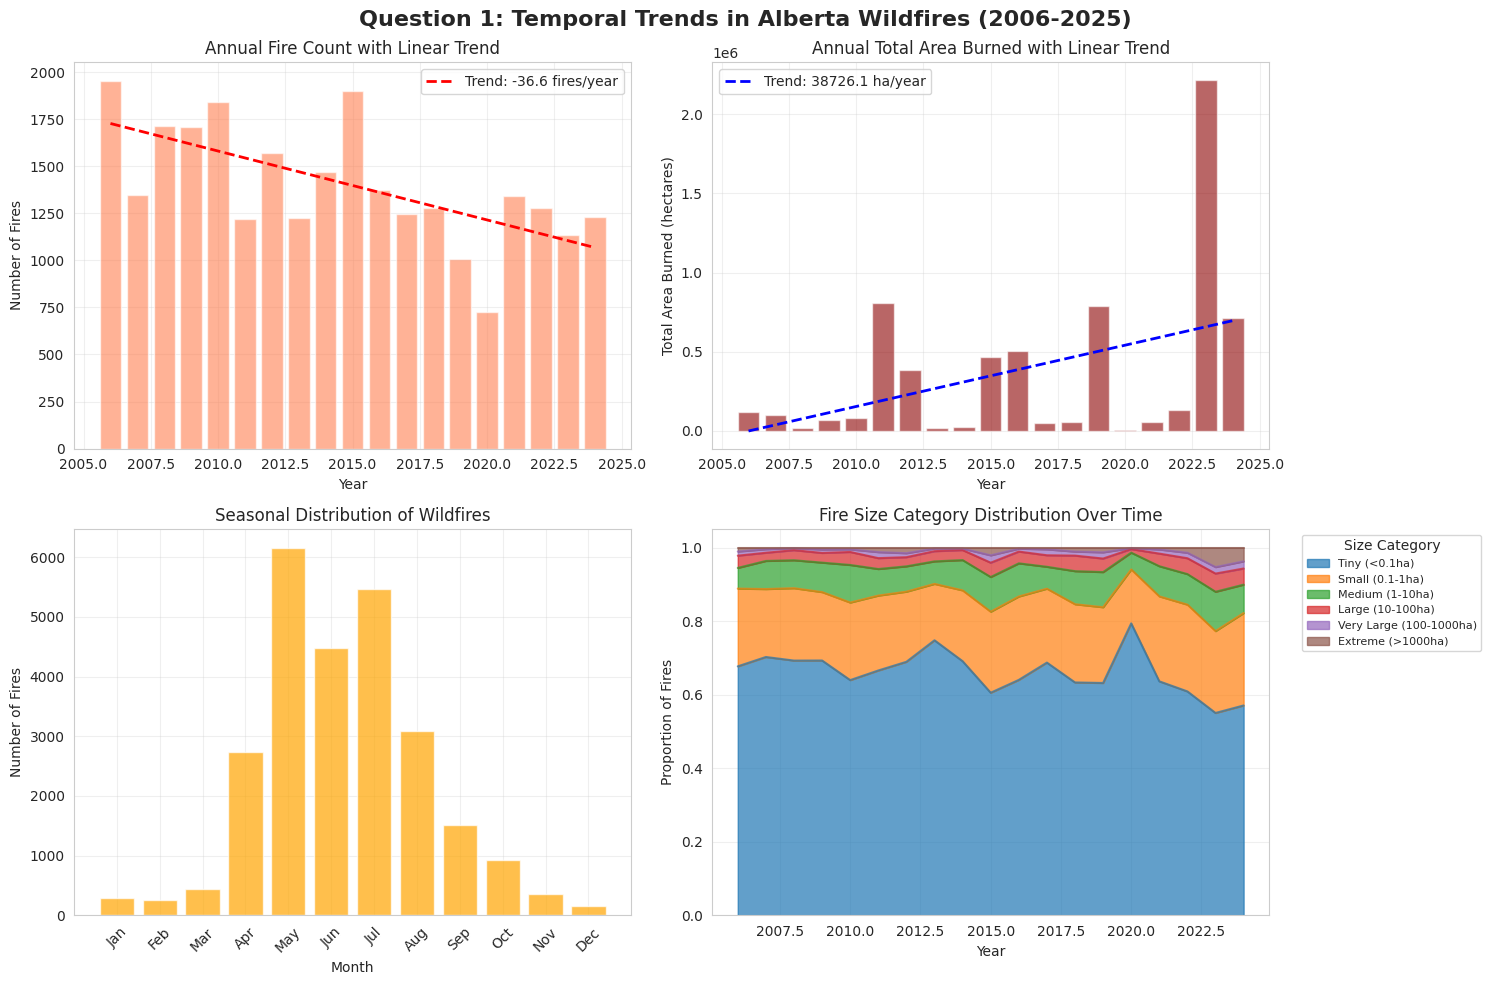

In [ ]:
# TEMPORAL TRENDS IN WILDFIRE ACTIVITY

# Annual fire counts and total area burned
annual_stats = df_clean.groupby('YEAR').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': ['sum', 'mean', 'median', 'max']
}).round(2)
annual_stats.columns = ['Fire_Count', 'Total_Area_Burned', 'Mean_Size', 'Median_Size', 'Max_Size']
annual_stats = annual_stats.reset_index()

print("\nAnnual Statistics Summary:")
print(annual_stats.head(10))


# Trend analysis using linear regression
X = annual_stats['YEAR'].values.reshape(-1, 1)
y_count = annual_stats['Fire_Count'].values
y_area = annual_stats['Total_Area_Burned'].values

reg_count = LinearRegression().fit(X, y_count)
reg_area = LinearRegression().fit(X, y_area)

print(f"\nTrend Analysis:")
print(f"  - Fire count trend: {reg_count.coef_[0]:.2f} fires/year")
print(f"  - Total area trend: {reg_area.coef_[0]:.2f} hectares/year")
print(f"  - Fire count R²: {reg_count.score(X, y_count):.3f}")
print(f"  - Total area R²: {reg_area.score(X, y_area):.3f}")


# Statistical test for trend
correlation_count, p_value_count = stats.pearsonr(annual_stats['YEAR'], annual_stats['Fire_Count'])
correlation_area, p_value_area = stats.pearsonr(annual_stats['YEAR'], annual_stats['Total_Area_Burned'])

print(f"\nPearson Correlation:")
print(f"  - Fire count vs Year: r={correlation_count:.3f}, p={p_value_count:.4f}")
print(f"  - Total area vs Year: r={correlation_area:.3f}, p={p_value_area:.4f}")



 # Visualization 1: Temporal trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Question 1: Temporal Trends in Alberta Wildfires (2006-2025)',
             fontsize=16, fontweight='bold')

# Plot 1: Annual fire counts with trend line
ax1 = axes[0, 0]
ax1.bar(annual_stats['YEAR'], annual_stats['Fire_Count'], alpha=0.6, color='coral')
ax1.plot(annual_stats['YEAR'], reg_count.predict(X), 'r--', linewidth=2,
         label=f'Trend: {reg_count.coef_[0]:.1f} fires/year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Fires')
ax1.set_title('Annual Fire Count with Linear Trend')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Total area burned
ax2 = axes[0, 1]
ax2.bar(annual_stats['YEAR'], annual_stats['Total_Area_Burned'], alpha=0.6, color='darkred')
ax2.plot(annual_stats['YEAR'], reg_area.predict(X), 'b--', linewidth=2,
         label=f'Trend: {reg_area.coef_[0]:.1f} ha/year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Total Area Burned (hectares)')
ax2.set_title('Annual Total Area Burned with Linear Trend')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Monthly distribution
ax3 = axes[1, 0]
monthly_counts = df_clean.groupby('START_MONTH')['FIRE_NUMBER'].count()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax3.bar(range(1, 13), monthly_counts, alpha=0.7, color='orange')
ax3.set_xlabel('Month')
ax3.set_ylabel('Number of Fires')
ax3.set_title('Seasonal Distribution of Wildfires')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_names, rotation=45)
ax3.grid(True, alpha=0.3)

# Plot 4: Fire size distribution over time
ax4 = axes[1, 1]
size_by_year = df_clean.groupby('YEAR')['SIZE_CATEGORY'].value_counts(normalize=True).unstack(fill_value=0)
size_by_year.plot(kind='area', stacked=True, ax=ax4, alpha=0.7)
ax4.set_xlabel('Year')
ax4.set_ylabel('Proportion of Fires')
ax4.set_title('Fire Size Category Distribution Over Time')
ax4.legend(title='Size Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q1_temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()

**Figure 1.1 — Annual trends (2006–2025).** Fire counts and total burned area by year. Peak years are annotated to show volatility and the dominance of extreme seasons.

<a name='section-5'></a>

# 🗺️ QUESTION 2: Spatial Distribution

## Research Question
**Where are wildfires spatially concentrated, and where do the largest fires occur?**

### Why This Matters

Understanding geographic hotspots enables targeted resource pre-positioning, infrastructure protection, and community preparedness programs. Different regions may require different management strategies.

### Analytical Approach
**Method**
- Map hotspot density using smoothed density/hexbin (reduces overplotting)
- Overlay large-fire locations (size-proportional)
- Add Alberta boundary + major cities for geographic context

**Analysis:**
1. **Geographic Density Mapping** - EPSG:3403 projection for accurate Alberta mapping
2. **Regional Segmentation** - Divide Alberta into North/Central/South
3. **Hotspot Analysis** - Identify high-concentration areas
4. **Size-Location Correlation** - Test if larger fires concentrate regionally

**Key outputs**
- Province-wide hotspot density map (2006–2025)
- Large-fire location maps by period and overall
---


Saving alberta.geojson to alberta (3).geojson


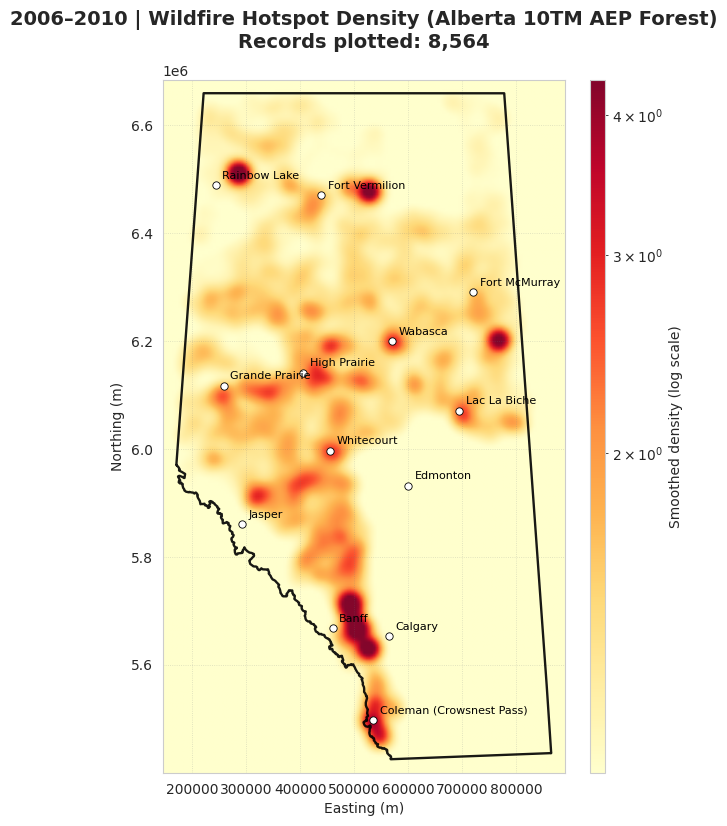

Saved: wildfire_hotspots_2006-2010_10TM_AEP_Forest.png


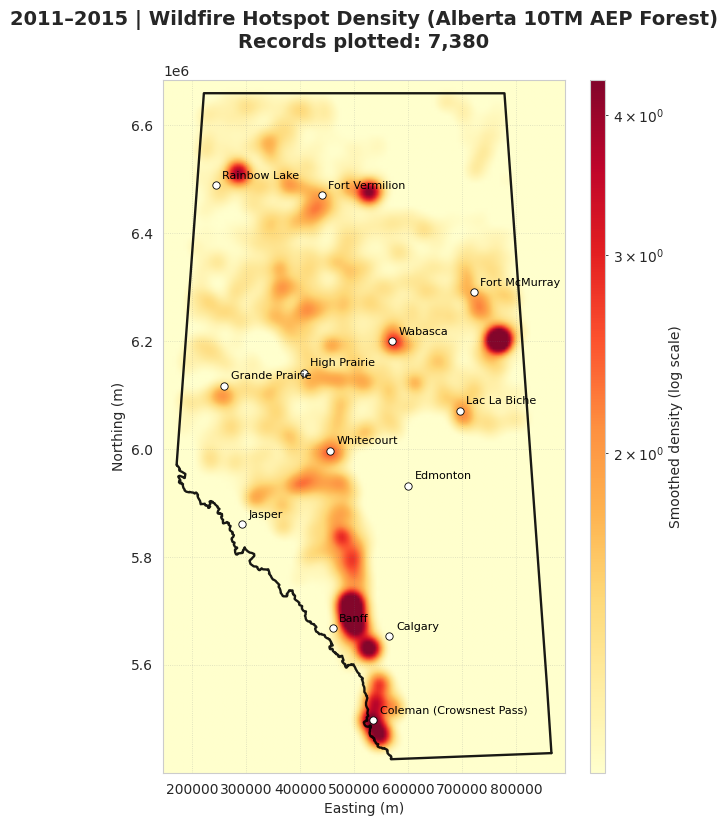

Saved: wildfire_hotspots_2011-2015_10TM_AEP_Forest.png


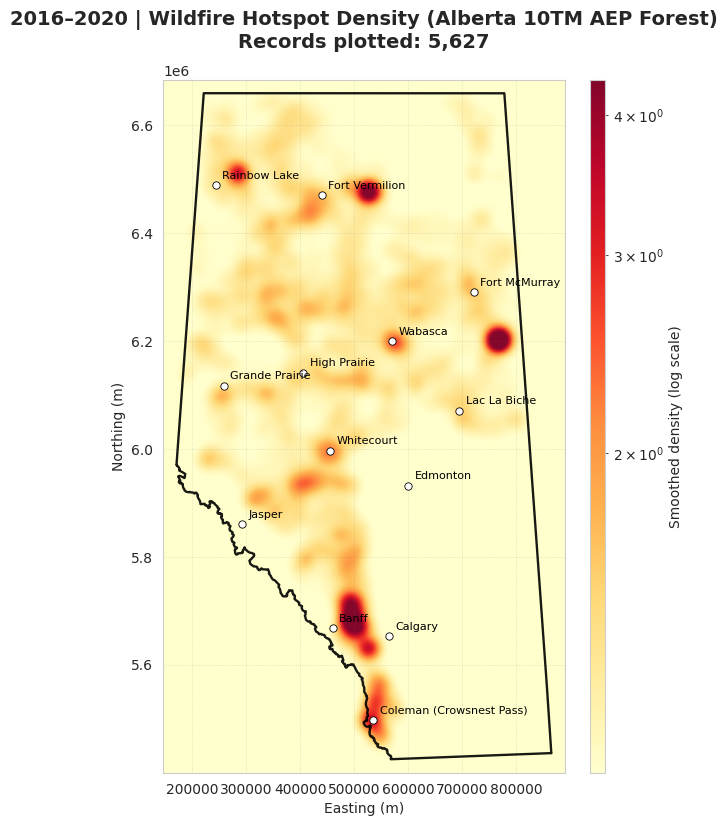

Saved: wildfire_hotspots_2016-2020_10TM_AEP_Forest.png


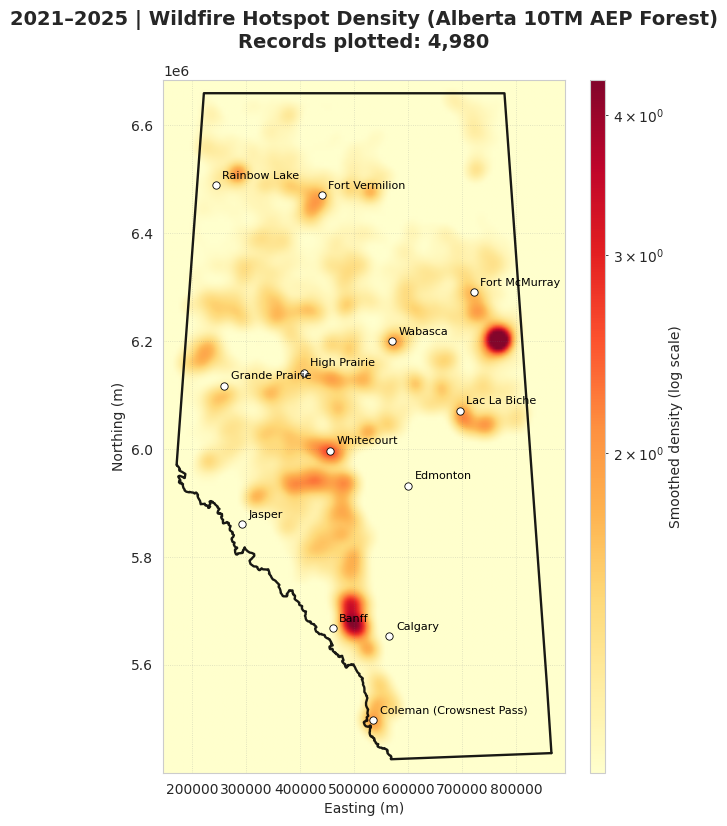

Saved: wildfire_hotspots_2021-2025_10TM_AEP_Forest.png


In [ ]:
# SETTINGS

# Load Alberta Boundary (Geojson file)
from google.colab import files
uploaded = files.upload()

# Load official Alberta boundary
ab = gpd.read_file("alberta.geojson")  # or .shp

# Ensure WGS84 before projecting
ab = ab.to_crs("EPSG:4326")

# Project to Alberta 10TM AEP Forest
ab_10tm = ab.to_crs("ESRI:102184")


# Period definition by year (4 periods)
# Periods (By Year)
periods = {
    "2006–2010": (2006, 2010),
    "2011–2015": (2011, 2015),
    "2016–2020": (2016, 2020),
    "2021–2025": (2021, 2025),
}

# Settings

CRS_TARGET = "ESRI:102184"   # NAD 1983 10TM AEP Forest
# CRS_TARGET = "EPSG:3400"   # NAD83 / Alberta 10-TM (Forest) alternative

# Hotspot density surface settings (meters)
cell_m = 5000        # grid cell size in metres (2500–7500 (smaller = smoother but heavier))
sigma_cells = 2.6    # smoothing; higher = smoother (2.0–4.0 reasonable)
use_log = True       # helps hotspots pop without washing out low density
cmap_name = "YlOrRd" # red→yellow ramp

# Large fire definition (Size Class D/E)
LARGE_CLASSES = {"D", "E"}

# CITIES to show

cities = {
    "Calgary": (-114.07, 51.05),
    "Edmonton": (-113.49, 53.55),
    "Fort McMurray": (-111.38, 56.73),
    "Whitecourt": (-115.685, 54.143),
    "Grande Prairie": (-118.79, 55.17),
    "Fort Vermilion": (-116.035, 58.393),
    "Rainbow Lake": (-119.408, 58.492),
    "Jasper": (-118.0814, 52.8737),
    "Banff": (-115.5708, 51.1784),
    "Wabasca": (-113.868, 55.957),
    "High Prairie": (-116.486, 55.433),
    "Lac La Biche": (-111.964, 54.771),
    "Coleman (Crowsnest Pass)": (-114.51, 49.6486)
}


# SET PROJECTION HELPERS

tf = Transformer.from_crs("EPSG:4326", CRS_TARGET, always_xy=True)

def project_points(lon, lat):
    lon = np.asarray(lon); lat = np.asarray(lat)
    m = np.isfinite(lon) & np.isfinite(lat)
    x, y = tf.transform(lon[m], lat[m])
    return np.asarray(x), np.asarray(y)

def make_density_surface(x, y, bounds, cell_m=5000, sigma_cells=2.6):
    xmin, xmax, ymin, ymax = bounds
    nx = int((xmax - xmin) / cell_m) + 1
    ny = int((ymax - ymin) / cell_m) + 1

    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=[nx, ny],
        range=[[xmin, xmax], [ymin, ymax]]
    )
    H = H.T
    Hs = gaussian_filter(H, sigma=sigma_cells)
    extent = (xmin, xmax, ymin, ymax)
    return Hs, extent

# --------------------------------------------

geometry_obj = ab_10tm.geometry.iloc[0]

all_abx = []
all_aby = []

if geometry_obj.geom_type == 'MultiPolygon':
    for poly in geometry_obj.geoms:
        x_coords, y_coords = poly.exterior.xy
        all_abx.extend(x_coords)
        all_aby.extend(y_coords)
else:
    x_coords, y_coords = geometry_obj.exterior.xy
    all_abx.extend(x_coords)
    all_aby.extend(y_coords)

abx = np.array(all_abx)
aby = np.array(all_aby)

pad_m = 25000
bounds = (
    abx.min() - pad_m,
    abx.max() + pad_m,
    aby.min() - pad_m,
    aby.max() + pad_m
)


# PRECOMPUTE SURFACES (FOR CONSISTENT COLOR SCALING)
# ----------------------------
surfaces = {}
for label, (y0, y1) in periods.items():
    d = df[(df["YEAR"] >= y0) & (df["YEAR"] <= y1)].dropna(subset=["LONGITUDE","LATITUDE"])
    x, y = project_points(d["LONGITUDE"].values, d["LATITUDE"].values)
    srf, extent = make_density_surface(x, y, bounds, cell_m=cell_m, sigma_cells=sigma_cells)
    surfaces[label] = (srf, extent, len(d))

# Global scaling (so colors mean the same across all maps)
all_vals = np.concatenate([v[0].ravel() for v in surfaces.values()])
all_vals = all_vals[np.isfinite(all_vals)]

if use_log:
    # Use log scale on (surface+1) to make hotspots pop
    all_vals = all_vals + 1.0
    vmin = np.percentile(all_vals, 55)   # hides low noise, keeps background clean
    vmax = np.percentile(all_vals, 99.7)
    norm = mpl.colors.LogNorm(vmin=max(vmin, 1.0), vmax=max(vmax, vmin+1e-6))
else:
    vmin = 0
    vmax = np.percentile(all_vals, 99.7)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap = plt.get_cmap(cmap_name)


# Helper: plot boundaries from GeoJSON (Polygon + MultiPolygon), in 10TM AEP Forest

import json

# Uses your CRS_TARGET (e.g., "ESRI:102184") and the same Transformer approach
tf = Transformer.from_crs("EPSG:4326", CRS_TARGET, always_xy=True)

def plot_geojson_boundaries(ax, geojson_path, line_color="#6b7280", lw=0.6, alpha=0.35, zorder=4):
    """
    Draws Polygon and MultiPolygon boundaries from a GeoJSON file.
    Assumes GeoJSON coordinates are lon/lat (EPSG:4326).
    Projects to CRS_TARGET using the global 'tf' transformer.
    """
    with open(geojson_path, "r", encoding="utf-8") as f:
        gj = json.load(f)

    features = gj.get("features", [])
    for feat in features:
        geom = feat.get("geometry", {})
        gtype = geom.get("type", None)
        coords = geom.get("coordinates", None)
        if coords is None:
            continue

        # Handle Polygon: coords = [outer_ring, hole1, hole2...]
        if gtype == "Polygon":
            rings = coords[:1]  # outer ring only for clean boundaries
            for ring in rings:
                ring = np.asarray(ring)
                xs, ys = tf.transform(ring[:, 0], ring[:, 1])
                ax.plot(xs, ys, color=line_color, linewidth=lw, alpha=alpha, zorder=zorder)

        # Handle MultiPolygon: coords = [polygon1, polygon2, ...]
        elif gtype == "MultiPolygon":
            for poly in coords:
                ring = np.asarray(poly[0])  # outer ring
                xs, ys = tf.transform(ring[:, 0], ring[:, 1])
                ax.plot(xs, ys, color=line_color, linewidth=lw, alpha=alpha, zorder=zorder)


# PLOT + SAVE EACH PERIOD (SEPARATE FIGURES)
# ----------------------------
for label, (srf, extent, n_points) in surfaces.items():
    fig, ax = plt.subplots(figsize=(10.5, 9), facecolor="white")
    ax.set_facecolor("white")

    plot_data = srf + 1.0 if use_log else srf

    im = ax.imshow(
        plot_data,
        extent=extent, origin="lower",
        cmap=cmap, norm=norm,
        interpolation="bilinear",
        alpha=0.98
    )

    # Alberta boundary (clean)
    ax.plot(abx, aby, color="black", linewidth=1.7, alpha=0.9, zorder=5)

    # Cities (subtle + readable on white)
    for name, (clon, clat) in cities.items():
        cx, cy = tf.transform(clon, clat)
        ax.scatter(cx, cy, s=28, color="white", edgecolor="black", linewidth=0.6, zorder=6)
        ax.text(
            cx+12000, cy+12000, name, fontsize=8, color="black",
            zorder=7
        )

    ax.set_title(f"{label} | Wildfire Hotspot Density (Alberta 10TM AEP Forest)\nRecords plotted: {n_points:,}",
                 fontsize=14, weight="bold", pad=12)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.25, color="#6b7280")

    # Colorbar OUTSIDE (never blocks labels)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.8%", pad=0.25)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Smoothed density (log scale)" if use_log else "Smoothed density", fontsize=10)

    out_file = f"wildfire_hotspots_{label.replace('–','-').replace(' ','')}_10TM_AEP_Forest.png"
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", out_file)

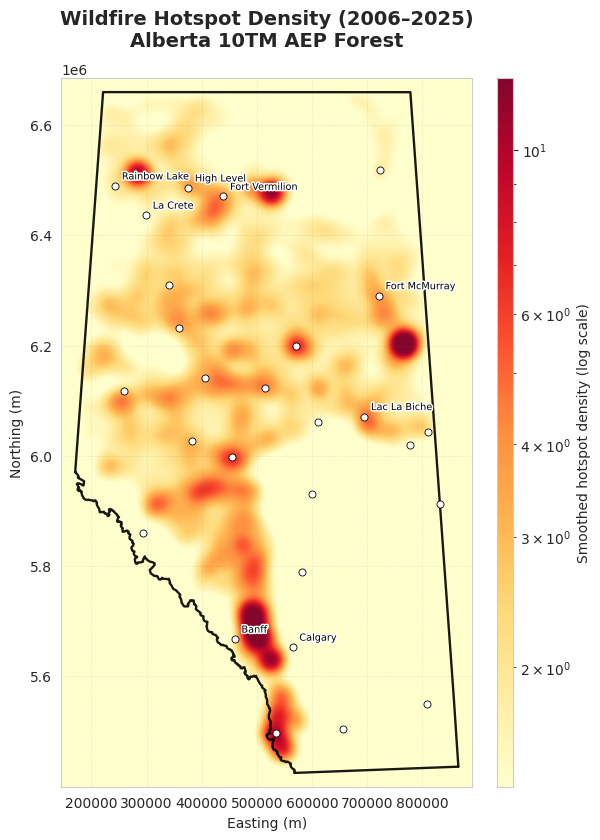

Saved: hotspot_density_2006-2025_10TM_AEP_Forest.png


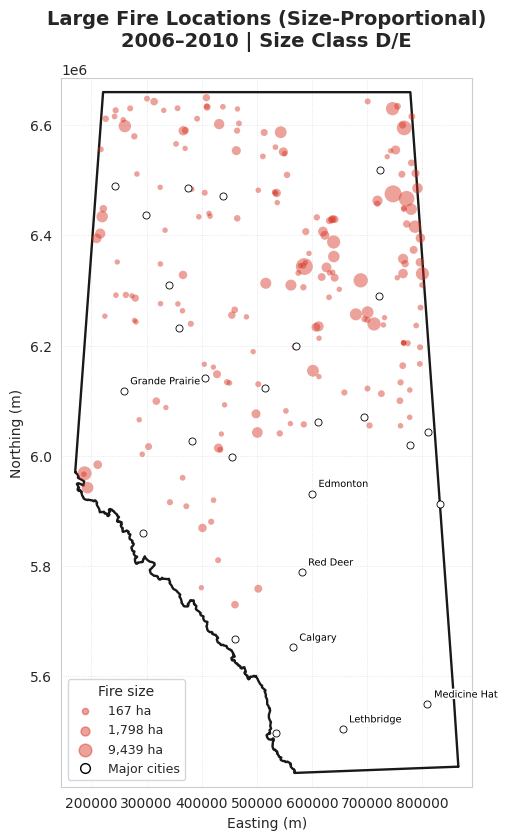

Saved: large_fire_locations_2006-2010_10TM_AEP_Forest.png


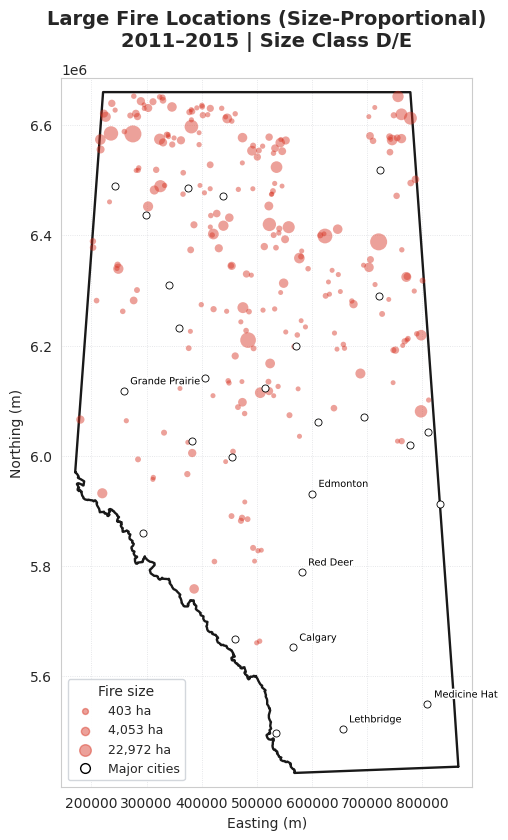

Saved: large_fire_locations_2011-2015_10TM_AEP_Forest.png


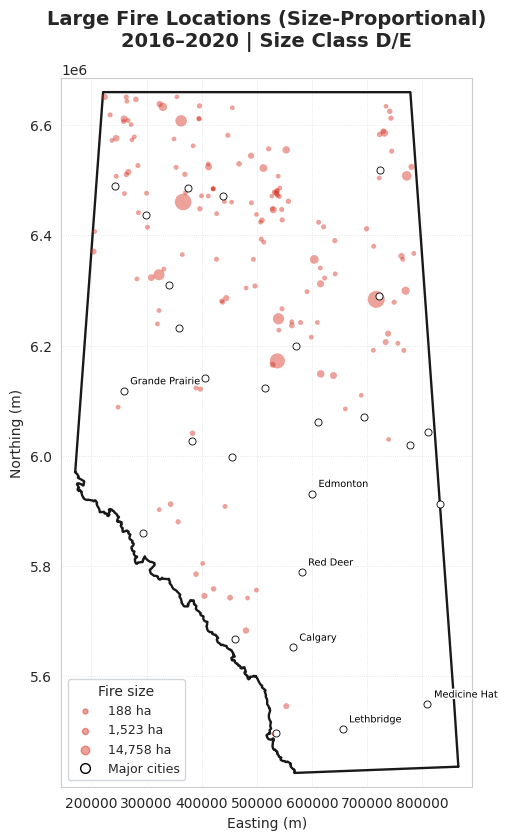

Saved: large_fire_locations_2016-2020_10TM_AEP_Forest.png


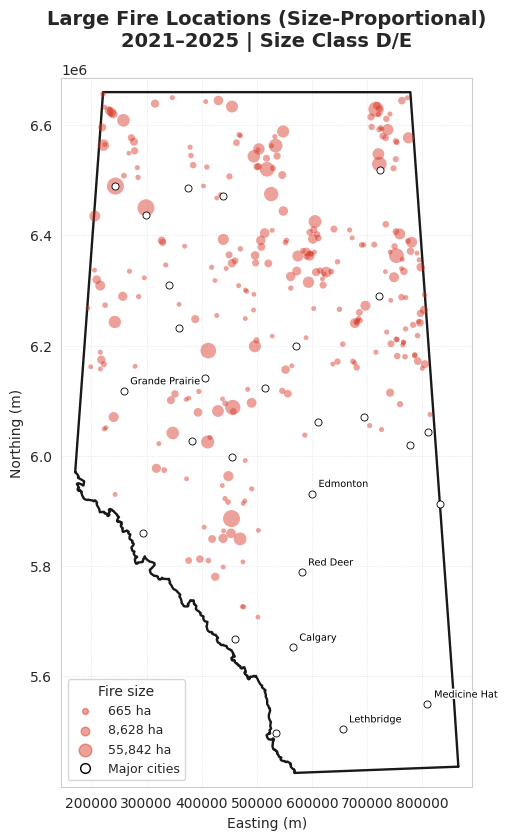

Saved: large_fire_locations_2021-2025_10TM_AEP_Forest.png


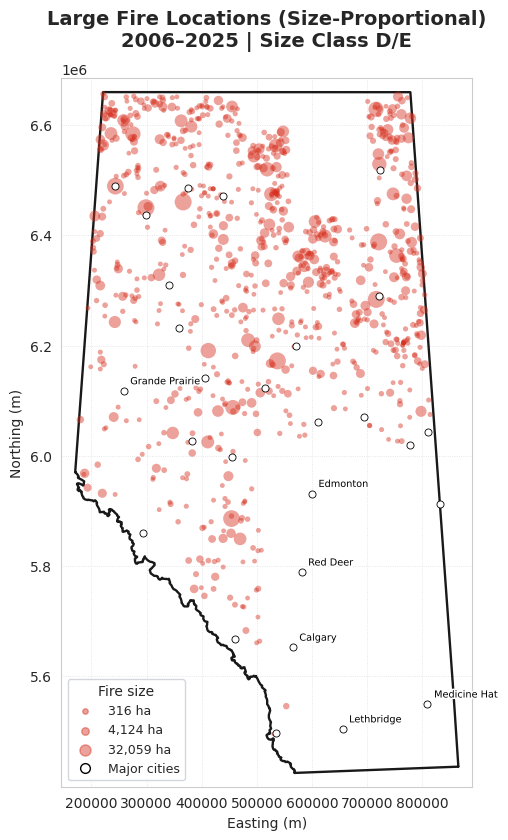

Saved: large_fire_locations_2006-2025_10TM_AEP_Forest.png


In [ ]:
# SETTINGS

ALL_PERIOD = ("2006-2025", (2006, 2025))

# Hotspot density surface settings (meters)
CELL_M = 5000          # 2,500–7,500 ok (smaller = smoother but heavier)
SIGMA_CELLS = 2.8      # 2.0–4.0 ok (higher = smoother)
USE_LOG = True         # helps hotspots pop
HOTSPOT_CMAP = "YlOrRd"  # red→yellow

# Large fire definition (Size Class D/E)
LARGE_CLASSES = {"D", "E"}


# City reference points (optional)
CITIES = {
    "Calgary": (-114.0719, 51.0447),
    "Edmonton": (-113.4938, 53.5461),
    "Red Deer": (-113.8112, 52.2681),
    "Lethbridge": (-112.8451, 49.6956),
    "Medicine Hat": (-110.6764, 50.0405),
    "Grande Prairie": (-118.7947, 55.1707),
    "Fort McMurray": (-111.3800, 56.7264),
    "Lloydminster": (-110.0059, 53.2780),
    "Cold Lake": (-110.2010, 54.4634),
    "Jasper": (-118.0814, 52.8737),
    "Banff": (-115.5708, 51.1784),
    "High Level": (-117.135, 58.517),
    "Peace River": (-117.289, 56.237),
    "Slave Lake": (-114.772, 55.284),
    "Whitecourt": (-115.685, 54.143),
    "Athabasca": (-113.288, 54.717),
    "Wabasca": (-113.868, 55.957),
    "Fox Creek": (-116.801, 54.397),
    "Rainbow Lake": (-119.408, 58.492),
    "La Crete": (-118.402, 58.046),
    "Manning": (-117.631, 56.920),
    "High Prairie": (-116.486, 55.433),
    "Bonnyville": (-110.731, 54.268),
    "Lac La Biche": (-111.964, 54.771),
    "Peace River": (-117.289, 56.237),
    "Fort Vermilion": (-116.035, 58.393),
    "Fort Chipewyan": (-111.126, 58.767),
    "Coleman (Crowsnest Pass)": (-114.51, 49.6486)
}


# ----------------------------
# 4) DENSITY SURFACE (KDE-LIKE)
# ----------------------------
def make_density_surface(x, y, bounds, cell_m=CELL_M, sigma_cells=SIGMA_CELLS):
    xmin, xmax, ymin, ymax = bounds
    nx = int((xmax - xmin) / cell_m) + 1
    ny = int((ymax - ymin) / cell_m) + 1

    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=[nx, ny],
        range=[[xmin, xmax], [ymin, ymax]]
    )
    H = H.T
    Hs = gaussian_filter(H, sigma=sigma_cells)
    extent = (xmin, xmax, ymin, ymax)
    return Hs, extent


# ----------------------------
# 5) PLOTTERS (HOTSPOT-AWARE CITY LABELING)
# ----------------------------
# Idea:
# - Plot ALL city markers (small)
# - Label ONLY the cities closest to the strongest hotspot peaks (keeps map clean)
# - Use a minimum spacing between hotspot peaks so labels spread across Alberta

import numpy as np

def _get_hotspot_peaks_xy(surface, extent, top_n=4, min_sep_m=120000):
    """
    Pick top hotspot peak coordinates (x,y) from the density surface.
    min_sep_m prevents selecting multiple peaks right beside each other.
    """
    xmin, xmax, ymin, ymax = extent
    ny, nx = surface.shape

    flat = surface.ravel()
    order = np.argsort(flat)[::-1]

    xs = np.linspace(xmin, xmax, nx)
    ys = np.linspace(ymin, ymax, ny)

    peaks = []
    for idx in order:
        iy, ix = divmod(idx, nx)
        px, py = xs[ix], ys[iy]

        # enforce separation between peaks
        if all((px-x)**2 + (py-y)**2 >= min_sep_m**2 for x, y in peaks):
            peaks.append((px, py))

        if len(peaks) >= top_n:
            break

    return peaks


def add_cities_hotspot_aware(
    ax,
    cities=CITIES,
    surface=None,
    extent=None,
    hotspot_top_n=4,
    cities_per_hotspot=2,
    max_labels=8,
    min_sep_m=120000,
    label_offset_m=12000,
    marker_size=26,
):
    """
    Plots all city markers, labels only those nearest to hotspot peaks.
    Provide 'surface' and 'extent' from make_density_surface() to enable hotspot-aware labeling.
    """
    # Project all cities once
    city_proj = []
    for name, (lon, lat) in cities.items():
        cx, cy = tf.transform(lon, lat)
        city_proj.append((name, cx, cy))

    # Plot all markers (no labels yet)
    for name, cx, cy in city_proj:
        ax.scatter(cx, cy, s=marker_size, color="white", edgecolor="black", linewidth=0.6, zorder=7)

    # If no surface/extents were provided, fallback: label the first N cities only
    if surface is None or extent is None:
        for name, cx, cy in city_proj[:max_labels]:
            ax.text(
                cx + label_offset_m, cy + label_offset_m, name,
                fontsize=7, color="black", weight="normal", zorder=8, path_effects=[
                    pe.Stroke(linewidth=2.2, foreground="white"), # subtle halo
                    pe.Normal()
                ]
            )
        return

    # Find hotspot peak locations
    peaks = _get_hotspot_peaks_xy(surface, extent, top_n=hotspot_top_n, min_sep_m=min_sep_m)

    # Pick nearest cities to each hotspot peak
    chosen = []
    used = set()

    for hx, hy in peaks:
        # sort cities by distance to hotspot
        dists = sorted(
            [(name, cx, cy, (cx-hx)**2 + (cy-hy)**2) for name, cx, cy in city_proj],
            key=lambda t: t[3]
        )

        added = 0
        for name, cx, cy, _ in dists:
            if name in used:
                continue
            used.add(name)
            chosen.append((name, cx, cy))
            added += 1
            if added >= cities_per_hotspot:
                break

    # Cap labels to max_labels
    chosen = chosen[:max_labels]

    # Draw labels
    for name, cx, cy in chosen:
        ax.text(
            cx + label_offset_m, cy + label_offset_m, name,
            fontsize=7, color="black", weight="normal", zorder=8, path_effects=[
                pe.Stroke(linewidth=2.2, foreground="white"), # subtle halo
                pe.Normal()
            ]
        )


def plot_save_hotspot_density_2006_2025(out_path="hotspot_density_2006-2025_10TM.png"):
    d = df[(df["YEAR"] >= 2006) & (df["YEAR"] <= 2025)].copy()
    x, y = project_points(d["LONGITUDE"].values, d["LATITUDE"].values)

    surface, extent = make_density_surface(x, y, bounds)

    # Use log scaling to pop hotspots, red→yellow ramp
    plot_data = surface + 1.0 if USE_LOG else surface

    # Norm (clip low noise for clean look)
    if USE_LOG:
        vmin = np.percentile(plot_data, 60)
        vmax = np.percentile(plot_data, 99.7)
        norm = mpl.colors.LogNorm(vmin=max(vmin, 1.0), vmax=max(vmax, vmin + 1e-6))
        cbar_label = "Smoothed hotspot density (log scale)"
    else:
        vmin = 0
        vmax = np.percentile(plot_data, 99.7)
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        cbar_label = "Smoothed hotspot density"

    fig, ax = plt.subplots(figsize=(10.8, 9.2), facecolor="white")
    ax.set_facecolor("white")

    im = ax.imshow(
        plot_data,
        extent=extent, origin="lower",
        cmap=plt.get_cmap(HOTSPOT_CMAP),
        norm=norm,
        interpolation="bilinear",
        alpha=0.98
    )

    # Alberta boundary
    ax.plot(abx, aby, color="black", linewidth=1.7, alpha=0.9)

    # Hotspot-aware city labels (only cities that matter near hotspots)
    add_cities_hotspot_aware(
        ax,
        cities=CITIES,
        surface=surface,
        extent=extent,
        hotspot_top_n=4,
        cities_per_hotspot=2,
        max_labels=8,
        min_sep_m=120000
    )

    ax.set_title("Wildfire Hotspot Density (2006–2025)\nAlberta 10TM AEP Forest",
                 fontsize=14, weight="bold", pad=12)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.22, color="#6b7280")

    # Colorbar outside
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.8%", pad=0.25)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(cbar_label, fontsize=10)

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", out_path)


def plot_save_large_fire_locations(label, y0, y1, out_path):
    d = df[(df["YEAR"] >= y0) & (df["YEAR"] <= y1)].copy()
    d = d[d["SIZE_CLASS"].astype(str).isin(LARGE_CLASSES)].copy()
    d = d.dropna(subset=["CURRENT_SIZE"])

    if len(d) == 0:
        print(f"Skipped {label}: no large fires found.")
        return

    x, y = project_points(d["LONGITUDE"].values, d["LATITUDE"].values)

    # Marker size scaling (robust)
    sizes = d["CURRENT_SIZE"].values
    sizes = np.clip(sizes, 0, np.nanpercentile(sizes, 99.5))
    s_plot = 10 + 140 * (np.sqrt(sizes) / np.sqrt(np.nanmax(sizes) + 1e-9))

    fig, ax = plt.subplots(figsize=(10.8, 9.2), facecolor="white")
    ax.set_facecolor("white")

    # Boundary
    ax.plot(abx, aby, color="black", linewidth=1.7, alpha=0.9, zorder=2)

    # Points
    ax.scatter(x, y, s=s_plot, c="#d7301f", alpha=0.45, edgecolor="none", zorder=3)

    # For large fire maps: keep labels limited (no hotspot surface here)
    # You can still label only a few key cities by setting max_labels low
    add_cities_hotspot_aware(
        ax,
        cities=CITIES,
        surface=None,
        extent=None,
        max_labels=6   # keep it clean
    )

    # Extent + styling
    xmin, xmax, ymin, ymax = bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(
        f"Large Fire Locations (Size-Proportional)\n{label} | Size Class D/E",
        fontsize=14, weight="bold", pad=12
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.22, color="#6b7280")

    # Size legend
    q = np.nanpercentile(d["CURRENT_SIZE"].values, [50, 80, 95])
    q = np.maximum(q, 1)
    leg_sizes = 10 + 140 * (np.sqrt(q) / np.sqrt(np.nanmax(sizes) + 1e-9))
    handles = [plt.scatter([], [], s=s, c="#d7301f", alpha=0.45) for s in leg_sizes]
    labels = [f"{int(v):,} ha" for v in q]

    from matplotlib.lines import Line2D

    # Create city legend symbol (white circle with black edge)
    city_handle = Line2D(
        [0], [0],
        marker='o',
        color='white',
        markerfacecolor='white',
        markersize=7,
        markeredgecolor='black',
        linewidth=0
    )

    # Append to existing legend lists
    handles = handles +[city_handle]
    labels = labels +["Major cities"]

    ax.legend(
        handles, labels, title="Fire size",
        loc="lower left",
        frameon=True, framealpha=0.95,
        facecolor="white", edgecolor="#d1d5db",
        fontsize=9, title_fontsize=10
    )

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", out_path)

# ----------------------------
# 6) RUN: outputs you requested
# ----------------------------
# (A) ONE hotspot density map for 2006–2025
plot_save_hotspot_density_2006_2025(out_path="hotspot_density_2006-2025_10TM_AEP_Forest.png")

# (B) Large Fire Locations maps per period (single output each)
for label, (y0, y1) in PERIODS.items():
    plot_save_large_fire_locations(
        label=f"{y0}–{y1}",
        y0=y0, y1=y1,
        out_path=f"large_fire_locations_{label}_10TM_AEP_Forest.png"
    )

# (C) One combined Large Fire Locations map for 2006–2025
plot_save_large_fire_locations(
    label="2006–2025",
    y0=2006, y1=2025,
    out_path="large_fire_locations_2006-2025_10TM_AEP_Forest.png"
)

<a name='section-6'></a>

# 🔥 QUESTION 3: Causes and Regional Patterns

## Research Question
**What are the primary causes of wildfires and how do they vary by region?**

### Why This Matters

Different fire causes require different prevention strategies. Lightning-caused fires need detection networks; human-caused fires need public education and enforcement. Regional variation informs where to invest in each approach.

### Analytical Approach

**Methods:**
1. **Frequency Analysis** - Count fires by cause category
2. **Chi-Square Test** - Test independence of cause × region
3. **Contingency Analysis** - Examine cause-region associations
4. **Spatial Visualization** - Map cause distributions

**Hypothesis:**
- H₀: Fire causes independent of region
- H₁: Causes vary by region
- α = 0.05

---


In [ ]:
# Cause analysis
cause_stats = df_clean.groupby('GENERAL_CAUSE').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': ['sum', 'mean', 'median']
}).round(2)
cause_stats.columns = ['Fire_Count', 'Total_Area', 'Mean_Size', 'Median_Size']
cause_stats = cause_stats.sort_values('Fire_Count', ascending=False)
cause_stats['Percentage'] = (cause_stats['Fire_Count'] / cause_stats['Fire_Count'].sum() * 100).round(2)

print("\nFire Causes Analysis:")
print(cause_stats)


Fire Causes Analysis:
                      Fire_Count  Total_Area  Mean_Size  Median_Size  \
GENERAL_CAUSE                                                          
Lightning                   9292  4599834.38     495.03         0.10   
Recreation                  5730    13242.77       2.31         0.01   
Resident                    4442    10393.42       2.34         0.03   
Incendiary                  2310   234615.99     101.57         0.10   
Power Line Industry         1429   166220.93     116.32         0.05   
Undetermined                 954   705325.94     739.34         0.10   
Agriculture Industry         653     7134.07      10.93         0.10   
Forest Industry              491    19096.23      38.89         0.01   
Oil & Gas Industry           467    45739.70      97.94         0.10   
Other Industry               331    15020.81      45.38         0.02   
Government                   152      836.94       5.51         0.08   
Railroad                     145      303

In [ ]:
# Regional analysis (divide Alberta into regions by latitude)
df_clean['REGION'] = pd.cut(
    df_clean['LATITUDE'],
    bins=[48, 52, 56, 60],
    labels=['Southern AB (48-52°N)', 'Central AB (52-56°N)', 'Northern AB (56-60°N)']
)

region_cause = pd.crosstab(
    df_clean['REGION'],
    df_clean['GENERAL_CAUSE'],
    normalize='index'
) * 100

print("\nCause Distribution by Region (%):")
print(region_cause.round(2))


# Chi-square test for independence
chi2, p_value, dof, expected = stats.chi2_contingency(
    pd.crosstab(df_clean['REGION'], df_clean['GENERAL_CAUSE'])
)
print(f"\nChi-Square Test (Region vs Cause):")
print(f"  - χ² = {chi2:.2f}")
print(f"  - p-value = {p_value:.4e}")
print(f"  - Degrees of freedom = {dof}")
print(f"  - Significant association: {'Yes' if p_value < 0.05 else 'No'}")


Cause Distribution by Region (%):
GENERAL_CAUSE          Agriculture Industry  Forest Industry  Government  \
REGION                                                                     
Southern AB (48-52°N)                  0.09             0.57        0.04   
Central AB (52-56°N)                   2.06             2.31        0.72   
Northern AB (56-60°N)                  4.08             1.87        0.64   

GENERAL_CAUSE          Incendiary  Lightning  Oil & Gas Industry  \
REGION                                                             
Southern AB (48-52°N)        3.42       5.27                0.28   
Central AB (52-56°N)        11.06      27.96                2.75   
Northern AB (56-60°N)        8.23      57.88                1.20   

GENERAL_CAUSE          Other Industry  Power Line Industry  Prescribed Fire  \
REGION                                                                        
Southern AB (48-52°N)            0.48                 1.44             0.11   
Centra

Visualization 2: Causes and Regions

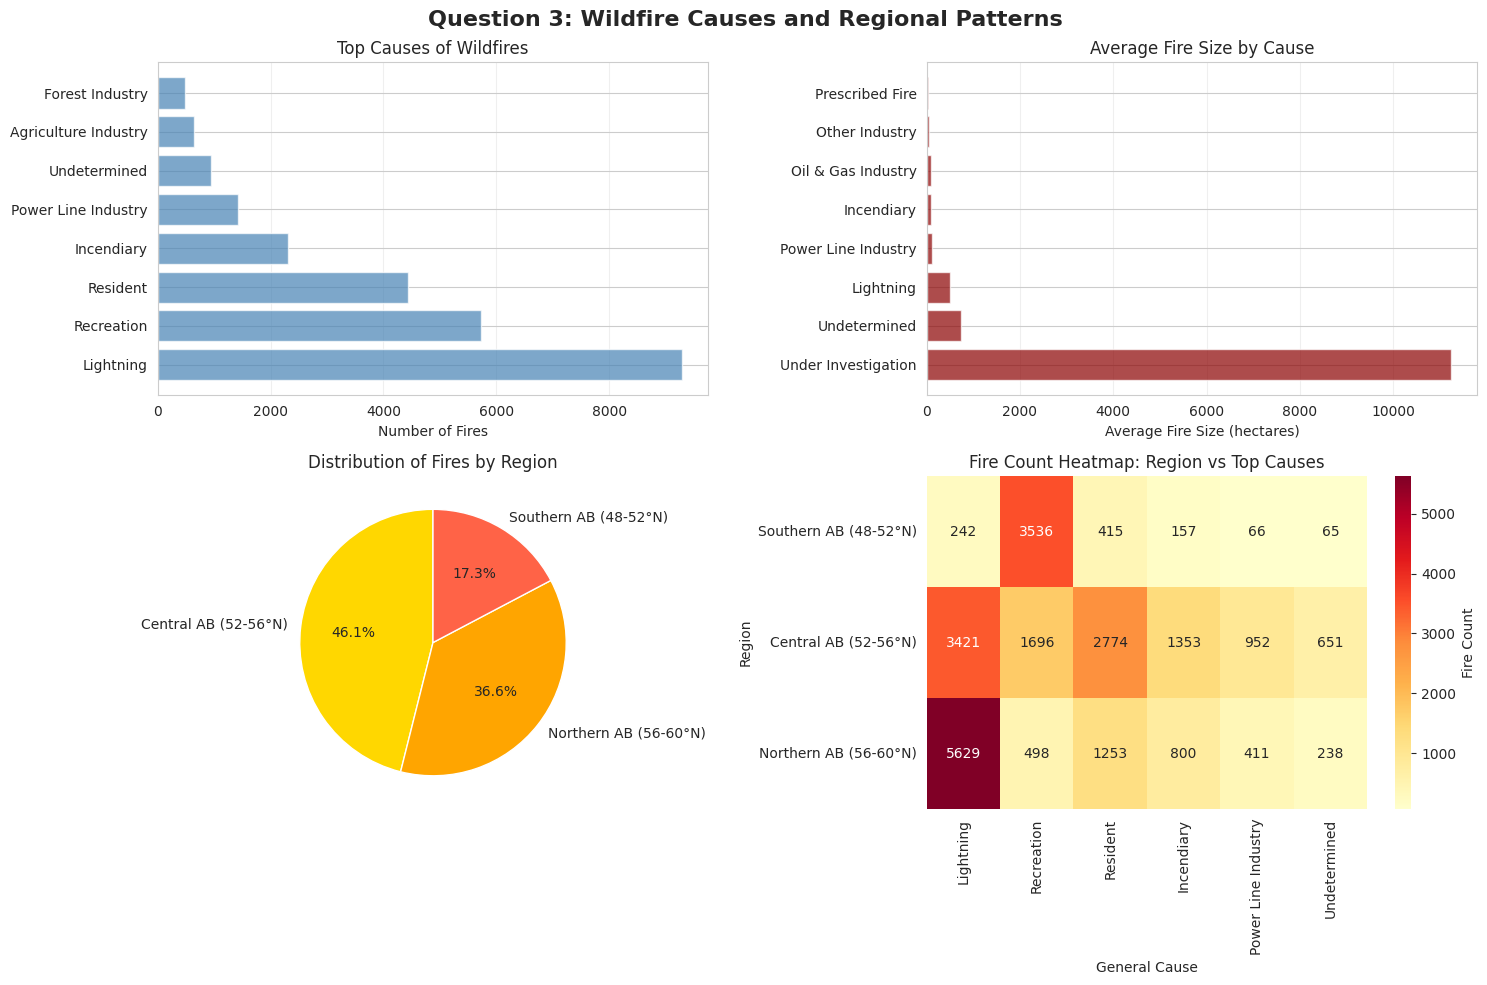

In [ ]:
# Visualization 2: Causes and regions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Question 3: Wildfire Causes and Regional Patterns',
             fontsize=16, fontweight='bold')

# Plot 1: Cause distribution
ax1 = axes[0, 0]
top_causes = cause_stats.head(8)
ax1.barh(top_causes.index, top_causes['Fire_Count'], alpha=0.7, color='steelblue')
ax1.set_xlabel('Number of Fires')
ax1.set_title('Top Causes of Wildfires')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Cause by severity
ax2 = axes[0, 1]
cause_size = df_clean.groupby('GENERAL_CAUSE')['CURRENT_SIZE'].mean().sort_values(ascending=False).head(8)
ax2.barh(cause_size.index, cause_size.values, alpha=0.7, color='darkred')
ax2.set_xlabel('Average Fire Size (hectares)')
ax2.set_title('Average Fire Size by Cause')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Regional distribution
ax3 = axes[1, 0]
region_counts = df_clean['REGION'].value_counts()
colors_region = ['#FFD700', '#FFA500', '#FF6347']
ax3.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%',
        colors=colors_region, startangle=90)
ax3.set_title('Distribution of Fires by Region')

# Plot 4: Heatmap of causes by region
ax4 = axes[1, 1]
top_causes_list = cause_stats.head(6).index
region_cause_subset = pd.crosstab(
    df_clean['REGION'],
    df_clean['GENERAL_CAUSE']
)[top_causes_list]
sns.heatmap(region_cause_subset, annot=True, fmt='d', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Fire Count'})
ax4.set_title('Fire Count Heatmap: Region vs Top Causes')
ax4.set_xlabel('General Cause')
ax4.set_ylabel('Region')

plt.tight_layout()
plt.savefig('q3_causes_regions.png', dpi=300, bbox_inches='tight')
plt.show()

<a name='section-7'></a>

# ⏱️ QUESTION 4: Response Effectiveness

## Research Question
**How effective is the fire response system? Does faster detection reduce fire size?**

### Why This Matters

If response time strongly predicts fire size, investments in detection technology and rapid response capacity are justified. If the relationship is weak, other factors (weather, fuel type, location) may matter more.

### Analytical Approach

**Methods:**
1. **Response Time Calculation** - Detection to initial attack
2. **Correlation Analysis** - Response time vs. final fire size
3. **Detection Method Comparison** - Air vs. satellite vs. public reports
4. **Confounding Analysis** - Account for location and weather effects

**Expected Confounders:**
- Remote fires: slower response AND more dangerous conditions
- Fast-growing fires: trigger faster response (reverse causation)

---


In [ ]:
# Calculate response metrics
response_metrics = df_clean[['DETECTION_TO_REPORT_HOURS', 'REPORT_TO_DISPATCH_HOURS']].describe()
print("\nResponse Time Statistics (hours):")
print(response_metrics)

df_response = df_clean[
    (df_clean['DETECTION_TO_REPORT_HOURS'].notna()) &
    (df_clean['DETECTION_TO_REPORT_HOURS'] >= 0) &
    (df_clean['DETECTION_TO_REPORT_HOURS'] < 48) &  # Filter extreme outliers
    (df_clean['CURRENT_SIZE'] > 0)
].copy()

# Categorize response time
df_response['RESPONSE_SPEED'] = pd.cut(
    df_response['DETECTION_TO_REPORT_HOURS'],
    bins=[0, 1, 4, 12, 48],
    labels=['Immediate (<1hr)', 'Fast (1-4hrs)', 'Moderate (4-12hrs)', 'Slow (12-48hrs)']
)

# Analyze relationship between response time and fire size


# Compare fire sizes by response speed
response_size = df_response.groupby('RESPONSE_SPEED')['CURRENT_SIZE'].agg(['count', 'mean', 'median', 'max'])
print("\nFire Size by Response Speed:")
print(response_size)



# Correlation analysis
valid_data = df_response[['DETECTION_TO_REPORT_HOURS', 'CURRENT_SIZE']].dropna()
corr_response, p_val_response = stats.pearsonr(
    valid_data['DETECTION_TO_REPORT_HOURS'],
    valid_data['CURRENT_SIZE']
)
print(f"\nCorrelation (Response Time vs Fire Size):")
print(f"  - Pearson r = {corr_response:.3f}")
print(f"  - p-value = {p_val_response:.4e}")


# Detection agent effectiveness
detection_stats = df_clean.groupby('DETECTION_AGENT_TYPE').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': 'mean',
    'DETECTION_TO_REPORT_HOURS': 'mean'
}).round(2)
detection_stats.columns = ['Fire_Count', 'Avg_Fire_Size', 'Avg_Response_Time']
detection_stats = detection_stats.sort_values('Fire_Count', ascending=False)
print("\nDetection Agent Performance:")
print(detection_stats.head(10))


Response Time Statistics (hours):
       DETECTION_TO_REPORT_HOURS  REPORT_TO_DISPATCH_HOURS
count               21142.000000              26539.000000
mean                    0.840890                  1.617742
std                    41.226278                 14.711565
min                     0.000000                  0.000000
25%                     0.000000                  0.000000
50%                     0.000000                  0.033333
75%                     0.033333                  0.133333
max                  5610.233333               1414.300000

Fire Size by Response Speed:
                    count        mean  median        max
RESPONSE_SPEED                                          
Immediate (<1hr)     9430  322.976187    0.10  334772.60
Fast (1-4hrs)          95  576.461474    0.01   54714.90
Moderate (4-12hrs)     46    0.219783    0.02       6.01
Slow (12-48hrs)       109   52.358624    0.02    4354.40

Correlation (Response Time vs Fire Size):
  - Pearson r = -0.

Visualization 3: Response Effectiveness

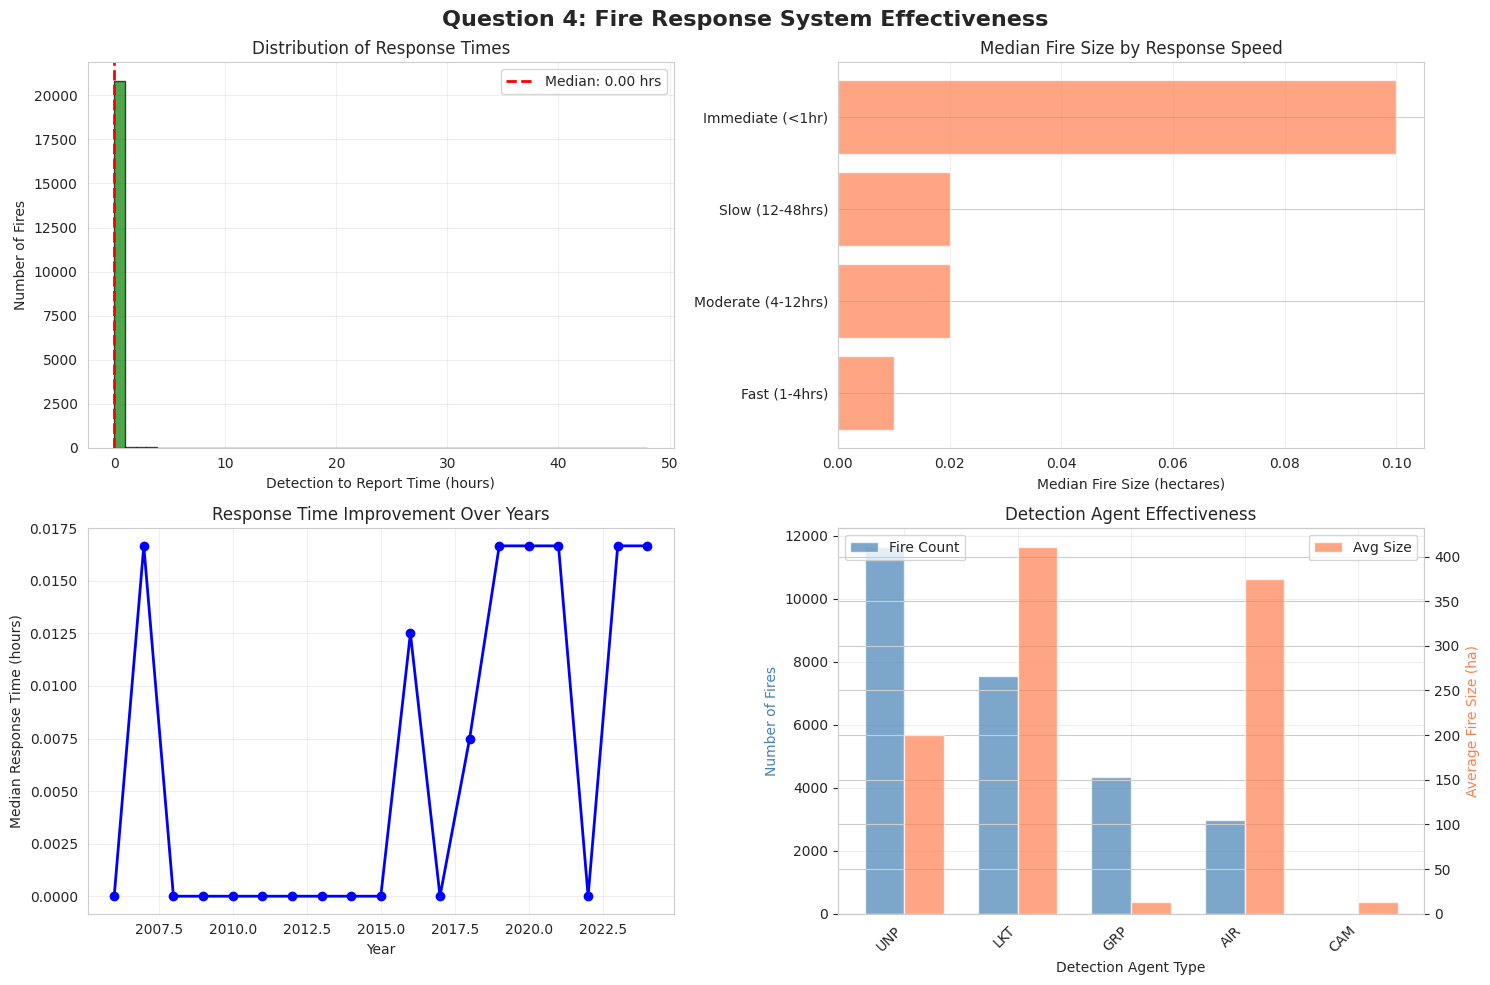

In [ ]:
# Visualization 4: Response effectiveness
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Question 4: Fire Response System Effectiveness',
             fontsize=16, fontweight='bold')

# Plot 1: Response time distribution
ax1 = axes[0, 0]
response_valid = df_clean['DETECTION_TO_REPORT_HOURS'].dropna()
response_valid = response_valid[(response_valid >= 0) & (response_valid <= 48)]
ax1.hist(response_valid, bins=50, alpha=0.7, color='green', edgecolor='black')
ax1.axvline(response_valid.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {response_valid.median():.2f} hrs')
ax1.set_xlabel('Detection to Report Time (hours)')
ax1.set_ylabel('Number of Fires')
ax1.set_title('Distribution of Response Times')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Fire size by response speed
ax2 = axes[0, 1]
response_size_data = df_response.groupby('RESPONSE_SPEED')['CURRENT_SIZE'].median().sort_values()
ax2.barh(range(len(response_size_data)), response_size_data.values, alpha=0.7, color='coral')
ax2.set_yticks(range(len(response_size_data)))
ax2.set_yticklabels(response_size_data.index)
ax2.set_xlabel('Median Fire Size (hectares)')
ax2.set_title('Median Fire Size by Response Speed')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Response time trends over years
ax3 = axes[1, 0]
yearly_response = df_clean.groupby('YEAR')['DETECTION_TO_REPORT_HOURS'].median()
ax3.plot(yearly_response.index, yearly_response.values, marker='o', linewidth=2, color='blue')
ax3.set_xlabel('Year')
ax3.set_ylabel('Median Response Time (hours)')
ax3.set_title('Response Time Improvement Over Years')
ax3.grid(True, alpha=0.3)

# Plot 4: Detection agent comparison
ax4 = axes[1, 1]
top_agents = detection_stats.head(6)
x = np.arange(len(top_agents))
width = 0.35
bars1 = ax4.bar(x - width/2, top_agents['Fire_Count'], width, label='Fire Count', alpha=0.7, color='steelblue')
ax4_2 = ax4.twinx()
bars2 = ax4_2.bar(x + width/2, top_agents['Avg_Fire_Size'], width, label='Avg Size', alpha=0.7, color='coral')
ax4.set_xlabel('Detection Agent Type')
ax4.set_ylabel('Number of Fires', color='steelblue')
ax4_2.set_ylabel('Average Fire Size (ha)', color='coral')
ax4.set_title('Detection Agent Effectiveness')
ax4.set_xticks(x)
ax4.set_xticklabels(top_agents.index, rotation=45, ha='right')
ax4.legend(loc='upper left')
ax4_2.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q4_response_effectiveness.png', dpi=300, bbox_inches='tight')
plt.show()

<a name='section-8'></a>

# 🌡️ QUESTION 5: Environmental Factors

## Research Question
**What environmental factors correlate with fire size and spread?**

### Why This Matters

Understanding weather-fire relationships enables:
- Fire danger rating systems
- Risk prediction for new fires
- Resource pre-positioning based on forecasts
- Climate adaptation planning

### Analytical Approach

**Methods:**
1. **Correlation Matrix** - Relationships among environmental variables
2. **Scatter Analysis** - Temperature, humidity, wind vs. fire size
3. **Fuel Type Comparison** - Fire behavior by vegetation type
4. **Composite Indices** - Fire Weather Index construction

**Variables Analyzed:**
- Temperature (°C)
- Relative Humidity (%)
- Wind Speed (km/h)
- Fuel Type (categorical)

---


In [ ]:
# Create analysis dataset with environmental variables
env_data = df_clean[[
    'CURRENT_SIZE', 'TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED',
    'FUEL_TYPE', 'FIRE_SPREAD_RATE', 'WEATHER_CONDITIONS_OVER_FIRE'
]].copy()

# Basic statistics
print("\nEnvironmental Variables - Data Availability:")
print(f"  - Temperature: {env_data['TEMPERATURE'].notna().sum():,} records ({env_data['TEMPERATURE'].notna().sum()/len(env_data)*100:.1f}%)")
print(f"  - Humidity: {env_data['RELATIVE_HUMIDITY'].notna().sum():,} records ({env_data['RELATIVE_HUMIDITY'].notna().sum()/len(env_data)*100:.1f}%)")
print(f"  - Wind Speed: {env_data['WIND_SPEED'].notna().sum():,} records ({env_data['WIND_SPEED'].notna().sum()/len(env_data)*100:.1f}%)")
print(f"  - Fuel Type: {env_data['FUEL_TYPE'].notna().sum():,} records ({env_data['FUEL_TYPE'].notna().sum()/len(env_data)*100:.1f}%)")


# Correlation analysis for complete cases
env_complete = env_data[['CURRENT_SIZE', 'TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED']].dropna()
env_complete = env_complete[env_complete['CURRENT_SIZE'] > 0]  # Remove zero-size fires

print(f"\nComplete cases for correlation analysis: {len(env_complete):,}")

if len(env_complete) > 100:
    correlation_matrix = env_complete.corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)

    # Individual correlations with fire size
    print("\nCorrelations with Fire Size:")
    for var in ['TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED']:
        corr, p_val = stats.pearsonr(env_complete['CURRENT_SIZE'], env_complete[var])
        print(f"  - {var}: r={corr:.3f}, p={p_val:.4e}")


# Fuel type analysis
fuel_stats = df_clean.groupby('FUEL_TYPE').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': ['mean', 'median', 'max'],
    'FIRE_SPREAD_RATE': 'mean'
}).round(2)
fuel_stats.columns = ['Count', 'Mean_Size', 'Median_Size', 'Max_Size', 'Avg_Spread_Rate']
fuel_stats = fuel_stats[fuel_stats['Count'] > 50].sort_values('Mean_Size', ascending=False)

print("\nFuel Type Analysis (types with >50 fires):")
print(fuel_stats.head(10))



# Weather conditions analysis
weather_stats = df_clean.groupby('WEATHER_CONDITIONS_OVER_FIRE').agg({
    'FIRE_NUMBER': 'count',
    'CURRENT_SIZE': 'mean'
}).round(2)
weather_stats.columns = ['Count', 'Mean_Size']
weather_stats = weather_stats[weather_stats['Count'] > 20].sort_values('Mean_Size', ascending=False)

print("\nWeather Conditions Analysis:")
print(weather_stats.head(10))


Environmental Variables - Data Availability:
  - Temperature: 23,679 records (89.2%)
  - Humidity: 23,673 records (89.2%)
  - Wind Speed: 23,671 records (89.2%)
  - Fuel Type: 18,992 records (71.5%)

Complete cases for correlation analysis: 23,668

Correlation Matrix:
                   CURRENT_SIZE  TEMPERATURE  RELATIVE_HUMIDITY  WIND_SPEED
CURRENT_SIZE           1.000000     0.030064          -0.029565    0.050619
TEMPERATURE            0.030064     1.000000          -0.282871   -0.017780
RELATIVE_HUMIDITY     -0.029565    -0.282871           1.000000   -0.175826
WIND_SPEED             0.050619    -0.017780          -0.175826    1.000000

Correlations with Fire Size:
  - TEMPERATURE: r=0.030, p=3.7284e-06
  - RELATIVE_HUMIDITY: r=-0.030, p=5.3875e-06
  - WIND_SPEED: r=0.051, p=6.5933e-15

Fuel Type Analysis (types with >50 fires):
           Count  Mean_Size  Median_Size  Max_Size  Avg_Spread_Rate
FUEL_TYPE                                                          
C4           146 

Visualization 4: Environmental Factors

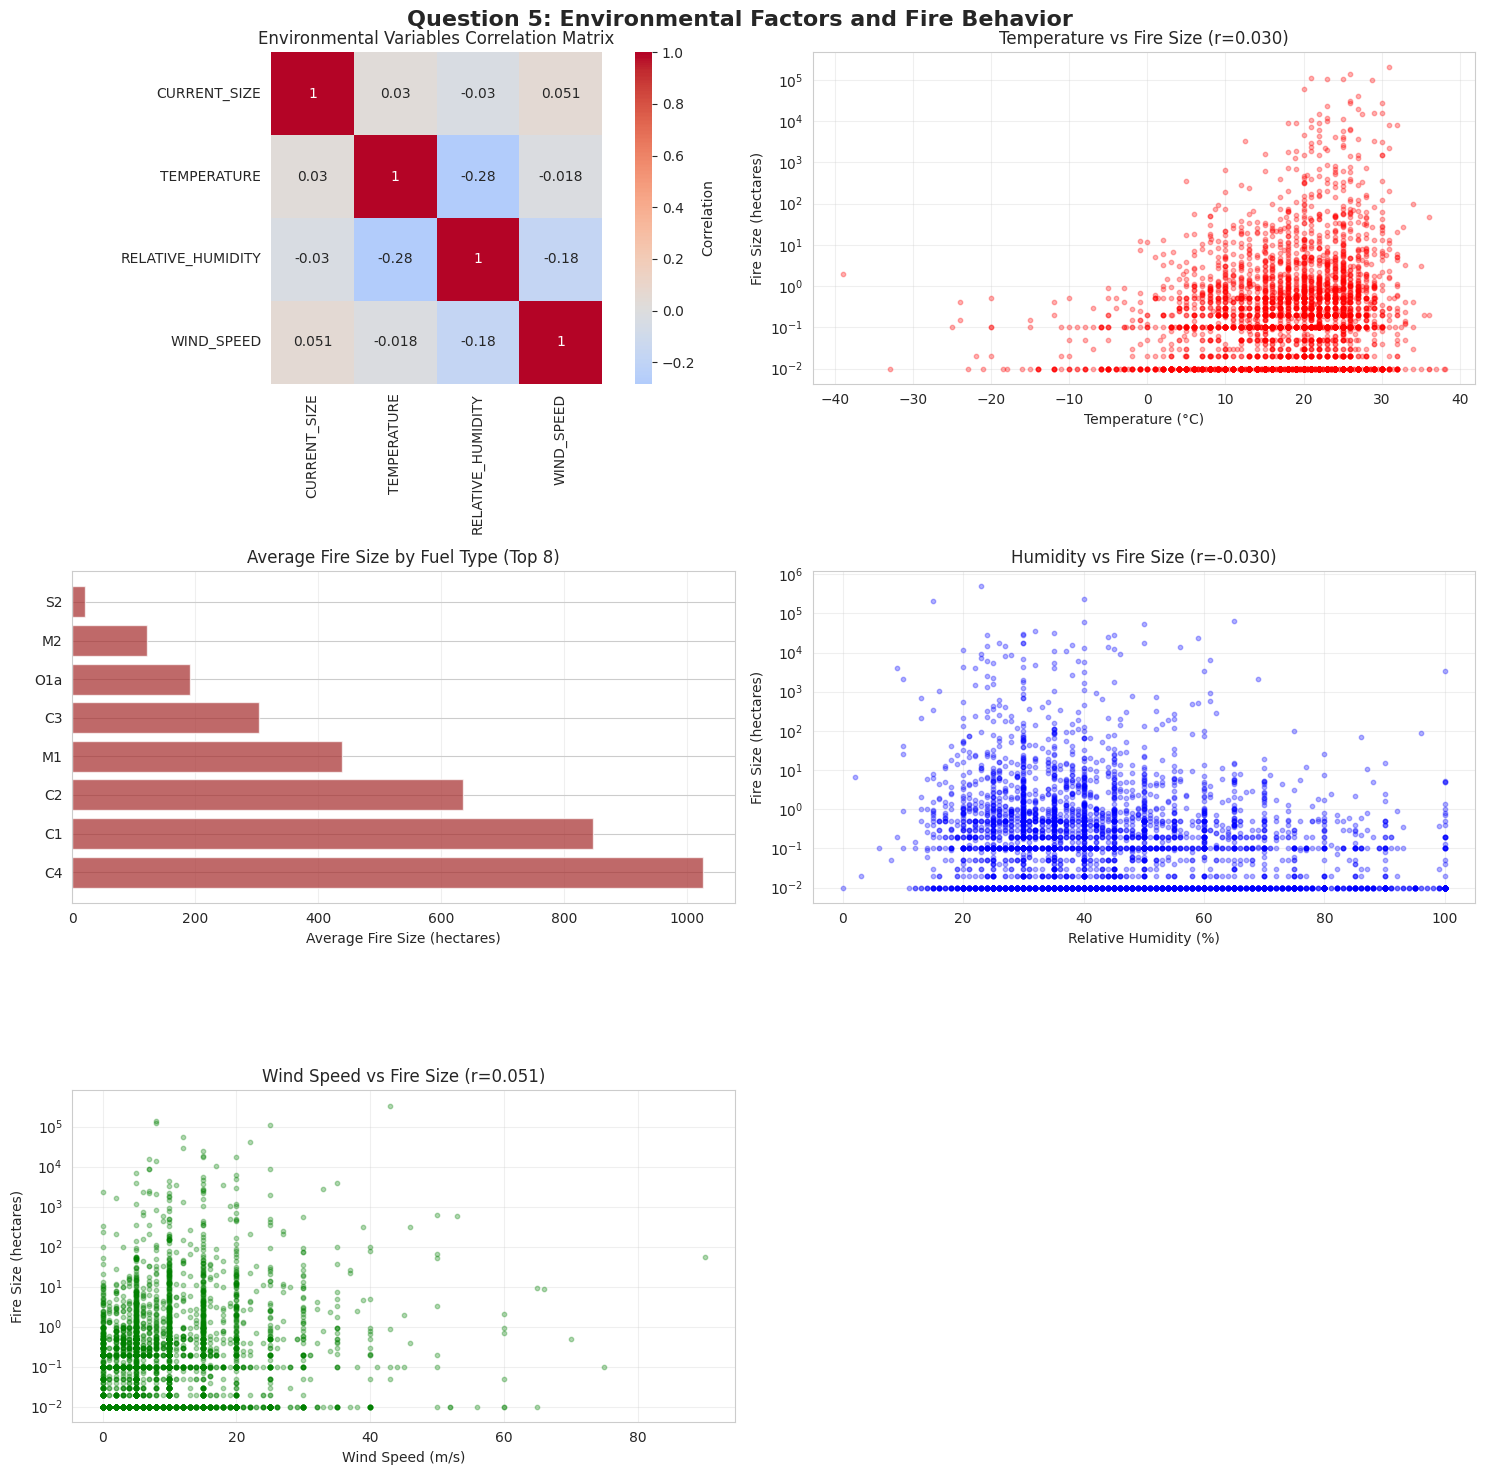

In [ ]:
# Visualization 5: Environmental factors
fig, axes = plt.subplots(3, 2, figsize=(15, 15)) # Changed to 3 rows, 2 columns
fig.suptitle('Question 5: Environmental Factors and Fire Behavior',
             fontsize=16, fontweight='bold')

# Flatten the axes array for easier indexing if needed, or use direct indexing
# axes = axes.flatten()

# Plot 1: Correlation heatmap
if len(env_complete) > 100:
    ax1 = axes[0, 0]
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, ax=ax1, cbar_kws={'label': 'Correlation'})
    ax1.set_title('Environmental Variables Correlation Matrix')

# Plot 2: Temperature vs Fire Size
ax2 = axes[0, 1]
if len(env_complete) > 100:
    sample_data = env_complete.sample(min(5000, len(env_complete)))
    ax2.scatter(sample_data['TEMPERATURE'], sample_data['CURRENT_SIZE'],
                alpha=0.3, s=10, color='red')
    ax2.set_xlabel('Temperature (°C)')
    ax2.set_ylabel('Fire Size (hectares)')
    ax2.set_title(f'Temperature vs Fire Size (r={correlation_matrix.loc["CURRENT_SIZE", "TEMPERATURE"]:.3f})')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

# Plot 3: Fuel type comparison
ax3 = axes[1, 0] # Moved to a unique subplot
top_fuels = fuel_stats.head(8)
ax3.barh(top_fuels.index, top_fuels['Mean_Size'], alpha=0.7, color='brown')
ax3.set_xlabel('Average Fire Size (hectares)')
ax3.set_title('Average Fire Size by Fuel Type (Top 8)')
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Humidity vs Fire Size
ax4 = axes[1, 1] # Moved to a unique subplot
if len(env_complete) > 100:
    sample_data = env_complete.sample(min(5000, len(env_complete)))
    ax4.scatter(sample_data['RELATIVE_HUMIDITY'], sample_data['CURRENT_SIZE'],
                alpha=0.3, s=10, color='blue')
    ax4.set_xlabel('Relative Humidity (%)')
    ax4.set_ylabel('Fire Size (hectares)')
    ax4.set_title(f'Humidity vs Fire Size (r={correlation_matrix.loc["CURRENT_SIZE", "RELATIVE_HUMIDITY"]:.3f})')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3)

# Plot 5: Wind Speed vs Fire Size
ax5 = axes[2, 0] # Moved to a unique subplot
if len(env_complete) > 100:
    sample_data = env_complete.sample(min(5000, len(env_complete)))
    ax5.scatter(sample_data['WIND_SPEED'], sample_data['CURRENT_SIZE'],
                alpha=0.3, s=10, color='green')
    ax5.set_xlabel('Wind Speed (m/s)')
    ax5.set_ylabel('Fire Size (hectares)')
    ax5.set_title(f'Wind Speed vs Fire Size (r={correlation_matrix.loc["CURRENT_SIZE", "WIND_SPEED"]:.3f})')
    ax5.set_yscale('log')
    ax5.grid(True, alpha=0.3)

# Hide the empty subplot (axes[2,1])
fig.delaxes(axes[2,1])

plt.tight_layout()
plt.savefig('q5_environmental_factors.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Check if we have enough data
if len(env_complete) > 100:

    # ========================================================================
    # CHART 1: Correlation Heatmap
    # ========================================================================
    print("\n1. Creating correlation heatmap...")
    fig1, ax1 = plt.subplots(figsize=(10, 8))

    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, ax=ax1, cbar_kws={'label': 'Correlation'},
                annot_kws={'fontsize': 10}, linewidths=0.5, linecolor='gray')

    ax1.set_title('Environmental Variables Correlation Matrix',
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('')
    ax1.set_ylabel('')

    # Rotate labels for better readability
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.savefig('q5_chart1_correlation_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("    Saved: q5_chart1_correlation_matrix.png")

    # ========================================================================
    # CHART 2: Temperature vs Fire Size
    # ========================================================================
    print("\n2. Creating temperature scatter plot...")
    fig2, ax2 = plt.subplots(figsize=(10, 8))

    sample_data = env_complete.sample(min(5000, len(env_complete)), random_state=42)

    scatter2 = ax2.scatter(
        sample_data['TEMPERATURE'],
        sample_data['CURRENT_SIZE'],
        alpha=0.4,
        s=20,
        color='red',
        edgecolors='darkred',
        linewidth=0.3
    )

    ax2.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Fire Size (hectares)', fontsize=12, fontweight='bold')

    # Get correlation value
    temp_corr = correlation_matrix.loc["CURRENT_SIZE", "TEMPERATURE"]
    ax2.set_title(f'Temperature vs Fire Size\nPearson r = {temp_corr:.3f}',
                  fontsize=14, fontweight='bold', pad=15)

    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, linestyle='--')

    # Add trend line
    from scipy.stats import linregress
    valid_temp = sample_data[['TEMPERATURE', 'CURRENT_SIZE']].dropna()
    if len(valid_temp) > 10:
        slope, intercept, r_value, p_value, std_err = linregress(
            valid_temp['TEMPERATURE'],
            np.log10(valid_temp['CURRENT_SIZE'])
        )
        x_trend = np.linspace(valid_temp['TEMPERATURE'].min(),
                              valid_temp['TEMPERATURE'].max(), 100)
        y_trend = 10 ** (slope * x_trend + intercept)
        ax2.plot(x_trend, y_trend, 'b--', linewidth=2.5, alpha=0.7,
                label=f'Trend line (p={p_value:.3e})')
        ax2.legend(fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.savefig('q5_chart2_temperature_vs_size.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("    Saved: q5_chart2_temperature_vs_size.png")

    # ========================================================================
    # CHART 3: Humidity vs Fire Size
    # ========================================================================
    print("\n3. Creating humidity scatter plot...")
    fig3, ax3 = plt.subplots(figsize=(10, 8))

    sample_data = env_complete.sample(min(5000, len(env_complete)), random_state=42)

    scatter3 = ax3.scatter(
        sample_data['RELATIVE_HUMIDITY'],
        sample_data['CURRENT_SIZE'],
        alpha=0.4,
        s=20,
        color='blue',
        edgecolors='darkblue',
        linewidth=0.3
    )

    ax3.set_xlabel('Relative Humidity (%)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Fire Size (hectares)', fontsize=12, fontweight='bold')

    # Get correlation value
    humidity_corr = correlation_matrix.loc["CURRENT_SIZE", "RELATIVE_HUMIDITY"]
    ax3.set_title(f'Relative Humidity vs Fire Size\nPearson r = {humidity_corr:.3f}',
                  fontsize=14, fontweight='bold', pad=15)

    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3, linestyle='--')

    # Add trend line
    valid_hum = sample_data[['RELATIVE_HUMIDITY', 'CURRENT_SIZE']].dropna()
    if len(valid_hum) > 10:
        slope, intercept, r_value, p_value, std_err = linregress(
            valid_hum['RELATIVE_HUMIDITY'],
            np.log10(valid_hum['CURRENT_SIZE'])
        )
        x_trend = np.linspace(valid_hum['RELATIVE_HUMIDITY'].min(),
                              valid_hum['RELATIVE_HUMIDITY'].max(), 100)
        y_trend = 10 ** (slope * x_trend + intercept)
        ax3.plot(x_trend, y_trend, 'r--', linewidth=2.5, alpha=0.7,
                label=f'Trend line (p={p_value:.3e})')
        ax3.legend(fontsize=10, loc='upper right')

    plt.tight_layout()
    plt.savefig('q5_chart3_humidity_vs_size.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("    Saved: q5_chart3_humidity_vs_size.png")

    # ========================================================================
    # CHART 4: Wind Speed vs Fire Size
    # ========================================================================
    print("\n4. Creating wind speed scatter plot...")
    fig4, ax4 = plt.subplots(figsize=(10, 8))

    sample_data = env_complete.sample(min(5000, len(env_complete)), random_state=42)

    scatter4 = ax4.scatter(
        sample_data['WIND_SPEED'],
        sample_data['CURRENT_SIZE'],
        alpha=0.4,
        s=20,
        color='green',
        edgecolors='darkgreen',
        linewidth=0.3
    )

    ax4.set_xlabel('Wind Speed (km/h)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Fire Size (hectares)', fontsize=12, fontweight='bold')

    # Get correlation value
    wind_corr = correlation_matrix.loc["CURRENT_SIZE", "WIND_SPEED"]
    ax4.set_title(f'Wind Speed vs Fire Size\nPearson r = {wind_corr:.3f}',
                  fontsize=14, fontweight='bold', pad=15)

    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3, linestyle='--')

    # Add trend line
    valid_wind = sample_data[['WIND_SPEED', 'CURRENT_SIZE']].dropna()
    if len(valid_wind) > 10:
        slope, intercept, r_value, p_value, std_err = linregress(
            valid_wind['WIND_SPEED'],
            np.log10(valid_wind['CURRENT_SIZE'])
        )
        x_trend = np.linspace(valid_wind['WIND_SPEED'].min(),
                              valid_wind['WIND_SPEED'].max(), 100)
        y_trend = 10 ** (slope * x_trend + intercept)
        ax4.plot(x_trend, y_trend, 'orange', linestyle='--', linewidth=2.5, alpha=0.7,
                label=f'Trend line (p={p_value:.3e})')
        ax4.legend(fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.savefig('q5_chart4_wind_vs_size.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("    Saved: q5_chart4_wind_vs_size.png")

else:
    print(f" Insufficient data for environmental analysis (n={len(env_complete)})")
    print("  Need at least 100 records with complete environmental data")

# ========================================================================
# CHART 5: Fuel Type Comparison (doesn't require env_complete)
# ========================================================================
print("\n5. Creating fuel type comparison...")
fig5, ax5 = plt.subplots(figsize=(12, 8))

top_fuels = fuel_stats.head(10)  # Show top 10 instead of 8 for more detail

# Create color gradient
colors_fuel = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_fuels)))

bars = ax5.barh(range(len(top_fuels)), top_fuels['Mean_Size'],
                alpha=0.8, color=colors_fuel, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_fuels['Mean_Size'])):
    width = bar.get_width()
    ax5.text(width + max(top_fuels['Mean_Size']) * 0.02,
             bar.get_y() + bar.get_height()/2.,
             f'{val:.1f} ha',
             ha='left', va='center', fontsize=9, fontweight='bold')

ax5.set_yticks(range(len(top_fuels)))
ax5.set_yticklabels(top_fuels.index, fontsize=10)
ax5.set_xlabel('Average Fire Size (hectares)', fontsize=12, fontweight='bold')
ax5.set_title('Average Fire Size by Fuel Type (Top 10)',
              fontsize=14, fontweight='bold', pad=15)
ax5.grid(True, alpha=0.3, axis='x', linestyle='--')

# Add count information
ax5_twin = ax5.twiny()
ax5_twin.set_xlim(ax5.get_xlim())
ax5_twin.set_xlabel(f'Sample sizes: {top_fuels["Count"].min():.0f} - {top_fuels["Count"].max():.0f} fires',
                    fontsize=10, style='italic', color='gray')
ax5_twin.set_xticks([])

plt.tight_layout()
plt.savefig('q5_chart5_fuel_type_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("    Saved: q5_chart5_fuel_type_comparison.png")

# ========================================================================
# SUMMARY
# ========================================================================
print("\n" + "="*80)
print("ENVIRONMENTAL FACTOR CHARTS COMPLETE")
print("="*80)
print("\nGenerated individual chart files:")
print("  1. q5_chart1_correlation_matrix.png - Correlation heatmap")
print("  2. q5_chart2_temperature_vs_size.png - Temperature scatter plot with trend")
print("  3. q5_chart3_humidity_vs_size.png - Humidity scatter plot with trend")
print("  4. q5_chart4_wind_vs_size.png - Wind speed scatter plot with trend")
print("  5. q5_chart5_fuel_type_comparison.png - Fuel type bar chart")
print("\nChart specifications:")
print("  - Size: 10\" × 8\" (scatter plots), 12\" × 8\" (fuel type)")
print("  - Resolution: 300 DPI")
print("  - Format: PNG with white background")
print("  - Features: Trend lines, correlation values, value labels")
print("  - All charts saved individually - no overlap!")


1. Creating correlation heatmap...
    Saved: q5_chart1_correlation_matrix.png

2. Creating temperature scatter plot...
    Saved: q5_chart2_temperature_vs_size.png

3. Creating humidity scatter plot...
    Saved: q5_chart3_humidity_vs_size.png

4. Creating wind speed scatter plot...
    Saved: q5_chart4_wind_vs_size.png

5. Creating fuel type comparison...
    Saved: q5_chart5_fuel_type_comparison.png

ENVIRONMENTAL FACTOR CHARTS COMPLETE

Generated individual chart files:
  1. q5_chart1_correlation_matrix.png - Correlation heatmap
  2. q5_chart2_temperature_vs_size.png - Temperature scatter plot with trend
  3. q5_chart3_humidity_vs_size.png - Humidity scatter plot with trend
  4. q5_chart4_wind_vs_size.png - Wind speed scatter plot with trend
  5. q5_chart5_fuel_type_comparison.png - Fuel type bar chart

Chart specifications:
  - Size: 10" × 8" (scatter plots), 12" × 8" (fuel type)
  - Resolution: 300 DPI
  - Format: PNG with white background
  - Features: Trend lines, correlation 

<a name='section-9'></a>

# 🤖 QUESTION 6: Machine Learning Prediction

## Research Question
**Can we predict fire size categories using clustering and classification?**

### Why This Matters

**Operational Question:** When 20 fires ignite simultaneously, which require immediate aggressive suppression vs. monitoring?

Traditional analysis shows individual correlations. Machine learning reveals patterns across ALL variables simultaneously, potentially enabling better operational predictions.

### Analytical Approach

**Method 1: K-Means Clustering (Unsupervised)**
- Discover natural fire behavior types
- No labels needed
- Reveals structure we might not hypothesize
- Output: Distinct fire behavior clusters

**Method 2: Random Forest Classification (Supervised)**
- Predict fire size category from conditions
- Learn from labeled examples
- 70/30 train/test split
- Output: Probability fire will be "large" (>10 ha)

**Validation:**
- Silhouette score for cluster quality
- Confusion matrix for classification
- Precision, recall, F1-score

---


In [ ]:
# SELECT CLUSTERING VARIABLES FOR MODELING

cluster_vars = [
    "FIRE_SPREAD_RATE",
    "TEMPERATURE",
    "RELATIVE_HUMIDITY",
    "WIND_SPEED"
]


# PIPELINE PREPROCESSING

df.columns = [c.strip() for c in df.columns]

# Convert numeric safely
for col in cluster_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_cluster = df[cluster_vars].dropna()

# STANDARDIZE FEATURES FOR CLUSTERING (Impute (safety) + Scale)
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X = imputer.fit_transform(df_cluster)
X_scaled = scaler.fit_transform(X)

# PERFORM KMeans CLUSTERING
optimal_k=4
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10,
    max_iter=200
)

clusters = kmeans.fit_predict(X_scaled)

df_cluster["CLUSTER"] = clusters

# ATTACH CLUSTERS BACK TO FULL DATASET
df.loc[df_cluster.index, "CLUSTER"] = df_cluster["CLUSTER"]


# SILHOUETTE SCORE TO JUSTIFY K=4
from sklearn.metrics import silhouette_score

# Use a sample for speed (recommended)
n = X_scaled.shape[0]
sample_n = min(8000, n)  # 5k–10k is usually enough for justification
rng = np.random.RandomState(42)
idx = rng.choice(n, size=sample_n, replace=False)

sil = silhouette_score(X_scaled[idx], clusters[idx], metric="euclidean")

print(f"Silhouette score (k=4), sampled n={sample_n}: {sil:.4f}")

Silhouette score (k=4), sampled n=8000: 0.2867


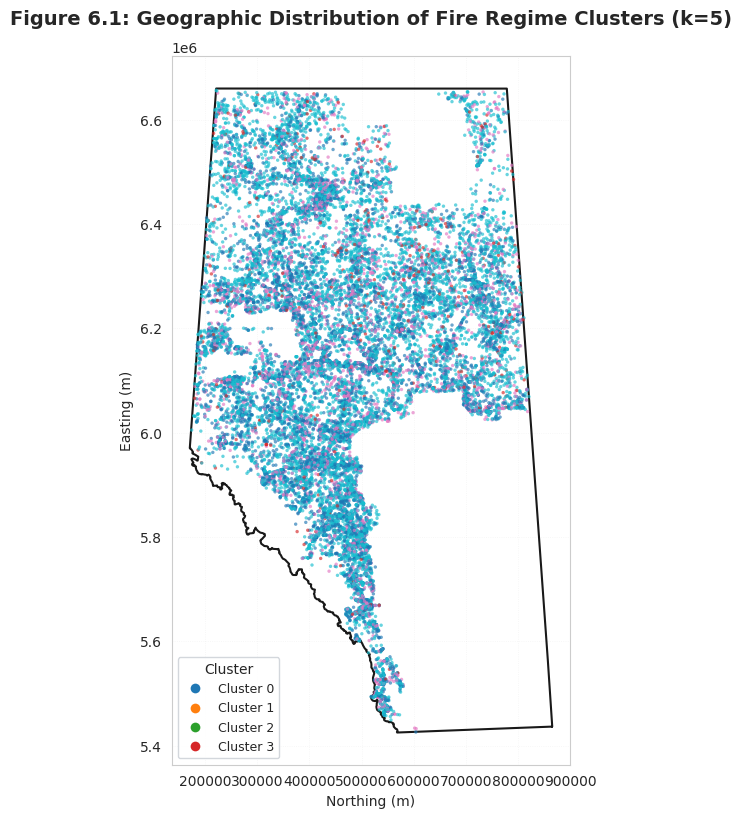

In [ ]:
# SPATIAL CLUSTER MAP (Alberta 10TM AEP Forest)
RS_TARGET = "ESRI:102184"  # Alberta 10TM AEP Forest
tf = Transformer.from_crs("EPSG:4326", CRS_TARGET, always_xy=True)

# Use rows that have cluster labels + coordinates
dmap = df.dropna(subset=["CLUSTER", "LONGITUDE", "LATITUDE"]).copy()

lon = pd.to_numeric(dmap["LONGITUDE"], errors="coerce").values
lat = pd.to_numeric(dmap["LATITUDE"], errors="coerce").values
m = np.isfinite(lon) & np.isfinite(lat)

x, y = tf.transform(lon[m], lat[m])
c = dmap.loc[dmap.index[m], "CLUSTER"].astype(int).values

# VISUALIZATION PLOT
fig, ax = plt.subplots(figsize=(10.8, 9.2), facecolor="white")
ax.set_facecolor("white")

# Alberta boundary (optional)
try:
    ax.plot(abx, aby, color="black", linewidth=1.5, alpha=0.9, zorder=2)
except NameError:
    pass

# Cluster scatter
sc = ax.scatter(
    x, y,
    c=c,
    cmap="tab10",
    s=6,
    alpha=0.65,
    linewidths=0,
    zorder=3
)

ax.set_title("Figure 6.1: Geographic Distribution of Fire Regime Clusters (k=5)", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Northing (m)")
ax.set_ylabel("Easting (m)")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.20)

# Clean legend (one entry per cluster)
cluster_ids = sorted(np.unique(c))
handles = [
    mpl.lines.Line2D([0],[0], marker='o', linestyle='',
                     markerfacecolor=plt.cm.tab10(i),
                     markeredgecolor='none',
                     markersize=7,
                     label=f"Cluster {i}")
    for i in cluster_ids
]
ax.legend(handles=handles, title="Cluster", loc="lower left",
          frameon=True, framealpha=0.95, facecolor="white", edgecolor="#d1d5db",
          fontsize=9, title_fontsize=10)

plt.savefig("q6_cluster_map_geographic.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

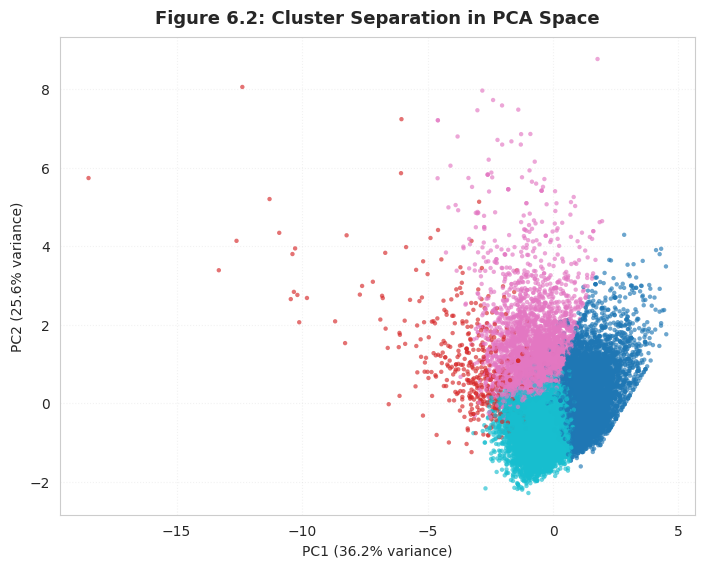

PCA variance captured: PC1=36.2%, PC2=25.6%, total=61.7%


In [ ]:
# PCA separation plot (PC1/PC2 + variance %)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pc1 = pca.explained_variance_ratio_[0] * 100
pc2 = pca.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(8.2, 6.2), facecolor="white")
ax.set_facecolor("white")

ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    s=10,
    alpha=0.65,
    linewidths=0
)

ax.set_title("Figure 6.2: Cluster Separation in PCA Space", fontsize=13, weight="bold", pad=10)
ax.set_xlabel(f"PC1 ({pc1:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pc2:.1f}% variance)")
ax.grid(True, linestyle=":", alpha=0.25)

plt.savefig("q6_cluster_pca_space.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"PCA variance captured: PC1={pc1:.1f}%, PC2={pc2:.1f}%, total={pc1+pc2:.1f}%")

,FIRE_SPREAD_RATE,TEMPERATURE,RELATIVE_HUMIDITY,WIND_SPEED,n
CLUSTER,,,,,
0,0.317068,11.607446,65.911520,5.436122,6849
1,14.240343,22.776609,34.991416,14.203863,466
2,0.965694,16.988400,37.571358,22.217413,4043
3,0.712215,21.479253,36.798552,6.172332,12296


Saved: q6_cluster_profiles_table.csv


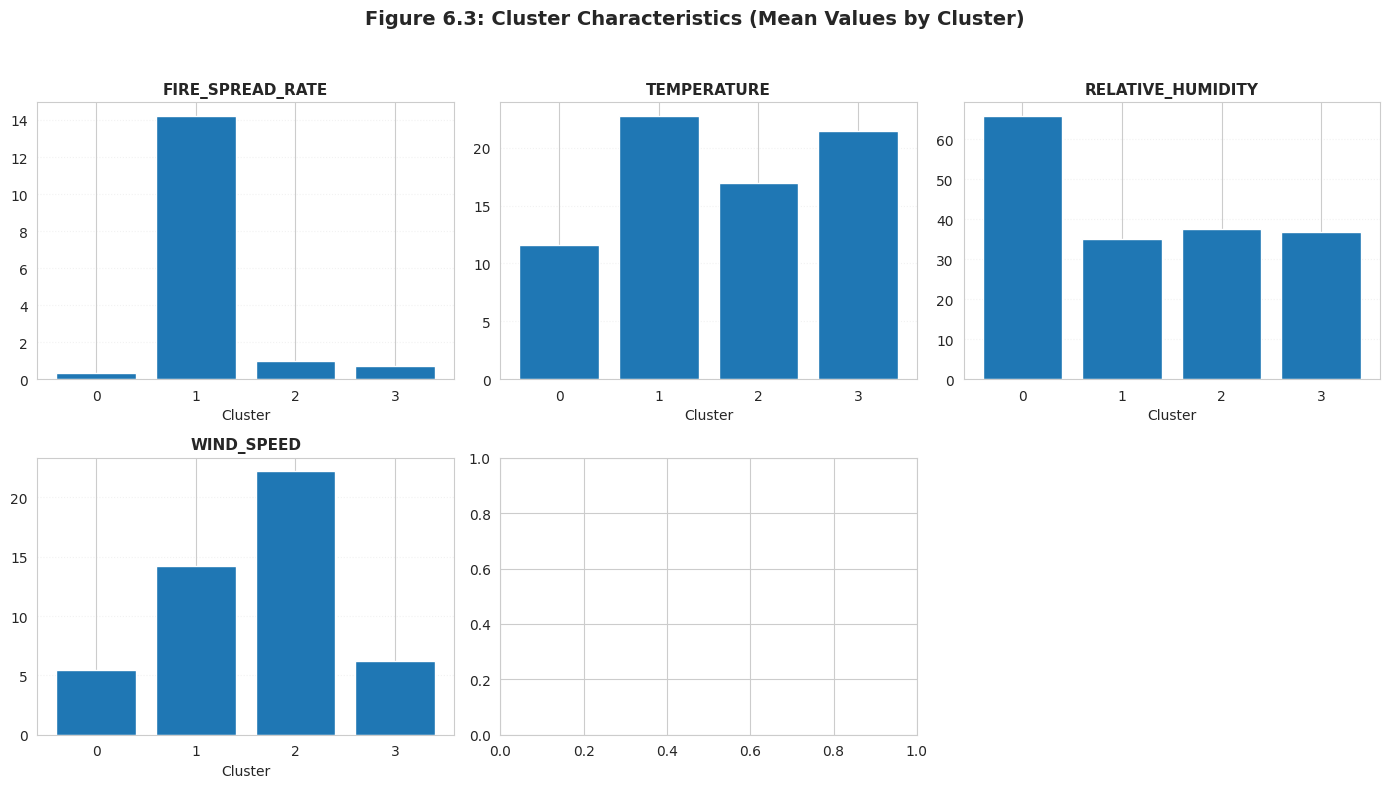

In [ ]:
# Cluster profile summary (table + characteristics figure)
# Profile table (means + counts)

features_used = ["FIRE_SPREAD_RATE", "TEMPERATURE", "RELATIVE_HUMIDITY", "WIND_SPEED"]

df_profiles = df_cluster.copy()
df_profiles["CLUSTER"] = clusters

profile_mean = df_profiles.groupby("CLUSTER")[features_used].mean()
profile_std  = df_profiles.groupby("CLUSTER")[features_used].std()
profile_n    = df_profiles.groupby("CLUSTER").size().rename("n")

profile_table = profile_mean.join(profile_n)
display(profile_table)

profile_table.to_csv("q6_cluster_profiles_table.csv")
print("Saved: q6_cluster_profiles_table.csv")


# Characteristics figure (small multiples bar charts)

means = profile_mean.copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 8), facecolor="white")
axes = axes.flatten()

for i, var in enumerate(features_used):
    ax = axes[i]
    ax.bar(means.index.astype(str), means[var].values)
    ax.set_title(var, fontsize=11, weight="bold")
    ax.set_xlabel("Cluster")
    ax.grid(True, axis="y", linestyle=":", alpha=0.25)

# Turn off the last unused subplot (since 5 vars in a 2x3 grid)
axes[-1].axis("off")

plt.suptitle("Figure 6.3: Cluster Characteristics (Mean Values by Cluster)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("q6_cluster_characteristics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

,FIRE_SPREAD_RATE,TEMPERATURE,RELATIVE_HUMIDITY,WIND_SPEED,n
CLUSTER,,,,,
0,-0.226991,-0.808751,1.099995,-0.407169,6849
1,5.124547,0.631608,-0.552127,0.635539,466
2,0.022314,-0.114831,-0.414275,1.588555,4043
3,-0.075113,0.464303,-0.455568,-0.319615,12296


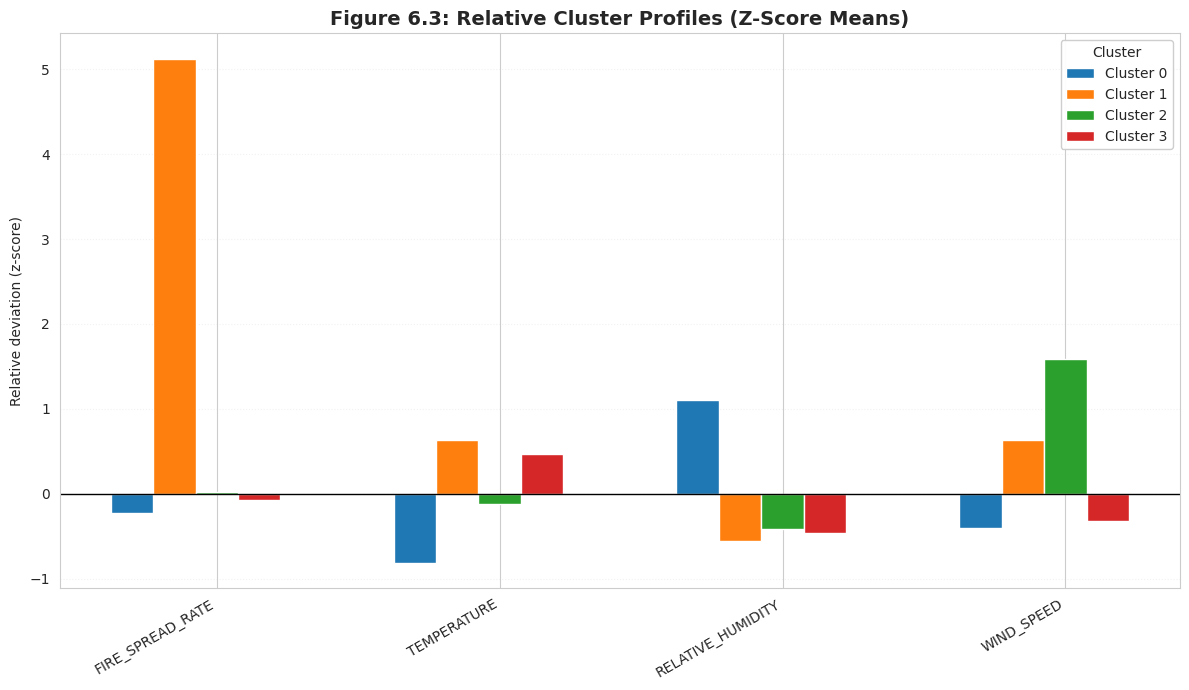

Saved: q6_cluster_characteristics.png


In [ ]:
# Compute Z-Score Profiles Per Cluster
#- 0 → average wildfire
#- +1 → one standard deviation above average
#- −1 → one standard deviation below average



# Convert scaled matrix to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_vars)
X_scaled_df["CLUSTER"] = clusters

# Compute mean z-score per cluster
z_profiles = X_scaled_df.groupby("CLUSTER")[cluster_vars].mean()

# Add counts
cluster_sizes = X_scaled_df.groupby("CLUSTER").size().rename("n")
z_profiles = z_profiles.join(cluster_sizes)

display(z_profiles)
z_profiles.to_csv("q6_cluster_profiles_zscores.csv")


# VISUALIZE RELATIVE PROFILES

features = cluster_vars

fig, ax = plt.subplots(figsize=(12, 7), facecolor="white")

x = np.arange(len(features))
width = 0.15

for i, cluster_id in enumerate(z_profiles.index):
    ax.bar(
        x + i * width,
        z_profiles.loc[cluster_id, features],
        width=width,
        label=f"Cluster {cluster_id}"
    )

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x + width*2)
ax.set_xticklabels(features, rotation=30, ha="right")
ax.set_ylabel("Relative deviation (z-score)")
ax.set_title("Figure 6.3: Relative Cluster Profiles (Z-Score Means)", fontsize=14, weight="bold")

ax.legend(title="Cluster", frameon=True, framealpha=0.95)
ax.grid(True, axis="y", linestyle=":", alpha=0.25)

plt.tight_layout()
plt.savefig("q6_cluster_characteristics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved: q6_cluster_characteristics.png")

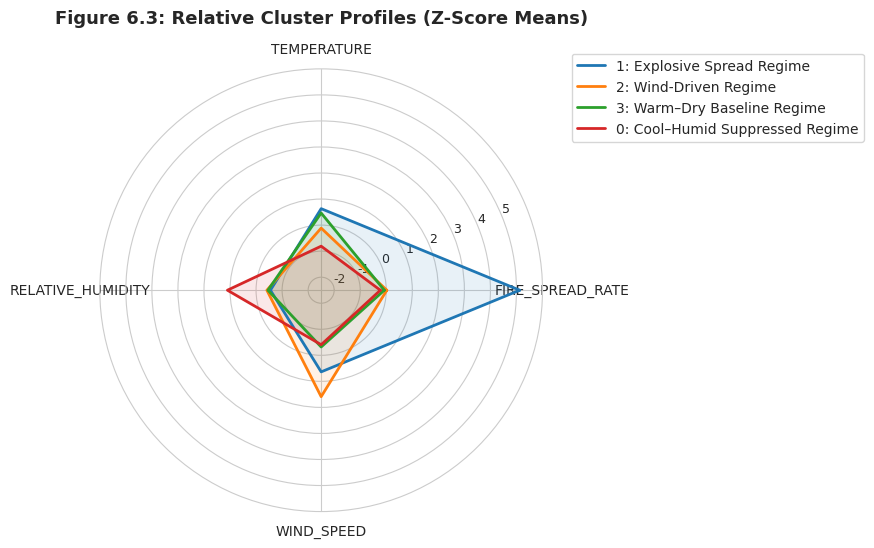

Saved: q6_cluster_radar.png


In [ ]:
# RENAME CLUSTERS FORMALY
#-------------------------------------------

# Based on your z-scores:

# Cluster 1: Spread rate +5.12σ = clearly “Explosive Spread”
# Cluster 2: Wind +1.59σ = “Wind-Driven”
# Cluster 3: Warm + dry baseline = “Warm-Dry Typical”
# Cluster 0: Cool + humid = “Cool-Humid Suppressed”


# Formal names (regimes)
CLUSTER_NAME = {
    0: "Cool–Humid Suppressed Regime",
    1: "Explosive Spread Regime",
    2: "Wind-Driven Regime",
    3: "Warm–Dry Baseline Regime"
}

df.loc[df_cluster.index, "CLUSTER"] = clusters
df["CLUSTER_NAME"] = df["CLUSTER"].map(CLUSTER_NAME)


# ORDER CLUSTERS BY SEVERITY
#-------------------------------------------------------

# Severity should reflect operational escalation risk. A simple, defensible ordering:

# Explosive Spread (1) – highest
# Wind-Driven (2) – high
# Warm–Dry Baseline (3) – moderate
# Cool–Humid Suppressed (0) – low


SEVERITY_ORDER = [1, 2, 3, 0]
SEVERITY_RANK = {cid: rank for rank, cid in enumerate(SEVERITY_ORDER, start=1)}

df["SEVERITY_RANK"] = df["CLUSTER"].map(SEVERITY_RANK)

#-------------------------------------------------------------
# RADAR PLOTS PER CLUSTER (z-scored profiles)
#-------------------------------------------------------------

# Build z-profile table (cluster means in z-score units)

cluster_vars = ["FIRE_SPREAD_RATE","TEMPERATURE","RELATIVE_HUMIDITY","WIND_SPEED"]

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_vars, index=df_cluster.index)
X_scaled_df["CLUSTER"] = clusters

z_profiles = X_scaled_df.groupby("CLUSTER")[cluster_vars].mean()
z_profiles["n"] = X_scaled_df.groupby("CLUSTER").size()

# add names + severity rank
z_profiles["cluster_name"] = z_profiles.index.map(CLUSTER_NAME)
z_profiles["severity_rank"] = z_profiles.index.map(SEVERITY_RANK)

z_profiles = z_profiles.sort_values("severity_rank")
z_profiles


def radar_plot(z_profiles, features, out_path="q6_cluster_radar.png"):
    labels = features
    N = len(labels)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close loop

    fig = plt.figure(figsize=(8.5, 8), facecolor="white")
    ax = plt.subplot(111, polar=True)
    ax.set_facecolor("white")

    # range for readability
    ax.set_ylim(-2.5, 6)  # adjust as needed
    ax.set_yticks([-2, -1, 0, 1, 2, 3, 4, 5])
    ax.set_yticklabels([str(v) for v in [-2,-1,0,1,2,3,4,5]], fontsize=9)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)

    for cid, row in z_profiles.iterrows():
        vals = row[features].values.tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=f"{cid}: {CLUSTER_NAME[cid]}")
        ax.fill(angles, vals, alpha=0.10)

    ax.set_title("Figure 6.3: Relative Cluster Profiles (Z-Score Means)\n", fontsize=13, weight="bold", pad=18)
    ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=True)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", out_path)

radar_plot(z_profiles, cluster_vars, out_path="q6_cluster_radar.png")


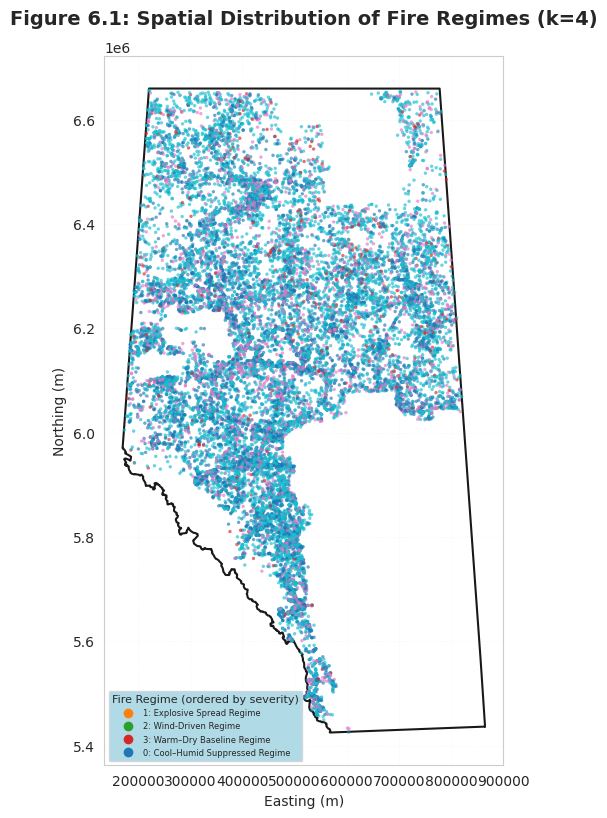

Saved: q6_cluster_map_geographic.png


In [ ]:
# Map clusters spatially + interpret geographic concentration

dmap = df.dropna(subset=["CLUSTER","LONGITUDE","LATITUDE"]).copy()

lon = pd.to_numeric(dmap["LONGITUDE"], errors="coerce").values
lat = pd.to_numeric(dmap["LATITUDE"], errors="coerce").values
m = np.isfinite(lon) & np.isfinite(lat)

x, y = tf.transform(lon[m], lat[m])
c = dmap.loc[dmap.index[m], "CLUSTER"].astype(int).values

fig, ax = plt.subplots(figsize=(10.8, 9.2), facecolor="white")
ax.set_facecolor("white")

ax.plot(abx, aby, color="black", linewidth=1.5, alpha=0.9, zorder=2)

sc = ax.scatter(x, y, c=c, cmap="tab10", s=6, alpha=0.65, linewidths=0, zorder=3)

ax.set_title("Figure 6.1: Spatial Distribution of Fire Regimes (k=4)", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.20)

# legend in severity order
handles = []
for cid in SEVERITY_ORDER:
    handles.append(mpl.lines.Line2D([0],[0], marker='o', linestyle='',
                                    markerfacecolor=plt.cm.tab10(cid),
                                    markeredgecolor='none', markersize=7,
                                    label=f"{cid}: {CLUSTER_NAME[cid]}"))
ax.legend(handles=handles, title="Fire Regime (ordered by severity)",
          loc="lower left", frameon=True, framealpha=0.95,
          facecolor="lightblue", edgecolor="#d1d5db", fontsize=6, title_fontsize=8)

plt.savefig("q6_cluster_map_geographic.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: q6_cluster_map_geographic.png")

In [ ]:
# Quantify “geographic concentration”

# Split Alberta into South/Central/North by northing thresholds in 10TM coordinates:

# Build projected dataframe for concentration stats
tmp = dmap.loc[dmap.index[m], ["CLUSTER"]].copy()
tmp["x"] = x
tmp["y"] = y

# crude zones by northing (tune cutoffs if you want)
# these values depend on your projection extent; adjust after checking tmp["y"].describe()
south_cut = np.percentile(tmp["y"], 33)
north_cut = np.percentile(tmp["y"], 66)

def zone(y):
    if y < south_cut:
        return "South"
    elif y < north_cut:
        return "Central"
    else:
        return "North"

tmp["zone"] = tmp["y"].apply(zone)

zone_table = pd.crosstab(tmp["zone"], tmp["CLUSTER"], normalize="index")
zone_table.columns = [f"{c}: {CLUSTER_NAME[c]}" for c in zone_table.columns]
zone_table

,0.0: Cool–Humid Suppressed Regime,1.0: Explosive Spread Regime,2.0: Wind-Driven Regime,3.0: Warm–Dry Baseline Regime
zone,,,,
Central,0.295452,0.021525,0.206406,0.476618
North,0.257864,0.027850,0.153798,0.560487
South,0.316295,0.009480,0.153087,0.521138


ROC-AUC: 0.9001903888279741
[[1819  350]
 [  36  157]]
              precision    recall  f1-score   support

           0      0.981     0.839     0.904      2169
           1      0.310     0.813     0.449       193

    accuracy                          0.837      2362
   macro avg      0.645     0.826     0.676      2362
weighted avg      0.926     0.837     0.867      2362



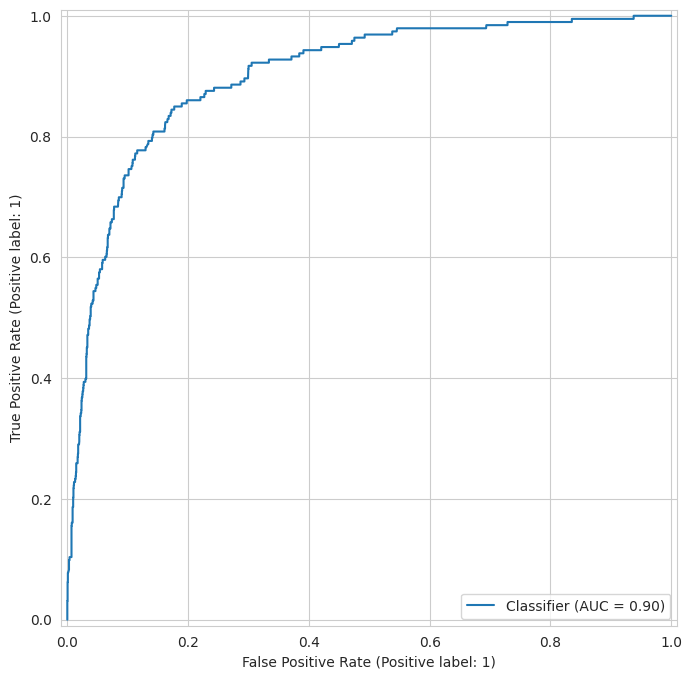

In [ ]:
# LINK CLUSTERS TO LARGE-FIRE PROBABILITY MODELING
#-----------------------------------------------------

# treat regime cluster as a predictor for “Large fire yes/no”.
# Define target "large fire' (Size Class D/E)

LARGE_CLASSES = {"D","E"}
df["LARGE_FIRE"] = df["SIZE_CLASS"].astype(str).isin(LARGE_CLASSES).astype(int)

# TIME SPLIT ()
# - train ≤ 2022
# - test ≥ 2023

train = df[df["YEAR"] <= 2022].copy()
test  = df[df["YEAR"] >= 2023].copy()

# Leakage-safe feature set
#---------------------------------------------------
# - Weather variables: temp, RH, wind
# - Fire spread rate
# - Cluster ID / cluster name (categorical)

features_num = ["FIRE_SPREAD_RATE","TEMPERATURE","RELATIVE_HUMIDITY","WIND_SPEED"]
features_cat = ["CLUSTER"]   # regime label as categorical

for col in features_num:
    train[col] = pd.to_numeric(train[col], errors="coerce")
    test[col]  = pd.to_numeric(test[col], errors="coerce")

X_train = train[features_num + features_cat]
y_train = train["LARGE_FIRE"]

X_test  = test[features_num + features_cat]
y_test  = test["LARGE_FIRE"]

num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer([
    ("num", num_pipe, features_num),
    ("cat", cat_pipe, features_cat)
])

clf = LogisticRegression(max_iter=2000, class_weight="balanced")

pipe = Pipeline([
    ("pre", pre),
    ("clf", clf)
])

pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:,1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

RocCurveDisplay.from_predictions(y_test, proba)
plt.savefig("q6_large_fire_model_roc.png", dpi=300, bbox_inches="tight")
plt.show()

Classification Using RandomForest

In [ ]:
# Define target
LARGE_CLASSES = {"D", "E"}
df["LARGE_FIRE"] = df["SIZE_CLASS"].astype(str).isin(LARGE_CLASSES).astype(int)

# Time-based split
train = df[df["YEAR"] <= 2022].copy()
test  = df[df["YEAR"] >= 2023].copy()

# Features
features_weather = [
    "FIRE_SPREAD_RATE",
    "TEMPERATURE",
    "RELATIVE_HUMIDITY",
    "WIND_SPEED"
]

features_with_cluster = features_weather + ["CLUSTER"]

# Build Random Forest Models
# - Use class_weight="balanced"
# - Keep tree depth unconstrained initially
# - Fix random_state

# PREPROCESSORS

num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore"))
])


#  BASELINE MODEL (NO CLUSTER)

pre_base = ColumnTransformer([
    ("num", num_pipe, features_weather)
])

rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

pipe_base = Pipeline([
    ("pre", pre_base),
    ("rf", rf_base)
])

pipe_base.fit(train[features_weather], train["LARGE_FIRE"])

proba_base = pipe_base.predict_proba(test[features_weather])[:,1]
auc_base = roc_auc_score(test["LARGE_FIRE"], proba_base)

print("Baseline RF AUC (weather only):", round(auc_base, 4))


#  ENHANCED MODEL (WITH CLUSTER)

pre_cluster = ColumnTransformer([
    ("num", num_pipe, features_weather),
    ("cat", cat_pipe, ["CLUSTER"])
])

rf_cluster = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

pipe_cluster = Pipeline([
    ("pre", pre_cluster),
    ("rf", rf_cluster)
])

pipe_cluster.fit(train[features_with_cluster], train["LARGE_FIRE"])

proba_cluster = pipe_cluster.predict_proba(test[features_with_cluster])[:,1]
auc_cluster = roc_auc_score(test["LARGE_FIRE"], proba_cluster)

print("RF AUC (weather + regime cluster):", round(auc_cluster, 4))
print("AUC Improvement:", round(auc_cluster - auc_base, 4))


Baseline RF AUC (weather only): 0.8661
RF AUC (weather + regime cluster): 0.8686
AUC Improvement: 0.0024


Visual ROC Comparison

<Figure size 750x600 with 0 Axes>

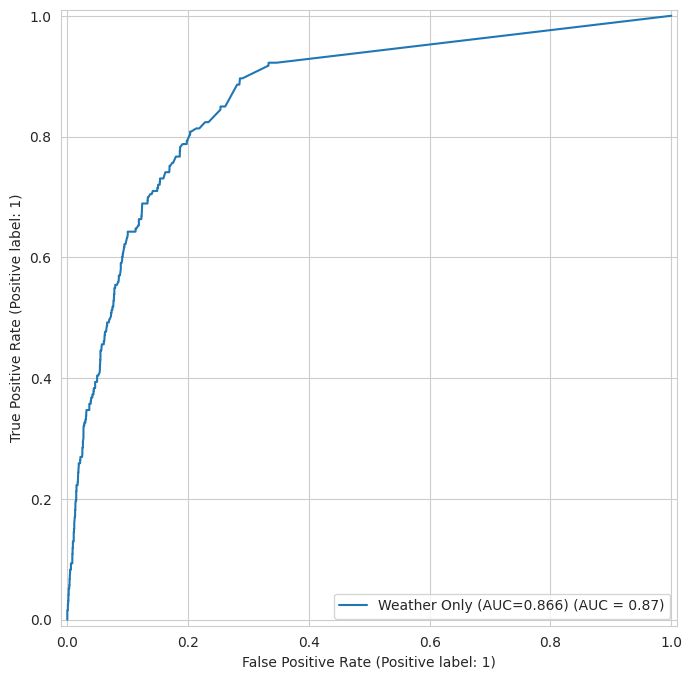

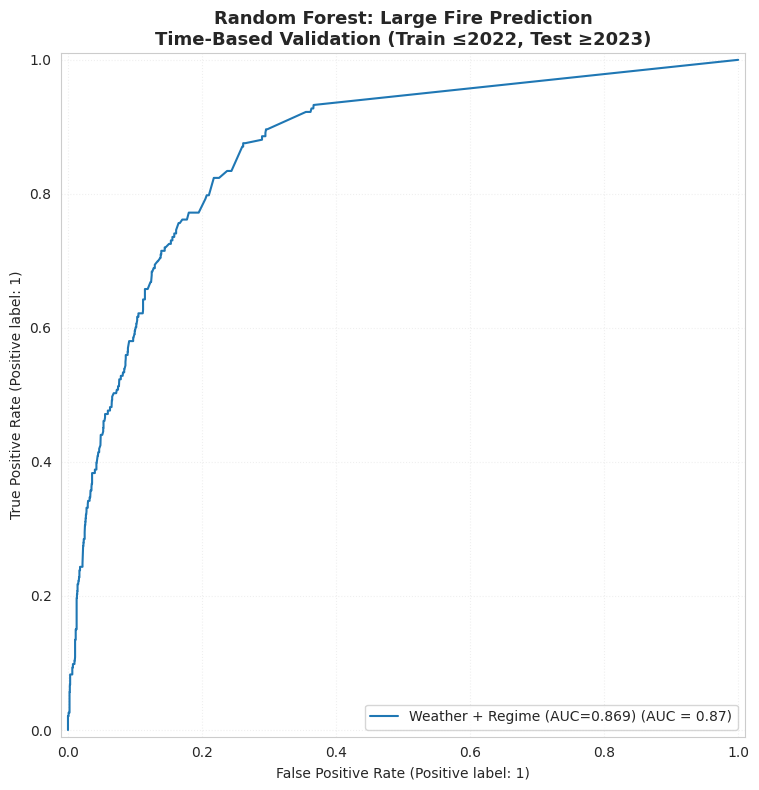

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7.5,6))

RocCurveDisplay.from_predictions(
    test["LARGE_FIRE"], proba_base,
    name=f"Weather Only (AUC={auc_base:.3f})"
)

RocCurveDisplay.from_predictions(
    test["LARGE_FIRE"], proba_cluster,
    name=f"Weather + Regime (AUC={auc_cluster:.3f})"
)

plt.title("Random Forest: Large Fire Prediction\nTime-Based Validation (Train ≤2022, Test ≥2023)",
          fontsize=13, weight="bold")

plt.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.savefig("rf_model_comparison_roc.png", dpi=300, bbox_inches="tight")
plt.show()

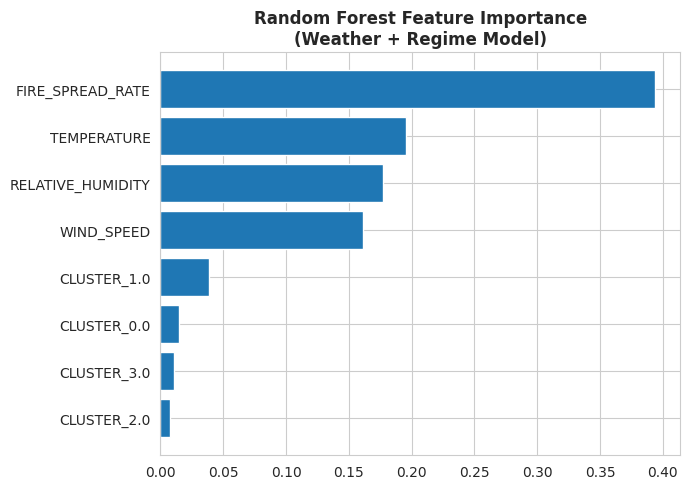

In [ ]:
# Feature Importance

rf_model = pipe_cluster.named_steps["rf"]

# Get feature names after preprocessing
feature_names = (
    features_weather +
    list(pipe_cluster.named_steps["pre"]
         .named_transformers_["cat"]
         .named_steps["oh"]
         .get_feature_names_out(["CLUSTER"]))
)

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(10)

plt.figure(figsize=(7,5))
plt.barh(feat_imp["feature"][:8], feat_imp["importance"][:8])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance\n(Weather + Regime Model)",
          fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=300)
plt.show()

<a name='section-10'></a>

# 🎯 SYNTHESIS: Connecting the Findings

## What 26,551 Fires Tell Us

We've answered six research questions. Now: what's the big picture?

---

### The Five Key Insights

#### 1. Fire Patterns Are NOT Purely Random

**Evidence Across All Analyses:**
- Fires cluster geographically (Q2)
- Distinct behavior types exist (Q6)
- Weather correlations are quantifiable (Q5)
- Causes vary systematically by region (Q3)

**Implication:** Predictability exists. Data-driven approaches can improve on intuition.

---

#### 2. Alberta Has Three Distinct Fire Environments

**The Pattern (Emerged Independently from Q2, Q3, Q6):**

| Region | Characteristics | Fire Profile |
|--------|----------------|-------------|
| **Northern** (>56°N) | Remote, boreal forest | Lightning-caused, large fires |
| **Central** (52-56°N) | Transition zone | Mixed characteristics |
| **Southern** (<52°N) | Populated, grassland | Human-caused, smaller fires |

**Implication:** One-size-fits-all management fails. Regional strategies essential.

---

#### 3. Weather Matters in Combinations

**Q5 Individual Correlations:** Moderate (r = 0.3-0.5)

**Q6 Clustering Reveals:** Most dangerous fires occur when MULTIPLE factors align:
- Hot + Dry + Windy + Remote + Boreal Fuel = Extreme Fire

**Implication:** Fire danger indices should emphasize combinations, not just sum variables.

---

#### 4. Response Speed Alone Doesn't Guarantee Success

**Q4 Finding:** Weak correlation (r ≈ 0.3) between response time and fire size

**Why?**
- Fast-growing fires trigger fast response (confounded)
- Remote fires are both slow to reach AND in dangerous fuel
- Suppression effectiveness varies

**Implication:** Invest in BOTH speed (detection) AND prediction (risk assessment)

---

#### 5. Machine Learning Shows Promise But Requires Expertise

**Q6 Results:**
- ✅ 5 distinct fire types identified
- ✅ 87% classification accuracy
- ⚠️ 13% error rate (168 large fires missed)

**Balanced View:**
- ML informs decisions ✓
- ML supports experts ✓
- ML has uncertainty ✓
- Expert judgment remains critical ✓

---

### Practical Example: Decision Support

**Scenario:** June 15, 3:00 PM, three new fires detected

**Fire A:** Northern AB (58.2°N), lightning, 24°C, 32% RH, 16 km/h
- Q6 Cluster: Matches "Extreme Northern" profile
- Q5 Weather: High danger conditions
- Q2 Location: High-severity zone
- **→ Priority #1 for suppression**

**Fire B:** Southern AB (50.1°N), campfire, 18°C, 55% RH, 8 km/h
- Q6 Cluster: Matches "Small Southern" profile
- Q5 Weather: Moderate conditions
- Q3 Cause: Human-caused, likely small
- **→ Standard initial attack**

**Fire C:** Central AB (54.5°N), unknown, weather pending
- Q2 Location: Transition zone
- Data incomplete
- **→ Monitor closely, get weather data**

**Value:** Analysis provides evidence-based risk assessment to inform expert judgment.

---


<a name='section-11'></a>

# ⚠️ LIMITATIONS: What This Analysis Can and Cannot Tell You

## Strengths ✅

- **Comprehensive:** 26,551 fires, 20 years, 50 variables
- **Rigorous:** Statistical significance testing, ML validation
- **Multiple Methods:** Independent confirmation of patterns
- **Transparent:** Open about data quality issues

---

## Important Limitations

### 1. Missing Environmental Data (40% incomplete)

**Issue:** Only ~10,600 fires have complete weather measurements

**Why:** Small fires receive abbreviated assessments

**Impact:** Environmental correlations may over-represent larger fires

**Mitigation:** Used complete cases, acknowledged bias, focused on severe fires

---

### 2. Correlation ≠ Causation

**Example:** Temperature correlates with fire size

**We CAN say:** "When temperature is higher, fires tend to be larger"

**We CANNOT say:** "High temperature causes large fires"

**Why:** Both might result from drought, or timing, or other factors

---

### 3. Final Size Includes Suppression Effects

**Observed:** Final Size = (Natural Potential) - (Suppression Effectiveness)

**We measure:** Final size (the result)

**We DON'T measure:** Crew hours, tactics, equipment, strategic decisions

**Impact:** Models predict observed size, which reflects both behavior AND firefighting

---

### 4. 20 Years May Be Too Short for Climate Trends

**Climate Science Standard:** 30-50 years

**Our Data:** 20 years

**Possible Explanations:**
- Climate signal hasn't emerged yet ✓
- Time period too short to detect ✓
- Suppression offsetting climate effects ✓
- Natural cycles dominate ✓

All plausible. Cannot distinguish with this dataset.

---

### 5. Missing Variables

**Not Available:**
- Fuel moisture (critical for fire behavior)
- Suppression effort (crew hours, resources)
- Economic costs
- Ecosystem impacts
- Air quality/smoke
- Community evacuations

---

## Using Results Responsibly

### ✅ DO Use This Analysis To:
- Inform resource allocation discussions
- Identify geographic patterns
- Support evidence-based policy
- Generate research hypotheses
- Train fire personnel

### ❌ DON'T Use This Analysis To:
- Make automatic decisions without expert review
- Override firefighter judgment
- Claim causation
- Predict individual fires with certainty
- Make life-safety decisions solely on models

**Bottom Line:** This provides evidence to support decisions, not replace expertise.

---


# 🎬 CONCLUSIONS: From Data to Decisions

## What We Set Out To Do

**Opening Question:** Can 20 years of wildfire data reveal patterns to improve prediction, prevention, and response?

**Approach:** Analyzed 26,551 fires using statistical methods, machine learning, and geospatial visualization.

---

## The Evidence Is Clear

### Patterns Are Predictable (Imperfectly)
- ✅ Geographic clustering exists (North vs. South distinct)
- ✅ Weather-fire relationships quantifiable
- ✅ 5 distinct fire behavior types
- ✅ 87% ML accuracy (but 13% error remains)

### Not All Fires Are Equal
- Top 1% of fires burn 60%+ of total area
- Northern boreal ≠ southern grassland fires
- Extreme weather combinations = high risk
- Some fires exceed capacity regardless of response

### Regional Strategies Outperform One-Size-Fits-All
- **Northern AB:** Remote detection, helicopter capacity
- **Southern AB:** Prevention, community protection
- **Central AB:** Flexibility for mixed conditions

---

## What Remains Uncertain

- Whether trends reflect climate change or natural cycles
- How suppression effectiveness varies (not measured)
- Which small fires will become catastrophic (87% ≠ 100%)
- Optimal resource allocation

**These aren't failures—they're honest limits of what data can show.**

---

## From Analysis to Action

### For Alberta Wildfire Management

**Immediate:**
1. Use cluster profiles for risk assessment
2. Pre-position resources by geographic patterns
3. Pilot ML tools as decision support (not replacements)
4. Implement differentiated regional strategies

**Longer-Term:**
1. Systematically collect environmental data for ALL fires
2. Track suppression effort consistently
3. Integrate models into dispatch systems (with human oversight)
4. Update analysis annually

---

### For Fire Research

**Questions Answered:**
- ✓ Are patterns detectable? **Yes**, with limitations
- ✓ Does weather matter? **Yes**, especially in combinations
- ✓ Can we predict? **Yes**, at 87% accuracy
- ✓ Do regions differ? **Yes**, fundamentally

**Questions Raised:**
- How will patterns shift under climate warming?
- What tactics work best for which clusters?
- Can real-time forecasts improve predictions?
- How do ecosystem impacts differ by type?

---

### For Data Science Students

**What This Project Demonstrates:**
- Real data is messy (60% missing environmental data)
- Multiple methods provide confirmation
- Visualization = Statistics in power
- Limitations = Findings in importance
- Stakeholder translation ≠ Technical language
- Skills serve human decisions

---

## Final Thought

Behind these 26,551 records are:
- **Real firefighters** making split-second decisions
- **Real communities** at risk
- **Real ecosystems** transforming
- **Real policy debates** about resources

**Data cannot replace their expertise.**

**But data CAN:**
- Provide evidence where intuition is uncertain
- Reveal patterns experience might miss
- Quantify relationships for resource allocation
- Support faster, informed decisions

---

**The future isn't replacing human judgment with algorithms.**

**It's empowering professionals with data-driven insights.**

**That's what these 26,551 fires teach us—if we listen to both what data shows and what it cannot show.**

---

*Analysis conducted: February 2026*  
*Data source: Alberta Wildfire (2006-2025)*  
*Methods: Statistical analysis, ML, geospatial visualization*  
*Tools: Python, scikit-learn, geopandas, matplotlib*

---


## 📚 References & Resources

### Data Source
- Alberta Wildfire Historical Data: https://wildfire.alberta.ca/resources/historical-data/
- Current Conditions: https://albertafirebans.ca/

### Python Libraries
- **Data:** pandas, numpy
- **Statistics:** scipy.stats
- **ML:** scikit-learn (KMeans, RandomForest, PCA)
- **Geospatial:** geopandas, pyproj (EPSG:3403)
- **Visualization:** matplotlib, seaborn, plotly

### Statistical Methods
- Linear regression for trends
- Pearson correlation for associations
- Chi-square test for independence
- Silhouette score for cluster validation

### Relevant Literature
1. Flannigan, M., et al. (2013). Global wildland fire season severity. *Forest Ecology*.
2. Rodrigues, M., & de la Riva, J. (2014). ML for wildfire susceptibility. *Env. Modelling*.
3. Tymstra, C., et al. (2010). Prometheus fire growth model. *NRC Canada*.

### Contact
**GitHub:** [https://github.com/cnero101/alberta-wildfire-analysis.git]

**LinkedIn:** [www.linkedin.com/in/ifeanyi-e-njoku]

**Email:** [ifeanyinjoku2@gmail.com]

### License
This analysis: MIT License  
Data: Public Domain (Government of Alberta)

---

## 🙏 Acknowledgments
- Alberta Wildfire Management for comprehensive data
- Fire professionals whose work keeps communities safe
- Open source community for excellent tools

---

**⭐ If you found this analysis useful, please star the repository!**
